In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl
%config InlineBackend.figure_format='retina'

import numpy as np
import networkx as nx
from idtxl.estimators_jidt import JidtDiscreteMI, JidtDiscreteCMI
import matplotlib.pyplot as plt
import os, sys
from tqdm import tqdm
import pandas as pd
os.environ['JAVA_HOME'] = '/Users/jaime/miniconda3/envs/ma-aif-dit/lib/jvm'

In [2]:
%store -r all_partition_timeseries

In [48]:
%store -r superagent_sizes

## Krakauer et al. individuality

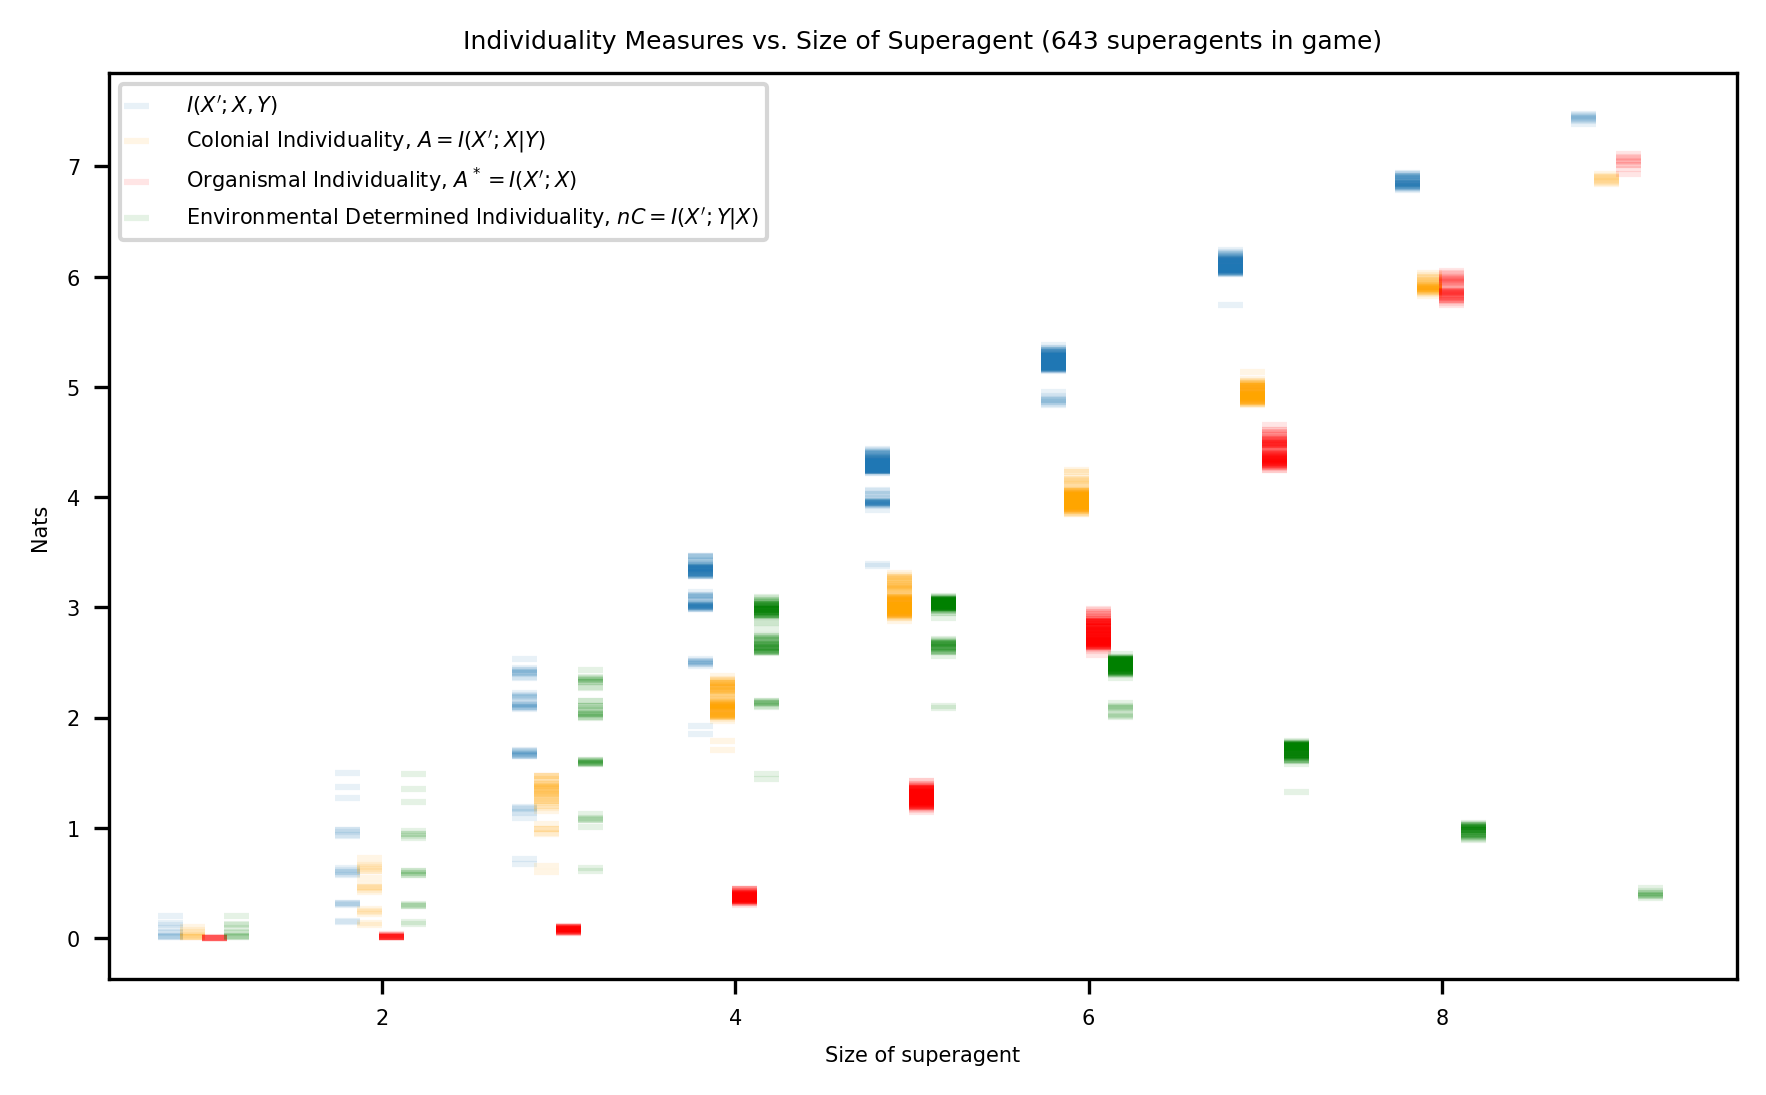

In [4]:
plt.figure(figsize=(7, 4), dpi=150)

plt.rcParams.update({'font.size': 5})

# I(S, E; S') ------------------------------------------------------------------
results_vanilla = []
for S_history, E_history in all_partition_timeseries:
    if E_history.shape[1] == 0:
        continue
    mi_estimator = JidtDiscreteMI()
    source = np.hstack((S_history[:-1], E_history[:-1]))
    target = S_history[1:]
    try:
        mi_result = mi_estimator.estimate(source, target)
    except AssertionError as e:
        print(f"AssertionError: {e}")
        print(f"Source shape: {source.shape}")
        print(f"Target shape: {target.shape}")
        print(f"Source: {source}")
        print(f"Target: {target}")
        print(f"S_history shape: {S_history.shape}")
        print(f"E_history shape: {E_history.shape}")
        raise e
    results_vanilla.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]-0.125 for r in results_vanilla]
y = [r[0] for r in results_vanilla]
plt.scatter(x, y, alpha=0.1, marker=0, label="$I(X'; X, Y)$")

# I(S'; S | E) --------------------------------------------------------------
results_colonial = []
for S_history, E_history in all_partition_timeseries:
    if E_history.shape[1] == 0:
        continue
    cmi_estimator = JidtDiscreteCMI()
    source = S_history[:-1]
    target = S_history[1:]
    mi_result = cmi_estimator.estimate(source, target, conditional=E_history[:-1])
    results_colonial.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1] for r in results_colonial]
y = [r[0] for r in results_colonial]
plt.scatter(x, y, alpha=0.1, marker=0, c='orange', label="Colonial Individuality, $A = I(X'; X | Y)$")

# I(S'; S | E) --------------------------------------------------------------
results_organismal = []
for S_history, E_history in all_partition_timeseries:
    if E_history.shape[1] == 0:
        continue
    mi_estimator = JidtDiscreteMI()
    source = S_history[:-1]
    target = S_history[1:]
    mi_result = mi_estimator.estimate(source, target)
    results_organismal.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]+0.125 for r in results_organismal]
y = [r[0] for r in results_organismal]
plt.scatter(x, y, alpha=0.1, marker=0, c='red', label="Organismal Individuality, $A^*=I(X' ; X)$")

# I(S'; E | S) --------------------------------------------------------------
results_environmental = []
for S_history, E_history in all_partition_timeseries:
    if E_history.shape[1] == 0:
        continue
    cmi_estimator = JidtDiscreteCMI()
    source = E_history[:-1]
    target = S_history[1:]
    mi_result = cmi_estimator.estimate(source, target, conditional=S_history[:-1])
    results_environmental.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]+0.25 for r in results_environmental]
y = [r[0] for r in results_environmental]
plt.scatter(x, y, alpha=0.1, marker=0, c='green', label="Environmental Determined Individuality, $nC = I(X'; Y | X)$")

# Create a scatterplot ---------------------------------------------------------
plt.legend()
plt.ylabel('Nats')
plt.xlabel('Size of superagent')
plt.title(f'Individuality Measures vs. Size of Superagent ({len(all_partition_timeseries)} superagents in game)')
plt.show()

Interpretation: The magnitude of the green points has to do with the ratio of superagent size to environment size. The larger the superagent, the less "environment nodes" are left for it to interact with. For example, for a 10 agent simulation, a size-9 superagent only interacts with 1 environment node. 

## PID individuality

In [4]:
import pandas as pd

from dit import Distribution
from dit.pid import *

In [5]:
unique_infos = []
for S_history, E_history in all_partition_timeseries:
# S_history, E_history = all_partition_timeseries[45]
    print('superagent size', S_history.shape[1])

    # Data setup -------------------------------------------------
    all_data = np.hstack((S_history[:-1], S_history[1:], E_history[:-1], E_history[1:]))

    m = S_history.shape[1]
    if m > 4:
        # Compute struggles with larger superagents
        break

    V = all_data[:, :m].mean(axis=1)

    # Create column names for S_history and E_history
    s_columns = [f"S_{i}" for i in range(S_history.shape[1])]
    s_next_columns = [f"S_{i}_" for i in range(S_history.shape[1])]
    e_columns = [f"E_{i}" for i in range(E_history.shape[1])]
    e_next_columns = [f"E_{i}_" for i in range(E_history.shape[1])]
    column_names = s_columns + s_next_columns + e_columns + e_next_columns + ['V']

    # Combine S_history and E_history into a single DataFrame
    df = pd.DataFrame(
        np.hstack((all_data, V.reshape(-1, 1))), 
        columns=column_names
    )

    # Get distribution from DataFrame
    counts = df.value_counts()
    outcomes = list(counts.index)
    probs = list(counts / counts.sum())
    dist = Distribution(outcomes, probs)

    # Shorthand function to get the index of a column
    idx = lambda x: column_names.index(x)

    # Compute PID ------------------------------------------------------------------
    sources = [
        (idx('V'),), 
        tuple([idx(f'S_{i}') for i in range(m)]), 
    ]
    target = tuple([idx(f'S_{i}_') for i in range(m)])

    pid_obj = PID_BROJA(dist, sources, target)

    # synergy = pid_obj.get_pi(
    #     ( sources[0] + sources[1], ) 
    # )
    # redundancy = pid_obj.get_red(tuple(sources))

    # TODO: level-k
    unique_info = pid_obj.get_pi(
        (sources[1], )
    )
    # unique_info = pid_obj.get_pi(
        # (tuple([idx(f'S_{i}_') for i in range(m)]), )
    # )

    # unique_infos = np.empty((2,))
    # for i in range(2):
    #     unique_infos[i] = pid_obj.get_pi(((i,),))

    # Also compute total MI (sum synergy, redundancy, unique X1, unique X2)
    # total_mi = (
    #     synergy
    #     + redundancy
    #     + unique_infos.sum()
    # )
    unique_infos.append(unique_info)

superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3


KeyboardInterrupt: 

In [6]:
label_font_size = 6

# matplotlib.use("pgf")
plt.rcParams.update({
    'xtick.labelsize': label_font_size,
    'ytick.labelsize': label_font_size,
    'axes.linewidth': 0.5,
    'font.family': 'serif',
    'text.usetex': True,
    'text.latex.preamble': r'''
        \usepackage{amssymb} 
        \usepackage{amsmath} 

        % Load Libertine fonts for text and math
        \usepackage[tt=false]{libertine}   % Libertine for text (not for monospaced)
        \usepackage[libertine]{newtxmath}  % Libertine for math

        % Load Inconsolata for monospaced text
        \usepackage{inconsolata}

        % Redefine \mathtt to use Inconsolata in math mode
        \renewcommand{\mathtt}[1]{\text{\texttt{#1}}}
    ''',
    'figure.dpi': 300,
    'pgf.texsystem': 'pdflatex',
    'pgf.rcfonts': False,
    'ps.usedistiller': 'xpdf',
})

Text(0.5, 1.0, 'Unique Information vs. Size of Superagent (data for only 18 superagents)')

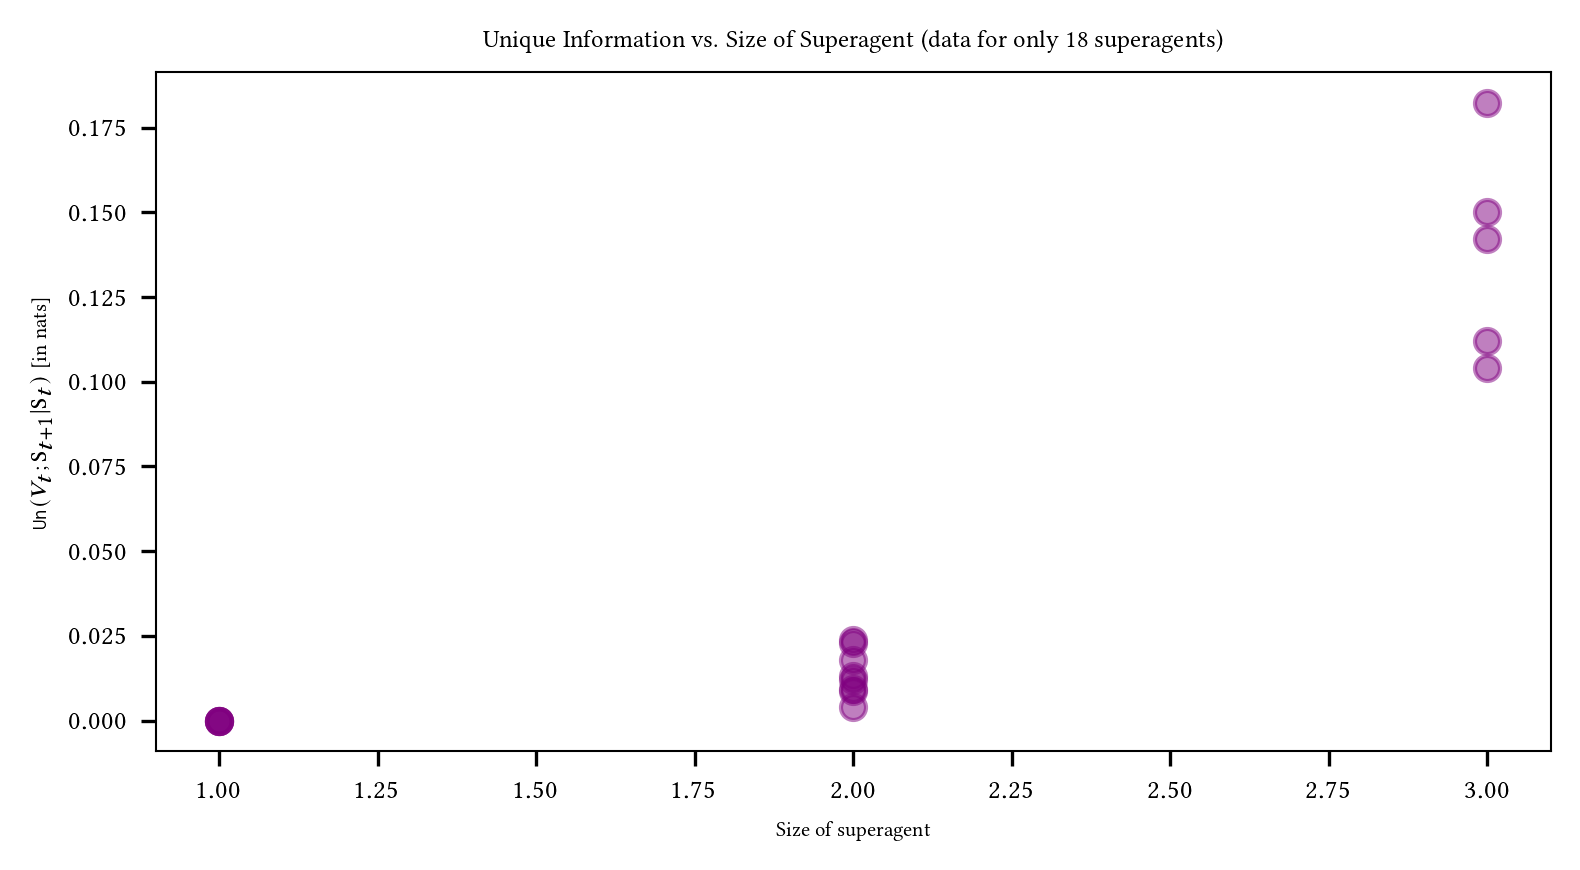

In [7]:
superagent_sizes = np.array([s.shape[1] for s, e in all_partition_timeseries])
plt.figure(figsize=(6, 3), dpi=150)
plt.scatter(
    superagent_sizes[:len(unique_infos)], 
    unique_infos, 
    alpha=0.5, 
    c='purple', 
    label="Unique Information"
)
plt.xlabel('Size of superagent')
plt.ylabel(r'$\texttt{Un}(V_t; \mathbf{S}_{t+1} | \mathbf{S}_t)$ [in nats]')
plt.title(f'Unique Information vs. Size of Superagent (data for only {len(unique_infos)} superagents)')

## PID synergy



In [134]:
# unique_infos = []
synergies = []
for S_history, E_history in all_partition_timeseries:
    print('superagent size', S_history.shape[1])

    # Data setup -------------------------------------------------
    all_data = np.hstack((S_history[:-1], S_history[1:]))#, E_history[:-1], E_history[1:]))

    m = S_history.shape[1]
    if not m == 2:
        continue

    # Create column names for S_history and E_history
    s_columns = [f"S_{i}" for i in range(S_history.shape[1])]
    s_next_columns = [f"S_{i}_" for i in range(S_history.shape[1])]
    # e_columns = [f"E_{i}" for i in range(E_history.shape[1])]
    # e_next_columns = [f"E_{i}_" for i in range(E_history.shape[1])]
    column_names = s_columns + s_next_columns  # + e_columns + e_next_columns

    # Combine S_history and E_history into a single DataFrame
    df = pd.DataFrame(
        all_data,
        columns=column_names
    )

    # Get distribution from DataFrame
    counts = df.value_counts()
    outcomes = list(counts.index)
    probs = list(counts / counts.sum())
    dist = Distribution(outcomes, probs)

    # Shorthand function to get the index of a column
    idx = lambda x: column_names.index(x)

    # Compute PID ------------------------------------------------------------------
    sources = [
        # (idx('V'),), 
        # tuple([idx(f'S_{i}') for i in range(m)]), 
        (idx(f'S_{i}'), ) 
        for i in range(m)
    ]
    target = tuple([idx(f'S_{i}_') for i in range(m)])

    pid_obj = PID_BROJA(dist, sources, target)

    synergy = pid_obj.get_pi(
        tuple(sources)
    )
    # redundancy = pid_obj.get_red(tuple(sources))

    # TODO: level-k
    # unique_info = pid_obj.get_pi(
        # (sources[1], )
    # )
    # unique_info = pid_obj.get_pi(
        # (tuple([idx(f'S_{i}_') for i in range(m)]), )
    # )

    # unique_infos = np.empty((2,))
    # for i in range(2):
    #     unique_infos[i] = pid_obj.get_pi(((i,),))

    # Also compute total MI (sum synergy, redundancy, unique X1, unique X2)
    # total_mi = (
    #     synergy
    #     + redundancy
    #     + unique_infos.sum()
    # )
    # unique_infos.append(unique_info)
    synergies.append(synergy)

superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 4
superagent size 4
superagent size 4
superagent size 4
superagent size 4
superagent size 5
superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent

Text(0.5, 0, '$\\texttt{Syn}(\\mathbf{X}_t; \\mathbf{X}_{t+1})$ [in nats]')

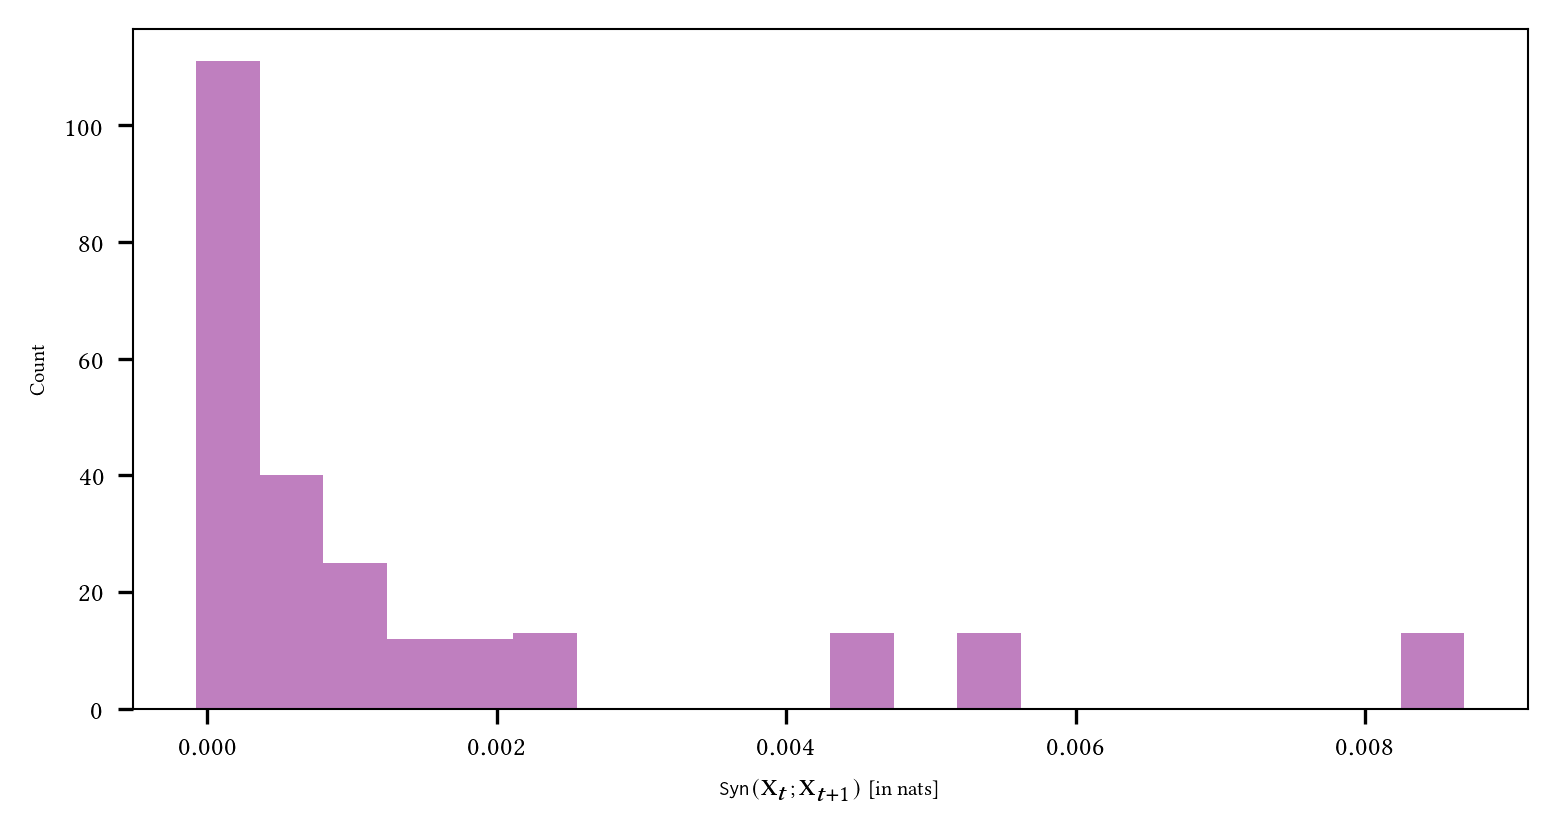

In [136]:
superagent_sizes = np.array([s.shape[1] for s, e in all_partition_timeseries])
plt.figure(figsize=(6, 3), dpi=150)
plt.hist(synergies, bins=20, alpha=0.5, color='purple', label="Synergy")
plt.ylabel('Count')
plt.xlabel(r'$\texttt{Syn}(\mathbf{X}_t; \mathbf{X}_{t+1})$ [in nats]')

## Synergistic coefficient

[@Rosas2020CausalBlankets]()


In [144]:
# unique_infos = []
synergies = []
for S_history, E_history in all_partition_timeseries[20:21]:
    print('superagent size', S_history.shape[1])

    # Data setup -------------------------------------------------
    all_data = np.hstack((S_history[:-1], S_history[1:], E_history[:-1], E_history[1:]))

    m = S_history.shape[1]
    n = E_history.shape[1]

    # Create column names for S_history and E_history
    s_columns = [f"S_{i}" for i in range(S_history.shape[1])]
    s_next_columns = [f"S_{i}_" for i in range(S_history.shape[1])]
    e_columns = [f"E_{i}" for i in range(E_history.shape[1])]
    e_next_columns = [f"E_{i}_" for i in range(E_history.shape[1])]
    column_names = s_columns + s_next_columns + e_columns + e_next_columns

    # Combine S_history and E_history into a single DataFrame
    df = pd.DataFrame(
        all_data,
        columns=column_names
    )

    # Get distribution from DataFrame
    counts = df.value_counts()
    outcomes = list(counts.index)
    probs = list(counts / counts.sum())
    print(outcomes)
    print(probs)
    # Shorthand function to get the index of a column
    idx = lambda x: column_names.index(x)
    # Compute the conditional probability distribution
    conditional_outcomes = []
    conditional_probs = []

    for outcome, prob in zip(outcomes, probs):
        current_indices = [idx(f'S_{i}') for i in range(m)] + [idx(f'E_{j}') for j in range(n)]
        current_state = tuple(np.array(outcome)[current_indices])
        next_indices = [idx(f'S_{i}_') for i in range(m)] + [idx(f'E_{j}_') for j in range(n)]
        next_state = tuple(np.array(outcome)[next_indices])
        
        if current_state not in conditional_outcomes:
            conditional_outcomes.append(current_state)
            conditional_probs.append([])

        indices = conditional_outcomes.index(current_state)
        conditional_probs[indices].append(prob)

    # Normalize probabilities for each condition
    conditional_distributions = {
        tuple(state): np.array(probs) / np.sum(probs)
        for state, probs in zip(conditional_outcomes, conditional_probs)
    }
    # dist = Distribution(outcomes, probs)


    print(conditional_distributions)
    # # Compute PID ------------------------------------------------------------------
    # sources = [
    #     # (idx('V'),), 
    #     # tuple([idx(f'S_{i}') for i in range(m)]), 
    #     (idx(f'S_{i}'), ) 
    #     for i in range(m)
    # ]
    # target = tuple([idx(f'S_{i}_') for i in range(m)])

    # pid_obj = PID_BROJA(dist, sources, target)

    # synergy = pid_obj.get_pi(
    #     tuple(sources)
    # )
    # # redundancy = pid_obj.get_red(tuple(sources))

    # # TODO: level-k
    # # unique_info = pid_obj.get_pi(
    #     # (sources[1], )
    # # )
    # # unique_info = pid_obj.get_pi(
    #     # (tuple([idx(f'S_{i}_') for i in range(m)]), )
    # # )

    # # unique_infos = np.empty((2,))
    # # for i in range(2):
    # #     unique_infos[i] = pid_obj.get_pi(((i,),))

    # # Also compute total MI (sum synergy, redundancy, unique X1, unique X2)
    # # total_mi = (
    # #     synergy
    # #     + redundancy
    # #     + unique_infos.sum()
    # # )
    # # unique_infos.append(unique_info)
    # synergies.append(synergy)

superagent size 3
[(1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1), (0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1), (0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0), (0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0), (0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1), (0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1), (0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0), (0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1), (0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0), (0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1), (0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1), (0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1), (0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1), (0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0), (0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1), (0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0), (0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1), (0, 1, 0, 0, 1, 0, 1, 0, 0, 0

In [140]:
df.head()

,S_0,S_1,S_2,S_0_,S_1_,S_2_,E_0,E_1,E_2,E_3,E_4,E_5,E_0_,E_1_,E_2_,E_3_,E_4_,E_5_
0,0,1,0,1,1,1,0,1,0,0,1,0,0,0,0,0,1,1
1,1,1,1,0,0,0,0,0,0,0,1,1,0,1,0,1,0,0
2,0,0,0,1,1,1,0,1,0,1,0,0,1,0,1,1,0,1
3,1,1,1,0,1,0,1,0,1,1,0,1,1,0,1,0,1,1
4,0,1,0,1,1,0,1,0,1,0,1,1,1,0,0,0,0,1


In [148]:
import numpy as np
from collections import defaultdict

def estimate_discrete_conditional_prob(data):
    """
    Estimates the conditional probability distribution p(Z_t+1 | Z_t)
    for discrete multivariate time series data.

    Args:
        data (np.ndarray): A NumPy array of shape (T, d), where T is the
                           number of time steps and d = m+n is the number of
                           discrete variables. Assumes integer or string data types
                           that can be converted to hashable tuples.

    Returns:
        dict: A dictionary representing the conditional probability distribution.
              Keys are tuples representing the unique states Z_t observed.
              Values are dictionaries, where keys are tuples representing
              the next states Z_t+1 and values are the estimated conditional
              probabilities p(Z_t+1 | Z_t).
              Example: {
                  (state_A): { (state_B): 0.7, (state_C): 0.3 },
                  (state_B): { (state_B): 1.0 }
              }
    """
    # 1. Data Preparation: Create pairs of (current_state, next_state)
    if not isinstance(data, np.ndarray):
        raise TypeError("Input 'data' must be a NumPy array.")
    if data.ndim != 2:
        raise ValueError("Input 'data' must be a 2D array (T, d).")
    if data.shape[0] < 2:
        print("Warning: Data has less than 2 time steps. Cannot compute transitions.")
        return {} # Not enough data for transitions

    # Z_t contains data from time 0 to T-2
    Z_t = data[:-1, :]
    # Z_t_plus_1 contains data from time 1 to T-1
    Z_t_plus_1 = data[1:, :]

    num_transitions = Z_t.shape[0]
    if num_transitions == 0:
         print("Warning: Not enough data points to form any transitions.")
         return {}

    # 2. Initialize Count Dictionaries
    # Counts the total occurrences of each state Z_t
    state_counts = defaultdict(int)
    # Counts the transitions Z_t -> Z_t+1
    # Structure: transition_counts[current_state_tuple][next_state_tuple] = count
    transition_counts = defaultdict(lambda: defaultdict(int))

    # 3. Count Transitions and Occurrences
    for i in range(num_transitions):
        # Convert NumPy rows to hashable tuples to use as dictionary keys.
        # Ensure data types within the tuple are hashable (e.g., int, str).
        try:
            current_state_tuple = tuple(Z_t[i])
            next_state_tuple = tuple(Z_t_plus_1[i])
        except TypeError as e:
            print(f"Error converting row {i} to tuple. Ensure data contains hashable types (int, str, etc.).")
            print(f"Current state row: {Z_t[i]}")
            print(f"Next state row: {Z_t_plus_1[i]}")
            raise e


        state_counts[current_state_tuple] += 1
        transition_counts[current_state_tuple][next_state_tuple] += 1

    # 4. Calculate Conditional Probabilities
    conditional_probs = {}
    for current_state, next_states_dict in transition_counts.items():
        # Get the total number of times 'current_state' was observed at time t
        total_count_for_current = state_counts[current_state]

        # Calculate probabilities for each next state observed after current_state
        probs_given_current = {}
        for next_state, count in next_states_dict.items():
            # p(next | current) = count(current -> next) / count(current)
            probability = count / total_count_for_current
            probs_given_current[next_state] = probability

        # Store the distribution for the current_state
        conditional_probs[current_state] = probs_given_current

    # Optional: You might want to include states that were observed but had no
    # subsequent transitions recorded (e.g., the very last state in the original data).
    # These states would have p(z'|z) = 0 for all z'.
    # for state in state_counts:
    #     if state not in conditional_probs:
    #         conditional_probs[state] = {} # Indicate no observed transitions *from* this state

    return conditional_probs


In [5]:
import numpy as np
from collections import defaultdict
import collections.abc # To check for list/tuple types

def estimate_discrete_conditional_prob_indexed(data, target_indices, condition_indices):
    """
    Estimates the conditional probability distribution p(Target_{t+1} | Condition_t)
    for discrete multivariate time series data, based on specified indices.

    Args:
        data (np.ndarray): A NumPy array of shape (T, d), where T is the
                           number of time steps and d is the total number of
                           discrete variables. Assumes data types that can be
                           converted to hashable tuples (e.g., int, str).
        target_indices (Sequence[int]): A list or tuple of column indices for the
                                     variables whose joint state at t+1 is the target.
                                     Example: [2, 3] for Y1, Y2.
        condition_indices (Sequence[int]): A list or tuple of column indices for the
                                        variables whose joint state at t forms the condition.
                                        Example: [0, 1, 2, 3] for X1, X2, Y1, Y2.

    Returns:
        tuple: A tuple containing:
            - dict: The conditional probability distribution. Keys are tuples
                    representing unique Condition_t states. Values are dicts
                    where keys are tuples representing Target_{t+1} states and
                    values are the estimated conditional probabilities.
            - defaultdict: Counts of each observed condition state.
            - defaultdict: Nested dictionary storing transition counts:
                           transition_counts[condition_state][target_state] = count.

    Raises:
        TypeError: If data is not a NumPy array or indices are not integers.
        ValueError: If data is not 2D, indices lists are empty, or T < 2.
        IndexError: If any index is out of bounds for the data columns.
    """
    # --- Input Validation ---
    if not isinstance(data, np.ndarray):
        raise TypeError("Input 'data' must be a NumPy array.")
    if data.ndim != 2:
        raise ValueError("Input 'data' must be a 2D array (T, d).")
    T, d = data.shape
    if T < 2:
        print("Warning: Data has less than 2 time steps. Cannot compute transitions.")
        return {}, defaultdict(int), defaultdict(lambda: defaultdict(int))

    # Validate indices types and non-emptiness
    if not isinstance(target_indices, collections.abc.Sequence) or not target_indices:
        raise ValueError("target_indices must be a non-empty list or tuple.")
    if not isinstance(condition_indices, collections.abc.Sequence) or not condition_indices:
        raise ValueError("condition_indices must be a non-empty list or tuple.")

    # Validate index contents (are they integers?)
    if not all(isinstance(i, int) for i in target_indices):
         raise TypeError("target_indices must contain only integers.")
    if not all(isinstance(i, int) for i in condition_indices):
         raise TypeError("condition_indices must contain only integers.")

    # Validate index bounds
    target_indices = list(target_indices) # Ensure list format for min/max
    condition_indices = list(condition_indices)
    min_target_idx, max_target_idx = min(target_indices), max(target_indices)
    min_cond_idx, max_cond_idx = min(condition_indices), max(condition_indices)

    if min_target_idx < 0 or max_target_idx >= d:
        raise IndexError(f"target_indices {target_indices} out of bounds for data with {d} columns.")
    if min_cond_idx < 0 or max_cond_idx >= d:
         raise IndexError(f"condition_indices {condition_indices} out of bounds for data with {d} columns.")

    # --- Data Slicing based on Indices ---
    # Select columns for condition variables
    condition_data = data[:, condition_indices]
    # Select columns for target variables
    target_data = data[:, target_indices]

    # --- Create Time-Shifted Pairs ---
    # Condition states from time 0 to T-2
    Condition_t = condition_data[:-1, :]
    # Target states from time 1 to T-1
    Target_t_plus_1 = target_data[1:, :]

    num_transitions = Condition_t.shape[0]

    # --- Initialize Count Dictionaries ---
    # Counts occurrences of each unique condition state at time t
    condition_state_counts = defaultdict(int)
    # Counts transitions: condition_state (t) -> target_state (t+1)
    # Structure: transition_counts[condition_state_tuple][target_state_tuple] = count
    transition_counts = defaultdict(lambda: defaultdict(int))

    # --- Count Transitions and Occurrences ---
    for i in range(num_transitions):
        try:
            # Tuple representing the state of condition variables at time t
            condition_state_tuple = tuple(Condition_t[i])
            # Tuple representing the state of target variables at time t+1
            target_state_tuple = tuple(Target_t_plus_1[i])
        except TypeError as e:
             # Handle potential non-hashable types if data wasn't clean
            print(f"Error converting row {i} to tuple. Ensure data contains hashable types (int, str, etc.).")
            print(f"Condition state row (indices {condition_indices}): {Condition_t[i]}")
            print(f"Target state row (indices {target_indices}): {Target_t_plus_1[i]}")
            raise e

        # Increment count for the observed condition state
        condition_state_counts[condition_state_tuple] += 1
        # Increment count for the observed transition
        transition_counts[condition_state_tuple][target_state_tuple] += 1

    # --- Calculate Conditional Probabilities ---
    conditional_probs = {}
    for condition_state, target_states_dict in transition_counts.items():
        # Get the total number of times this condition_state was observed at time t
        total_count_for_condition = condition_state_counts[condition_state]

        # Calculate probabilities for each target state observed after this condition state
        probs_given_condition = {}
        if total_count_for_condition > 0: # Should always be true if condition_state in transition_counts
            for target_state, count in target_states_dict.items():
                # p(target | condition) = count(condition -> target) / count(condition)
                probability = count / total_count_for_condition
                probs_given_condition[target_state] = probability
        else:
             # This case should theoretically not happen based on the counting logic
             print(f"Warning: Condition state {condition_state} found in transition keys but not in counts.")


        # Store the distribution for the current condition_state
        conditional_probs[condition_state] = probs_given_condition

    # Optional: Add condition states that were observed but had no subsequent transitions recorded.
    # These states would have p(Target_{t+1} | Condition_t) = 0 for all targets.
    # for state in condition_state_counts:
    #    if state not in conditional_probs:
    #        conditional_probs[state] = {} # Indicate no observed transitions *from* this state

    # Return the distribution and the counts for potential inspection
    return conditional_probs, condition_state_counts, transition_counts


# --- Helper Function to Print Distribution ---
def print_distribution(prob_dist, cond_counts, trans_counts, target_indices, condition_indices, max_entries=5):
    """Prints a summary of the estimated conditional probability distribution."""
    print(f"\n--- Conditional Probability Distribution ---")
    print(f"Estimating: p( Vars_{target_indices} at t+1 | Vars_{condition_indices} at t )")
    print("-" * 35)

    if not prob_dist:
        num_cond_states = len(cond_counts)
        if num_cond_states > 0:
             print(f"No transitions observed, although {num_cond_states} unique condition states were found.")
        else:
             print("No condition states or transitions found (check data and indices).")
        return

    print(f"Found {len(prob_dist)} unique condition states with observed transitions.")
    print(f"Showing details for up to {max_entries} condition states (sorted):")

    sorted_cond_states = sorted(prob_dist.keys())
    count = 0
    for cond_state in sorted_cond_states:
        if count >= max_entries:
            print(f"\n... and {len(sorted_cond_states) - max_entries} more condition states with transitions.")
            break

        probs_dict = prob_dist[cond_state]
        print(f"\n  Given Condition state at t = {cond_state}: (Observed {cond_counts.get(cond_state, 0)} times)")

        if not probs_dict:
            # This part might not be reached if we only iterate through transition_counts keys,
            # unless we add the optional part in the main function to include all observed condition states.
            print("    -> No observed target states following this condition.")
        else:
            sorted_target_states = sorted(probs_dict.items(), key=lambda item: item[0])
            prob_sum = 0.0
            for target_state, probability in sorted_target_states:
                 # Safely get transition count using the returned transition_counts
                trans_count = trans_counts.get(cond_state, {}).get(target_state, 0)
                print(f"    -> P(Target state at t+1 = {target_state}) = {probability:.4f} ({trans_count} transitions)")
                prob_sum += probability
            # Check: Sum of probabilities should be close to 1
            print(f"    (Sum of probabilities: {prob_sum:.4f})")
        count += 1
    print("-" * 35)


In [7]:

data = np.hstack((S_history, E_history))
T, d = data.shape

print("Sample Data Shape:", data.shape)
print("Sample Data (first 5 rows):\n", data[:5])

# Estimate p(Var_0_{t+1}, Var_1_{t+1} | Var_2_t, Var_3_t)
target_idx = list(range(d))
cond_idx = list(range(d))
prob_dist, counts, trans = estimate_discrete_conditional_prob_indexed(
    data, target_idx, cond_idx
)
print_distribution(prob_dist, counts, trans, target_idx, cond_idx)

Sample Data Shape: (500, 10)
Sample Data (first 5 rows):
 [[0. 0. 1. 1. 0. 1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 1. 1. 0. 0. 0. 1.]
 [0. 1. 1. 0. 1. 1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 1. 0. 0. 1. 0. 0.]
 [1. 0. 1. 1. 0. 1. 1. 1. 0. 1.]]

--- Conditional Probability Distribution ---
Estimating: p( Vars_[0, 1, 2, 3, 4, 5, 6, 7, 8, 9] at t+1 | Vars_[0, 1, 2, 3, 4, 5, 6, 7, 8, 9] at t )
-----------------------------------
Found 398 unique condition states with observed transitions.
Showing details for up to 5 condition states (sorted):

  Given Condition state at t = (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0): (Observed 1 times)
    -> P(Target state at t+1 = (0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0)) = 1.0000 (1 transitions)
    (Sum of probabilities: 1.0000)

  Given Condition state at t = (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0): (Observed 1 times)
    -> P(Target state at t+1 = (0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0)) = 1.0000 (1 transitions)
    (Sum of probab

In [6]:
import numpy as np
from collections import defaultdict
import collections.abc

# Ensure the function estimate_discrete_conditional_prob_indexed from the previous
# step is defined in your environment. If not, copy it here.
# Example definition (assuming it exists):
# def estimate_discrete_conditional_prob_indexed(data, target_indices, condition_indices):
#     # ... (implementation from previous answer) ...
#     return conditional_probs, condition_state_counts, transition_counts


def compute_probability_ratio(data, x_indices, y_indices):
    """
    Computes the ratio:
        p(X_{t+1}, Y_{t+1} | X_t, Y_t) /
        [ p(X_{t+1} | X_t, Y_t) * p(Y_{t+1} | X_t, Y_t) ]
    for each observed transition in discrete multivariate time series data.

    This ratio measures the deviation from conditional independence between X_{t+1}
    and Y_{t+1}, given the past state (X_t, Y_t). A ratio of 1 indicates
    conditional independence.

    Args:
        data (np.ndarray): Shape (T, d) array of discrete time series data.
        x_indices (Sequence[int]): Column indices in 'data' for variables X.
        y_indices (Sequence[int]): Column indices in 'data' for variables Y.

    Returns:
        dict: A dictionary where keys are condition state tuples (representing
              the combined state (X_t, Y_t) based on concatenated indices).
              Values are dictionaries where inner keys are joint target state
              tuples (representing (X_{t+1}, Y_{t+1}) based on concatenated
              indices) and values are the computed ratios. Returns an empty
              dict if no transitions are found for the numerator distribution.

    Raises:
        ValueError: If index lists are invalid.
        TypeError: If data or indices have incorrect types.
        IndexError: If indices are out of bounds.
        (Plus any errors raised by estimate_discrete_conditional_prob_indexed).
    """
    # --- Validate and Prepare Indices ---
    if not isinstance(x_indices, collections.abc.Sequence) or not x_indices:
        raise ValueError("x_indices must be a non-empty list or tuple.")
    if not isinstance(y_indices, collections.abc.Sequence) or not y_indices:
        raise ValueError("y_indices must be a non-empty list or tuple.")
    if not all(isinstance(i, int) for i in x_indices):
         raise TypeError("x_indices must contain only integers.")
    if not all(isinstance(i, int) for i in y_indices):
         raise TypeError("y_indices must contain only integers.")

    # Ensure list format for concatenation and length checks
    x_indices = list(x_indices)
    y_indices = list(y_indices)
    len_x = len(x_indices)
    len_y = len(y_indices)

    # Define index sets for the three probability estimations
    # condition_indices defines the state (X_t, Y_t)
    # target_indices_joint defines the state (X_{t+1}, Y_{t+1}) for the numerator
    # We preserve the order X then Y, removing duplicates from Y if they exist in X
    condition_indices = x_indices + [idx for idx in y_indices if idx not in x_indices]
    target_indices_joint = condition_indices # Numerator target state uses same combined vars
    target_indices_x = x_indices          # Denominator 1 target state is X_{t+1}
    target_indices_y = y_indices          # Denominator 2 target state is Y_{t+1}

    # print(f"Condition indices (X_t, Y_t order): {condition_indices}")
    # print(f"Joint Target indices (X_{{t+1}}, Y_{{t+1}} order): {target_indices_joint}")
    # print(f"X Target indices (X_{{t+1}}): {target_indices_x}")
    # print(f"Y Target indices (Y_{{t+1}}): {target_indices_y}")


    # --- Estimate Required Probability Distributions ---
    # 1. Numerator: p(X_{t+1}, Y_{t+1} | X_t, Y_t)
    # print("\nEstimating Numerator: p(X(t+1), Y(t+1) | X(t), Y(t))...")
    prob_dist_num, condition_counts, _ = estimate_discrete_conditional_prob_indexed(
        data, target_indices_joint, condition_indices
    )
    # Check if any transitions were found for the main distribution
    if not prob_dist_num and not condition_counts:
         print("Warning: No transitions found for the joint distribution p(XY|XY). Cannot compute ratio.")
         return {}
    elif not prob_dist_num:
         print("Warning: No transitions observed *from* any condition state for p(XY|XY), though condition states exist.")
         # Proceed, ratios will likely be 0 or NaN depending on denominator results

    # 2. Denominator term 1: p(X_{t+1} | X_t, Y_t)
    # print("Estimating Denominator 1: p(X(t+1) | X(t), Y(t))...")
    prob_dist_den1, _, _ = estimate_discrete_conditional_prob_indexed(
        data, target_indices_x, condition_indices
    )

    # 3. Denominator term 2: p(Y_{t+1} | X_t, Y_t)
    # print("Estimating Denominator 2: p(Y(t+1) | X(t), Y(t))...")
    prob_dist_den2, _, _ = estimate_discrete_conditional_prob_indexed(
        data, target_indices_y, condition_indices
    )

    # --- Precompute Index Mappings for Robust Tuple Reconstruction ---
    # These maps help correctly extract the X_{t+1} and Y_{t+1} parts
    # from the joint_target_state tuple, regardless of index overlap/order.

    # Map original X index to its position within the target_indices_joint tuple
    x_idx_to_joint_pos = {idx: pos for pos, idx in enumerate(target_indices_joint) if idx in x_indices}
    # Map original Y index to its position within the target_indices_joint tuple
    y_idx_to_joint_pos = {idx: pos for pos, idx in enumerate(target_indices_joint) if idx in y_indices}
    # Map original X index to its position within the target_indices_x tuple (used to build x_prime)
    x_idx_to_x_prime_pos = {idx: pos for pos, idx in enumerate(target_indices_x)}
    # Map original Y index to its position within the target_indices_y tuple (used to build y_prime)
    y_idx_to_y_prime_pos = {idx: pos for pos, idx in enumerate(target_indices_y)}


    # --- Compute the Ratio ---
    ratio_dict = defaultdict(dict)
    # print("\nCalculating ratios...")

    # Iterate through all condition states that were observed at time t
    # Using condition_counts ensures we consider all starting points
    for condition_state in condition_counts.keys():

        # Get the dictionary of joint transitions from this state (might be empty)
        joint_target_dict = prob_dist_num.get(condition_state, {})

        # If no joint transitions observed, check individual transitions
        if not joint_target_dict:
             x_targets = prob_dist_den1.get(condition_state, {})
             y_targets = prob_dist_den2.get(condition_state, {})
             # If there are individual transitions, the numerator p_num is 0
             # The ratio will be 0 unless denominator is also 0 (NaN)
             if x_targets or y_targets:
                 # Need to define what joint_target_state means here.
                 # Let's only calculate ratios for observed joint transitions.
                 # If p(joint) is 0, the ratio is 0 or NaN. We'll compute it when needed below.
                 pass # Handled implicitly below by iterating over prob_dist_num


        # Iterate through joint target states observed after this condition state
        for joint_target_state, p_num in joint_target_dict.items():

            # --- Reconstruct x_prime and y_prime tuples from joint_target_state ---
            x_prime_list = [None] * len_x
            y_prime_list = [None] * len_y

            # Populate x_prime_list using values from joint_target_state & mappings
            for original_idx in x_indices: # Iterate through the defined X indices
                if original_idx in x_idx_to_joint_pos: # Check if it's part of the joint state
                   pos_in_joint = x_idx_to_joint_pos[original_idx]
                   pos_in_x_prime = x_idx_to_x_prime_pos[original_idx]
                   # Ensure index access is safe (should be if mappings are correct)
                   if pos_in_joint < len(joint_target_state):
                       x_prime_list[pos_in_x_prime] = joint_target_state[pos_in_joint]
                   else: # Should not happen with correct logic
                       print(f"Warning: Index mismatch for x_idx {original_idx} in joint_target_state {joint_target_state}")

            # Populate y_prime_list using values from joint_target_state & mappings
            for original_idx in y_indices: # Iterate through the defined Y indices
                if original_idx in y_idx_to_joint_pos: # Check if it's part of the joint state
                   pos_in_joint = y_idx_to_joint_pos[original_idx]
                   pos_in_y_prime = y_idx_to_y_prime_pos[original_idx]
                   # Ensure index access is safe
                   if pos_in_joint < len(joint_target_state):
                       y_prime_list[pos_in_y_prime] = joint_target_state[pos_in_joint]
                   else: # Should not happen
                       print(f"Warning: Index mismatch for y_idx {original_idx} in joint_target_state {joint_target_state}")

            # Convert lists to tuples (handle potential None if index wasn't in joint state?)
            # This shouldn't happen if condition_indices = target_indices_joint correctly includes all x and y indices
            if None in x_prime_list or None in y_prime_list:
                 print(f"Warning: Could not fully reconstruct x/y prime tuples for joint state {joint_target_state}")
                 print(f"x_prime_list: {x_prime_list}, y_prime_list: {y_prime_list}")
                 # Skip calculation for this problematic case? Or allow tuple() conversion?
                 # Let's try converting anyway, might indicate issue with index setup.
            x_prime_tuple = tuple(x_prime_list)
            y_prime_tuple = tuple(y_prime_list)
            # --- End Reconstruction ---

            # Get denominator probabilities using the reconstructed tuples
            # Use .get() for safety, defaulting to 0.0
            p_den1 = prob_dist_den1.get(condition_state, {}).get(x_prime_tuple, 0.0)
            p_den2 = prob_dist_den2.get(condition_state, {}).get(y_prime_tuple, 0.0)

            denominator = p_den1 * p_den2

            # Calculate the ratio with division-by-zero handling
            if denominator == 0.0:
                if p_num == 0.0:
                    # Undefined 0/0 case. Using NaN (Not a Number) is standard.
                    ratio = np.nan
                else:
                    # p_num > 0 and denominator is 0. Ratio is infinite.
                    ratio = np.inf
            else:
                # Standard case: p_num / (p_den1 * p_den2)
                ratio = p_num / denominator

            # Store the result, keyed by condition_state -> joint_target_state -> ratio
            ratio_dict[condition_state][joint_target_state] = ratio

    # print("Ratio calculation complete.")
    return ratio_dict

In [200]:
# --- Example Usage ---

T, d = data.shape
print("Data Shape:", data.shape)
m = S_history.shape[1]
n = E_history.shape[1]
assert d == m + n, "Data shape mismatch: d should equal m + n."

x_idx = list(range(m))
y_idx = list(range(m, d))

# Compute the ratio
the_ratio_dict = compute_probability_ratio(data, x_idx, y_idx)

# --- Print the ratio results (using a helper function) ---
def print_ratio_distribution(ratio_dist, x_indices, y_indices, max_entries=5):
    """Prints a summary of the computed probability ratios."""
    print(f"\n--- Computed Probability Ratios ---")
    print(f"Ratio = p(X'{',Y'}' | X,Y) / [ p(X' | X,Y) * p(Y' | X,Y) ]") # Using shorthand
    print(f"X indices: {x_indices}, Y indices: {y_indices}")
    print("-" * 35)

    if not ratio_dist:
        print("Ratio dictionary is empty (no transitions found?).")
        return

    print(f"Found ratios for {len(ratio_dist)} unique condition states (X,Y).")
    print(f"Showing details for up to {max_entries} condition states (sorted):")

    sorted_cond_states = sorted(ratio_dist.keys())
    count = 0
    for cond_state in sorted_cond_states:
        if count >= max_entries:
            print(f"\n... and {len(sorted_cond_states) - max_entries} more condition states.")
            break

        target_ratios_dict = ratio_dist[cond_state]
        # Note: cond_state tuple structure depends on index concatenation logic inside compute_probability_ratio
        print(f"\n  Given Condition state (X_t, Y_t order) = {cond_state}:")

        if not target_ratios_dict:
             print("    -> No target states with calculated ratios for this condition.")
        else:
            # Sort inner keys (joint target states) for consistent output
            sorted_target_states = sorted(target_ratios_dict.items())
            for target_state, ratio_val in sorted_target_states:
                 # Note: target_state tuple structure depends on index concatenation logic
                 print(f"    -> For Target state (X_t+1, Y_t+1 order) = {target_state}: Ratio = {ratio_val:.4f}")
        count += 1
    print("-" * 35)

print_ratio_distribution(the_ratio_dict, x_idx, y_idx)

# # --- Test case with overlapping/shuffled indices ---
# x_idx_overlap = [0, 2] # X = {Var 0, Var 2}
# y_idx_overlap = [1, 0] # Y = {Var 1, Var 0} - Note overlap and different order
# print("\n--- Testing Overlapping Indices ---")
# the_ratio_dict_overlap = compute_probability_ratio(sample_data_ex, x_idx_overlap, y_idx_overlap)
# print_ratio_distribution(the_ratio_dict_overlap, x_idx_overlap, y_idx_overlap)

Data Shape: (500, 10)


ValueError: y_indices must be a non-empty list or tuple.

In [201]:
final_ratio_value = 0
for target, target_ratios_dict in the_ratio_dict.items():
    print(target)
    print(target_ratios_dict)
    for target_state, ratio_val in target_ratios_dict.items():
        print(f"  Target state: {target_state}, Ratio: {ratio_val:.4f}")
        final_ratio_value += np.log(ratio_val)
    print()
print("Final Ratio Value:", final_ratio_value)

(0, 0, 1, 1, 0, 0, 0, 1, 0, 0)
{(0, 1, 0, 1, 0, 1, 0, 1, 1, 1): 1.0}
  Target state: (0, 1, 0, 1, 0, 1, 0, 1, 1, 1), Ratio: 1.0000

(0, 1, 0, 1, 0, 1, 0, 1, 1, 1)
{(0, 0, 1, 0, 0, 0, 1, 0, 0, 0): 1.0}
  Target state: (0, 0, 1, 0, 0, 0, 1, 0, 0, 0), Ratio: 1.0000

(0, 0, 1, 0, 0, 0, 1, 0, 0, 0)
{(1, 1, 0, 1, 1, 1, 1, 0, 1, 0): 1.0, (0, 0, 0, 1, 1, 1, 0, 0, 1, 0): 1.0}
  Target state: (1, 1, 0, 1, 1, 1, 1, 0, 1, 0), Ratio: 1.0000
  Target state: (0, 0, 0, 1, 1, 1, 0, 0, 1, 0), Ratio: 1.0000

(1, 1, 0, 1, 1, 1, 1, 0, 1, 0)
{(1, 0, 0, 1, 1, 0, 0, 1, 1, 1): 1.0}
  Target state: (1, 0, 0, 1, 1, 0, 0, 1, 1, 1), Ratio: 1.0000

(1, 0, 0, 1, 1, 0, 0, 1, 1, 1)
{(1, 1, 0, 1, 0, 0, 0, 0, 1, 0): 1.0}
  Target state: (1, 1, 0, 1, 0, 0, 0, 0, 1, 0), Ratio: 1.0000

(1, 1, 0, 1, 0, 0, 0, 0, 1, 0)
{(0, 1, 1, 1, 0, 1, 1, 1, 0, 1): 1.0}
  Target state: (0, 1, 1, 1, 0, 1, 1, 1, 0, 1), Ratio: 1.0000

(0, 1, 1, 1, 0, 1, 1, 1, 0, 1)
{(0, 1, 0, 1, 1, 1, 0, 1, 0, 1): 1.0}
  Target state: (0, 1, 0, 1, 1, 1, 0, 1,

In [7]:
# --- Example Usage ---
all_synergistic_coefficients = []
for S_history, E_history in tqdm(all_partition_timeseries):
    data = np.hstack((S_history, E_history))

    T, d = data.shape
    # print("Data Shape:", data.shape)
    m = S_history.shape[1]
    n = E_history.shape[1]
    assert d == m + n, "Data shape mismatch: d should equal m + n."

    x_idx = list(range(m))
    y_idx = list(range(m, d))

    # Compute the ratio
    try:
        the_ratio_dict = compute_probability_ratio(data, x_idx, y_idx)
    except Exception as e:
        all_synergistic_coefficients.append(np.nan)
        pass
    else:
        final_ratio_value = 0
        
        # Option A: Simple sum
        # for cond, target_ratios_dict in the_ratio_dict.items():
        #     for target_state, ratio_val in target_ratios_dict.items():
        #         final_ratio_value += np.log(ratio_val)

        # Option B: Expected value under p(X_t, Y_t)
        df = pd.DataFrame(data)
        counts = df.value_counts()
        outcomes = list(counts.index)
        probs = list(counts / counts.sum())
        for cond, target_ratios_dict in the_ratio_dict.items():
            for target_state, ratio_val in target_ratios_dict.items():  
                outcome_idx = outcomes.index(target_state)
                prob = probs[outcome_idx]
                final_ratio_value += prob * np.log(ratio_val)
        
        all_synergistic_coefficients.append(final_ratio_value)

100%|██████████| 643/643 [00:14<00:00, 44.60it/s]


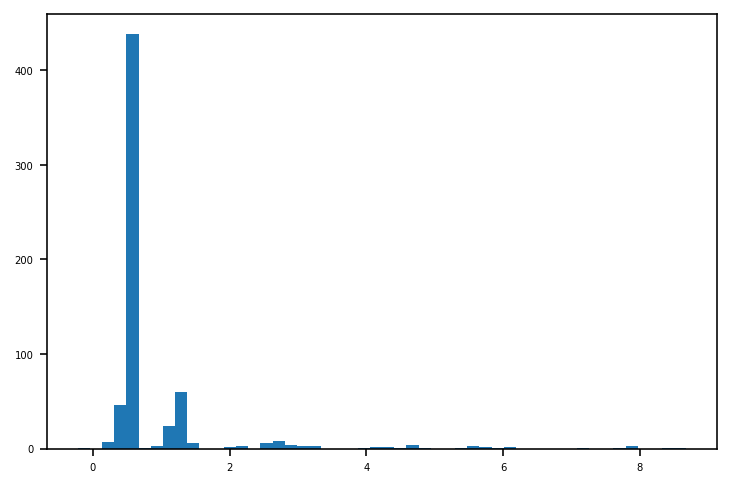

In [8]:
plt.hist(all_synergistic_coefficients, bins=50)
plt.show()

In [9]:
all_synergistic_coefficients = np.array(all_synergistic_coefficients)
# superagent_sizes[np.where(all_synergistic_coefficients != np.nan)]
np.where(all_synergistic_coefficients == np.nan)
len(all_synergistic_coefficients), len(superagent_sizes)

(643, 643)

Text(0, 0.5, 'Expected Synergistic Coefficient $\\mathbb{E}_{p(X, Y)}[\\xi_t]$')

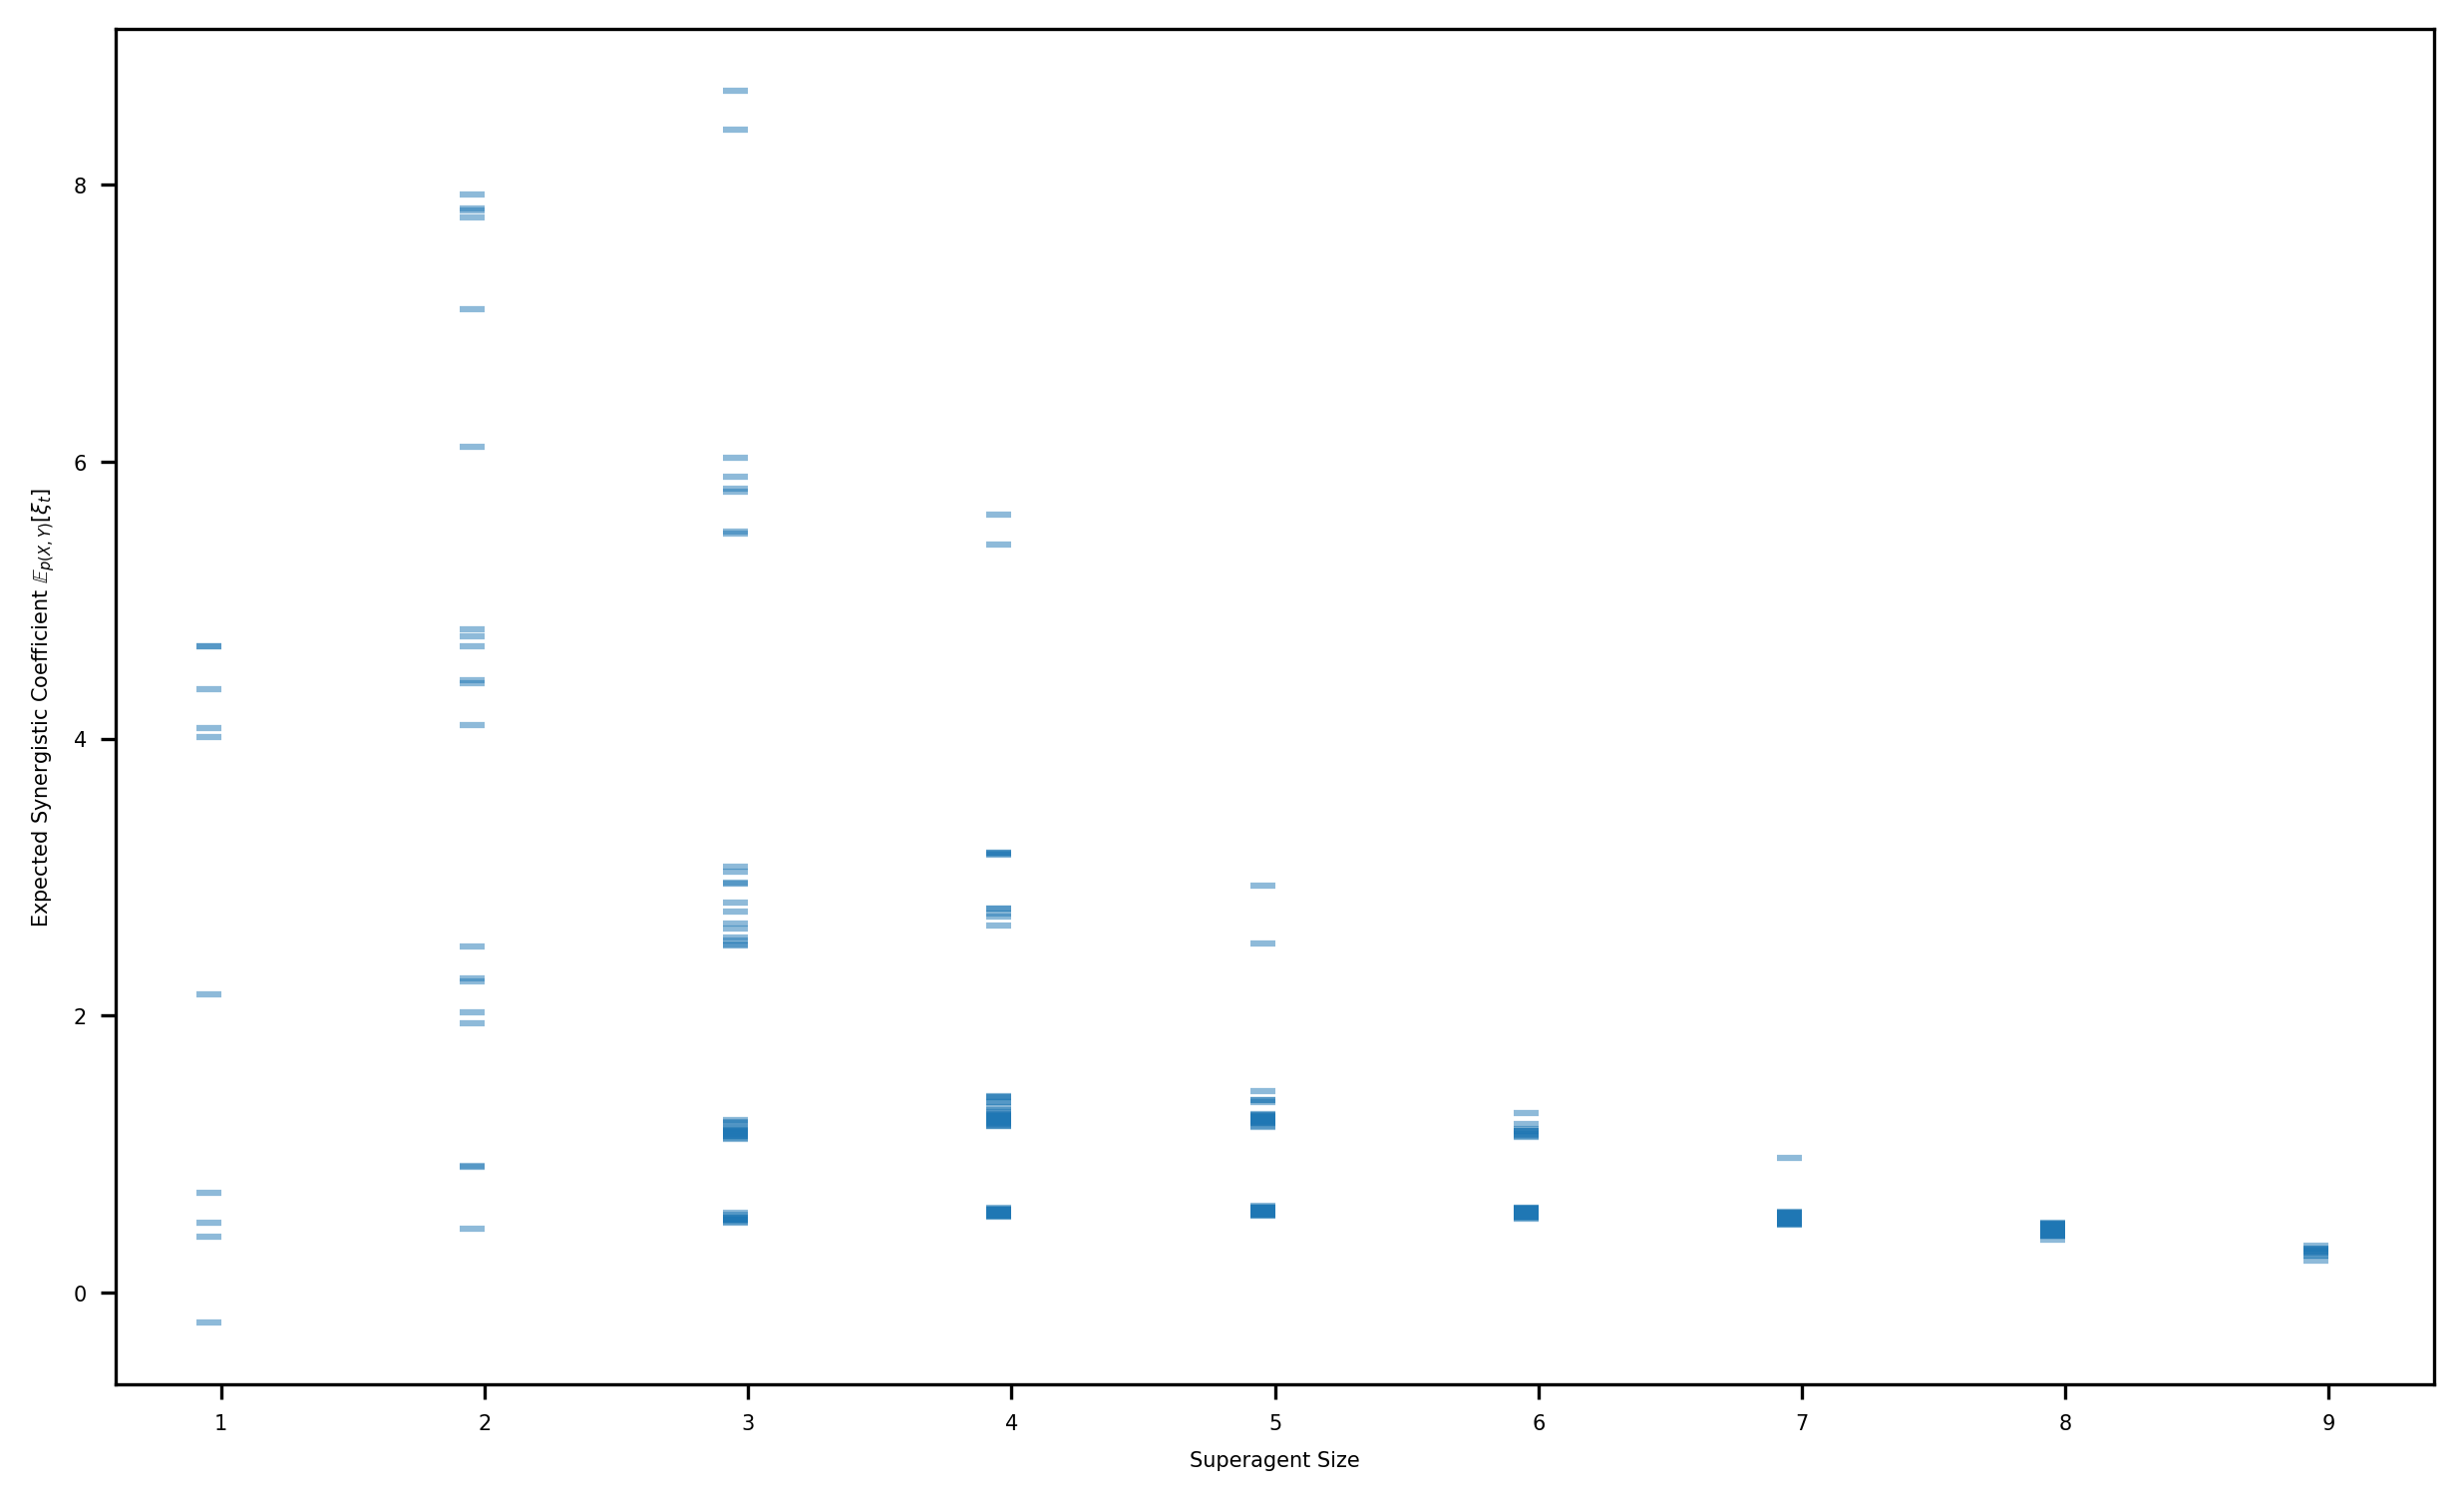

In [12]:
plt.figure(figsize=(10, 6), dpi=150)
plt.scatter(
    superagent_sizes, 
    all_synergistic_coefficients,
    alpha=0.5,
    marker=0,
) 
plt.xlabel("Superagent Size")
plt.ylabel(r"Expected Synergistic Coefficient $\mathbb{E}_{p(X, Y)}[\xi_t]$")

In [11]:
%store all_synergistic_coefficients

Stored 'all_synergistic_coefficients' (ndarray)


Text(0, 0.5, 'Expected Synergistic Coefficient $\\mathbb{E}_{p(X, Y)}[\\xi_t]$')

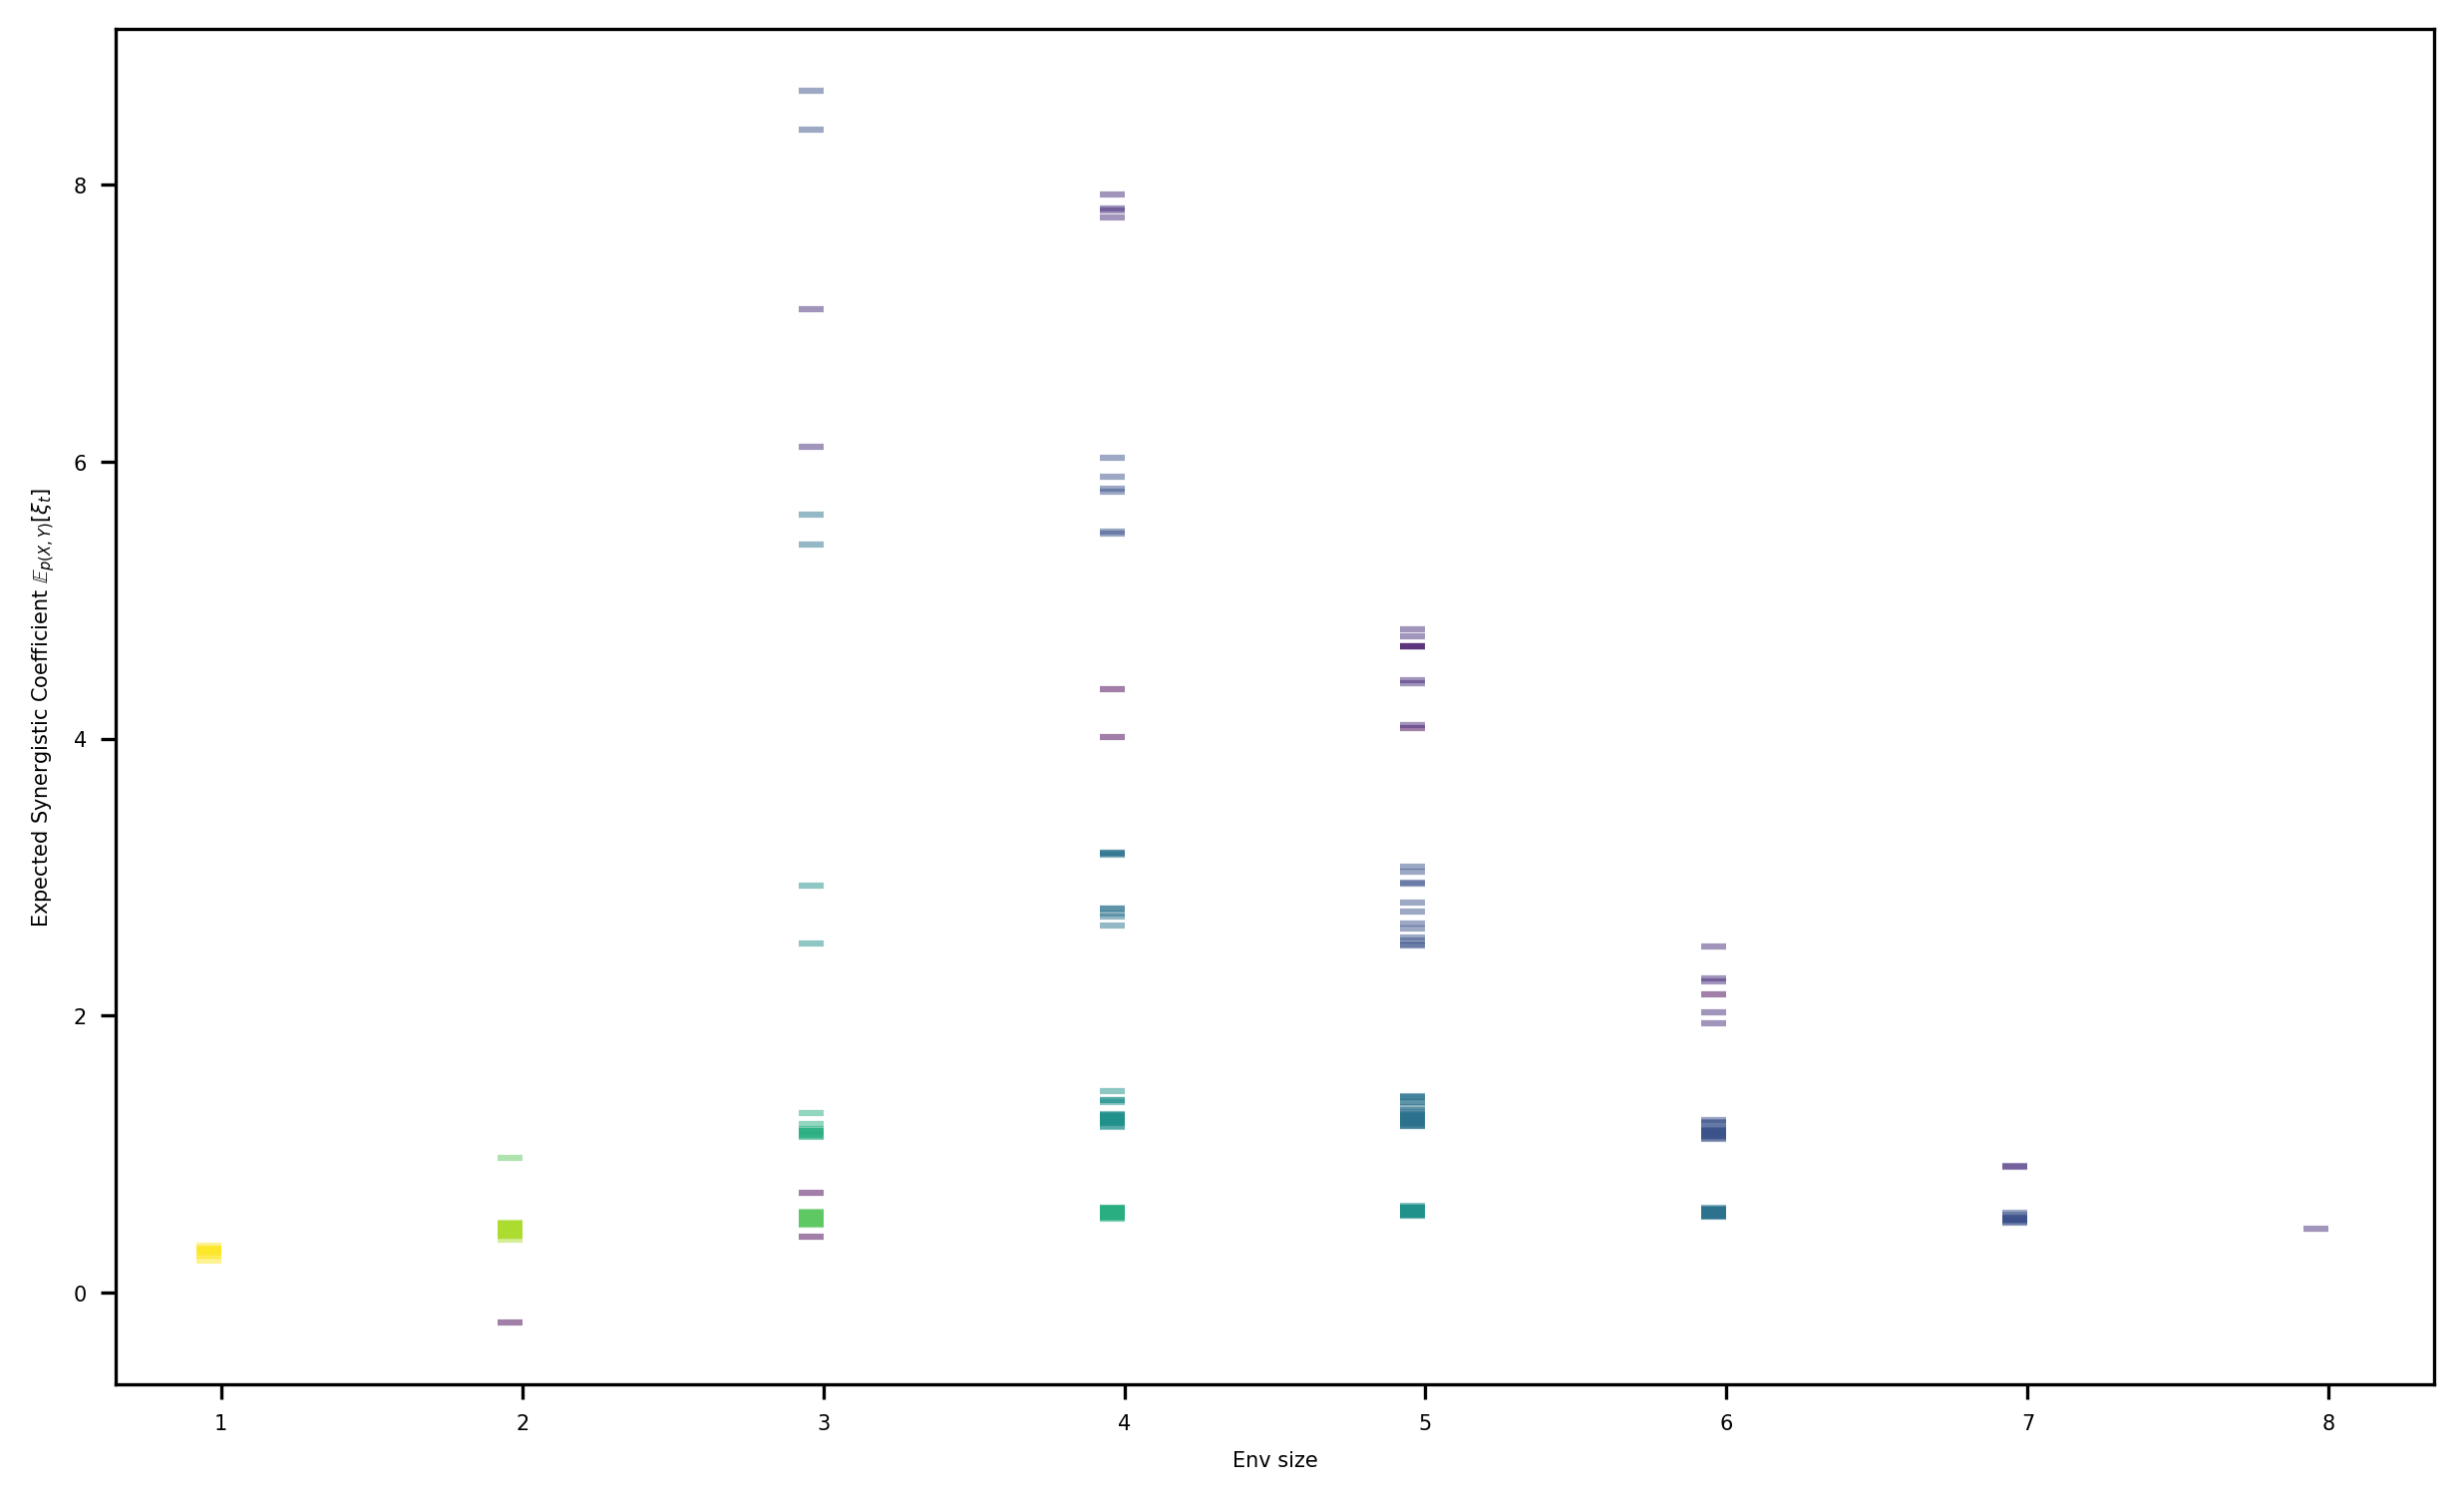

In [17]:
Y_sizes = np.array([p[1].shape[1] for p in all_partition_timeseries])
X_sizes = np.array([p[0].shape[1] for p in all_partition_timeseries])

plt.figure(figsize=(10, 6), dpi=150)
plt.scatter(
    Y_sizes, 
    all_synergistic_coefficients,
    alpha=0.5,
    c=X_sizes,
    cmap='viridis',
    marker=0,
) 
plt.xlabel("Env size")
plt.ylabel(r"Expected Synergistic Coefficient $\mathbb{E}_{p(X, Y)}[\xi_t]$")

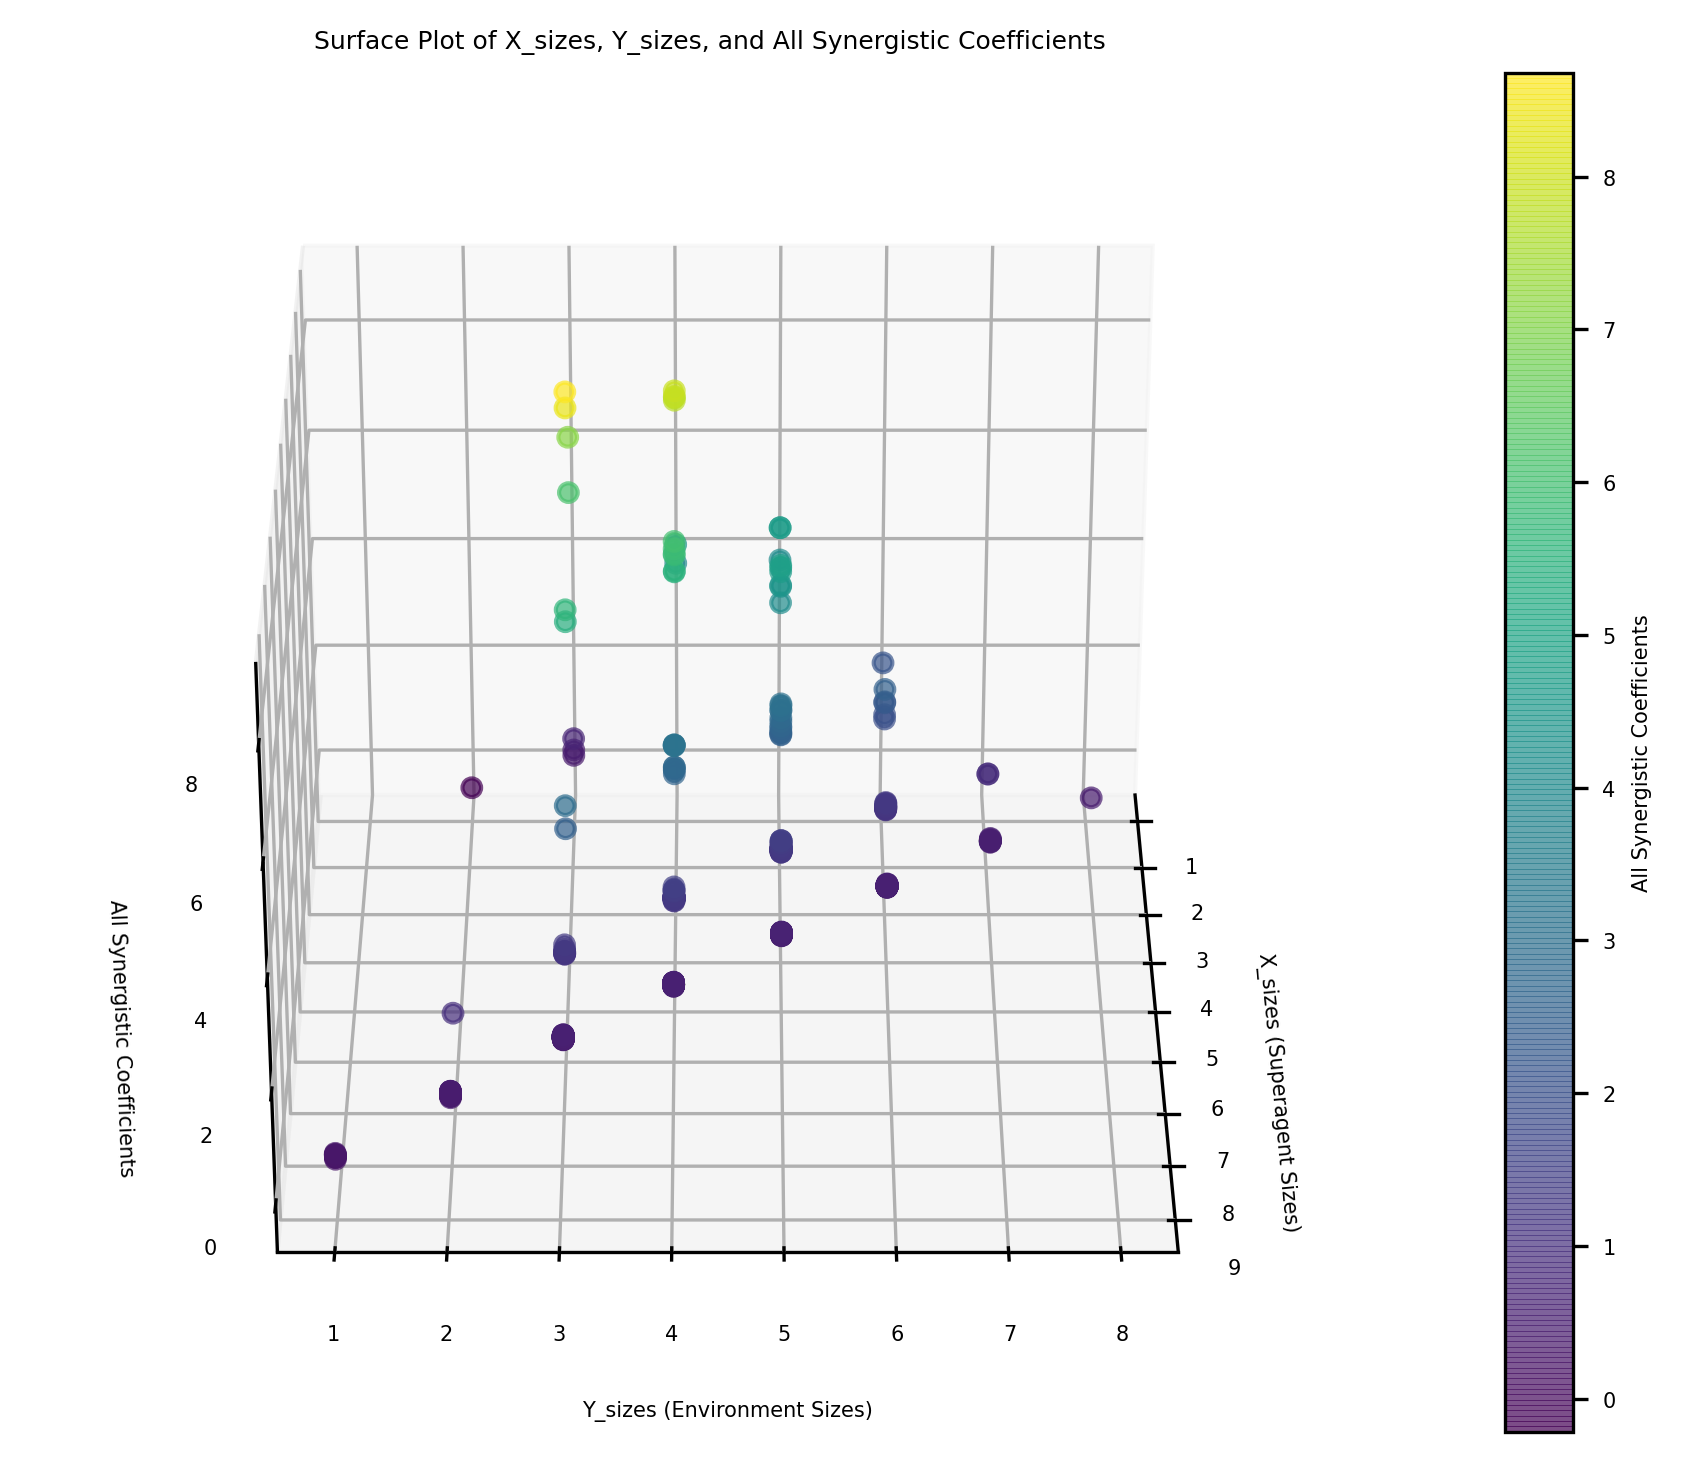

In [35]:
from mpl_toolkits.mplot3d import Axes3D

Y_sizes = np.array([p[1].shape[1] for p in all_partition_timeseries])
X_sizes = np.array([p[0].shape[1] for p in all_partition_timeseries])

fig = plt.figure(figsize=(10, 6), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# Create a surface plot
scatter = ax.scatter(X_sizes, Y_sizes, all_synergistic_coefficients, c=all_synergistic_coefficients, cmap='viridis', alpha=0.7)
fig.colorbar(scatter, ax=ax, label='All Synergistic Coefficients')
ax.view_init(
    elev=30, 
    azim=0
)

# Add labels and title
ax.set_xlabel('X_sizes (Superagent Sizes)')
ax.set_ylabel('Y_sizes (Environment Sizes)')
ax.set_zlabel('All Synergistic Coefficients')
ax.set_title('Surface Plot of X_sizes, Y_sizes, and All Synergistic Coefficients')

plt.show()

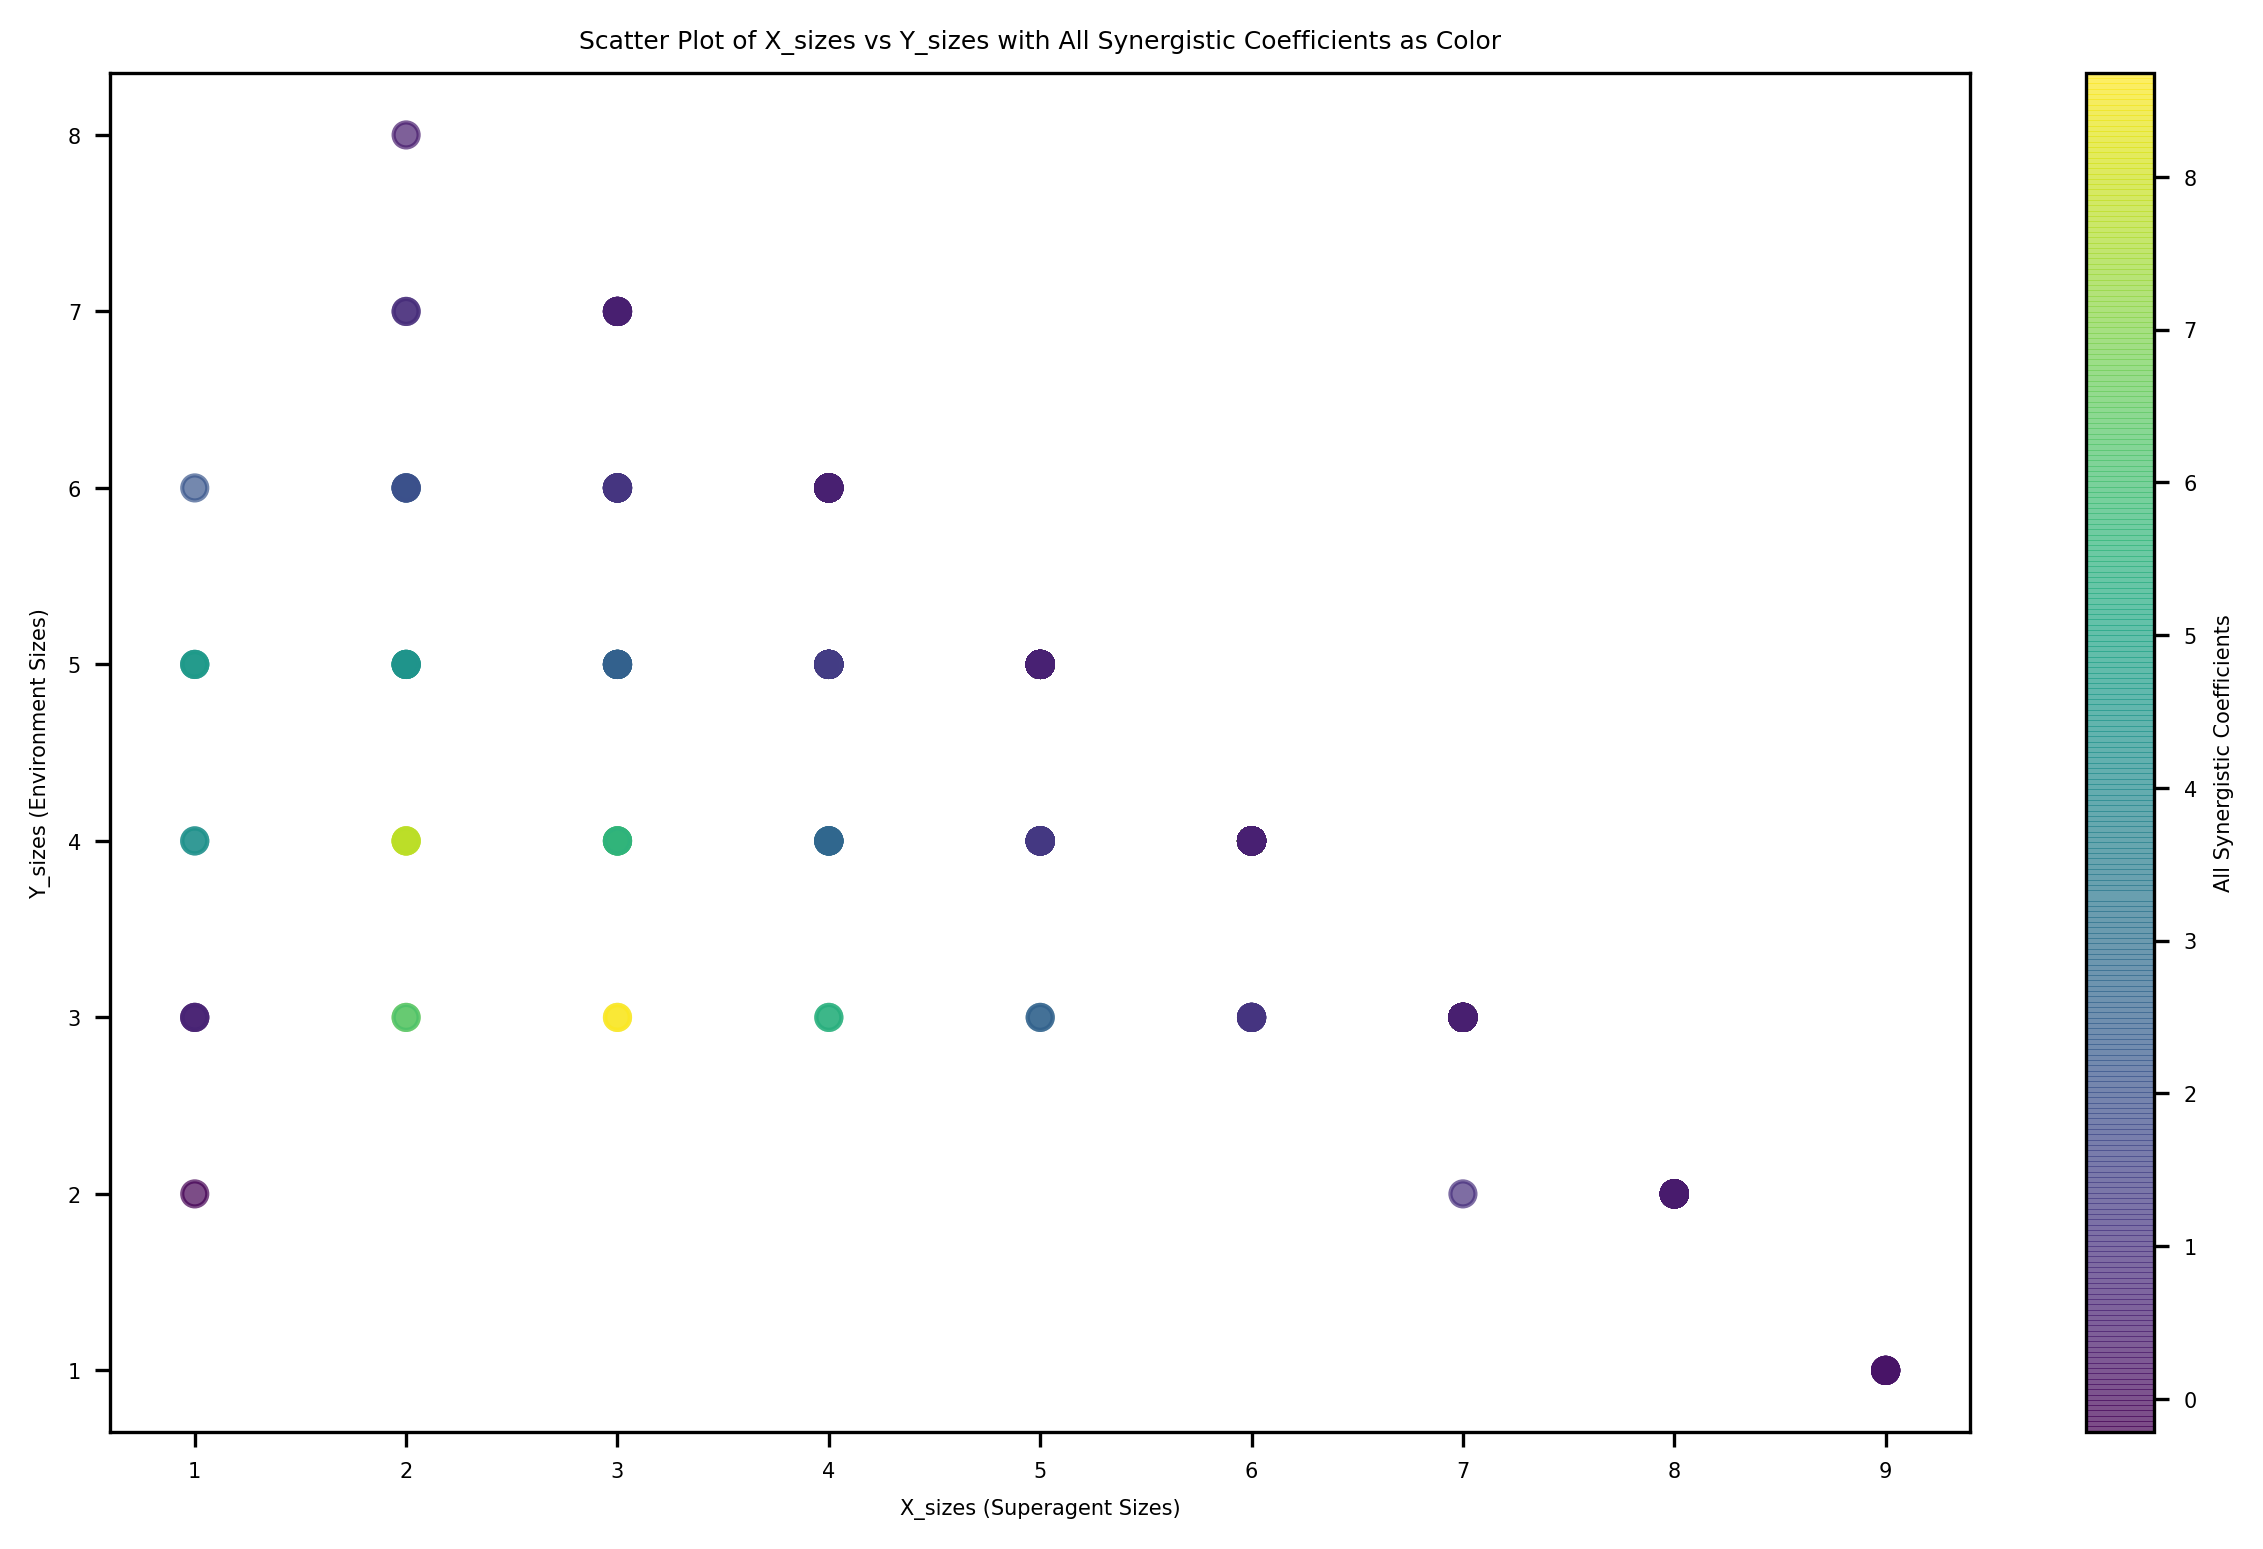

In [25]:
Y_sizes = np.array([p[1].shape[1] for p in all_partition_timeseries])
X_sizes = np.array([p[0].shape[1] for p in all_partition_timeseries])

plt.figure(figsize=(10, 6), dpi=150)
plt.scatter(
    X_sizes, 
    Y_sizes, 
    c=all_synergistic_coefficients, 
    cmap='viridis', 
    alpha=0.7
)
plt.colorbar(label='All Synergistic Coefficients')
plt.xlabel('X_sizes (Superagent Sizes)')
plt.ylabel('Y_sizes (Environment Sizes)')
plt.title('Scatter Plot of X_sizes vs Y_sizes with All Synergistic Coefficients as Color')
plt.show()

In [113]:
from tqdm import tqdm

# num_bins = 10
mi_estimator = JidtDiscreteCMI(settings=dict(
    # n_discrete_bins=num_bins,
    # discretise_method='max_ent',
))

all_Exi = []
# superagent_idx = 30
for i in tqdm(range(len(all_partition_timeseries))):
    superagent_idx = i
    data = all_partition_timeseries[superagent_idx]

    X = data[0]
    Y = data[1]

    # Compute the Causal Blanket states ----------------------------------------
    _, X_sub_flat, Y_sub_flat, conditional_probs = estimate_conditional_probabilities(X, Y, L=1)
    A_causal_states = get_minimal_DBaSS(X_sub_flat, conditional_probs)

    # _, Y_sub_flat, X_sub_flat, conditional_probs = estimate_conditional_probabilities(Y, X, L=1)
    # S_causal_states = get_minimal_DBaSS(Y_sub_flat, conditional_probs)

    # Convert to decimal representation ------------------------------------
    Y_sub_flat_decimal = np.dot(Y_sub_flat, 2**np.arange(Y_sub_flat.shape[1])[::-1]).astype(int)
    X_sub_flat_decimal = np.dot(X_sub_flat, 2**np.arange(X_sub_flat.shape[1])[::-1]).astype(int)

    mi_estimator = JidtDiscreteCMI(settings={
        'alph1': 2**X_sub_flat.shape[1],
        'alph2': 2**Y_sub_flat.shape[1],
        'alphc': 2**Y_sub_flat.shape[1] + 2**X_sub_flat.shape[1],
    })
    all_Exi.append(
        mi_estimator.estimate(
            X_sub_flat_decimal[1:], 
            Y_sub_flat_decimal[1:], 
            np.hstack((X_sub_flat_decimal[:-1], Y_sub_flat_decimal[:-1]))
        )
    )

100%|██████████| 643/643 [02:26<00:00,  4.39it/s]


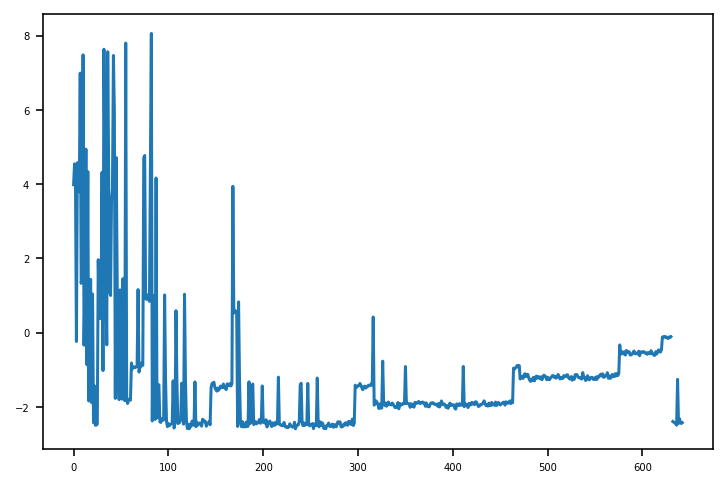

In [114]:
plt.plot(np.arange(len(all_Exi)), all_synergistic_coefficients - all_Exi)

## $TE(A \to Y)$

In [79]:
from tqdm import tqdm

# num_bins = 10
mi_estimator = JidtDiscreteCMI(settings=dict(
    # n_discrete_bins=num_bins,
    # discretise_method='max_ent',
))

all_TE_A_Y = []
all_TE_S_X = []
# superagent_idx = 30
for i in tqdm(range(len(all_partition_timeseries))):
    superagent_idx = i
    data = all_partition_timeseries[superagent_idx]

    X = data[0]
    Y = data[1]

    # Compute the Causal Blanket states ----------------------------------------
    _, X_sub_flat, Y_sub_flat, conditional_probs = estimate_conditional_probabilities(X, Y, L=1)
    A_causal_states = get_minimal_DBaSS(X_sub_flat, conditional_probs)

    _, Y_sub_flat, X_sub_flat, conditional_probs = estimate_conditional_probabilities(Y, X, L=1)
    S_causal_states = get_minimal_DBaSS(Y_sub_flat, conditional_probs)

    # Convert to decimal representation ------------------------------------
    Y_sub_flat_decimal = np.dot(Y_sub_flat, 2**np.arange(Y_sub_flat.shape[1])[::-1]).astype(int)
    X_sub_flat_decimal = np.dot(X_sub_flat, 2**np.arange(X_sub_flat.shape[1])[::-1]).astype(int)

    # Get timeseries of causal state labels ------------------------------------
    A_cs = np.empty(X_sub_flat.shape[0], dtype=int)
    for t, X_L in enumerate(X_sub_flat):
        X_L = tuple(X_L)
        for causal_state in A_causal_states:
            if X_L in causal_state['members']:
                A_cs[t] = causal_state['label']
                break

    mi_estimator = JidtDiscreteCMI(settings={
        'alph1': 2**X_sub_flat.shape[1],
        'alph2': 2**Y_sub_flat.shape[1],
        'alphc': 2**Y_sub_flat.shape[1],
    })
    all_TE_A_Y.append(
        mi_estimator.estimate(A_cs[:-1], Y_sub_flat_decimal[1:], Y_sub_flat_decimal[:-1])
    )


    S_cs = np.empty(Y_sub_flat.shape[0], dtype=int)
    for t, Y_L in enumerate(Y_sub_flat):
        Y_L = tuple(Y_L)
        for causal_state in S_causal_states:
            if Y_L in causal_state['members']:
                S_cs[t] = causal_state['label']
                break

    mi_estimator = JidtDiscreteCMI(settings={
        'alph1': 2**Y_sub_flat.shape[1],
        'alph2': 2**X_sub_flat.shape[1],
        'alphc': 2**X_sub_flat.shape[1],
    })
    all_TE_S_X.append(
        mi_estimator.estimate(S_cs[:-1], X_sub_flat_decimal[1:], X_sub_flat_decimal[:-1])
    )    

 98%|█████████▊| 631/643 [05:15<00:06,  2.00it/s]


AssertionError: 

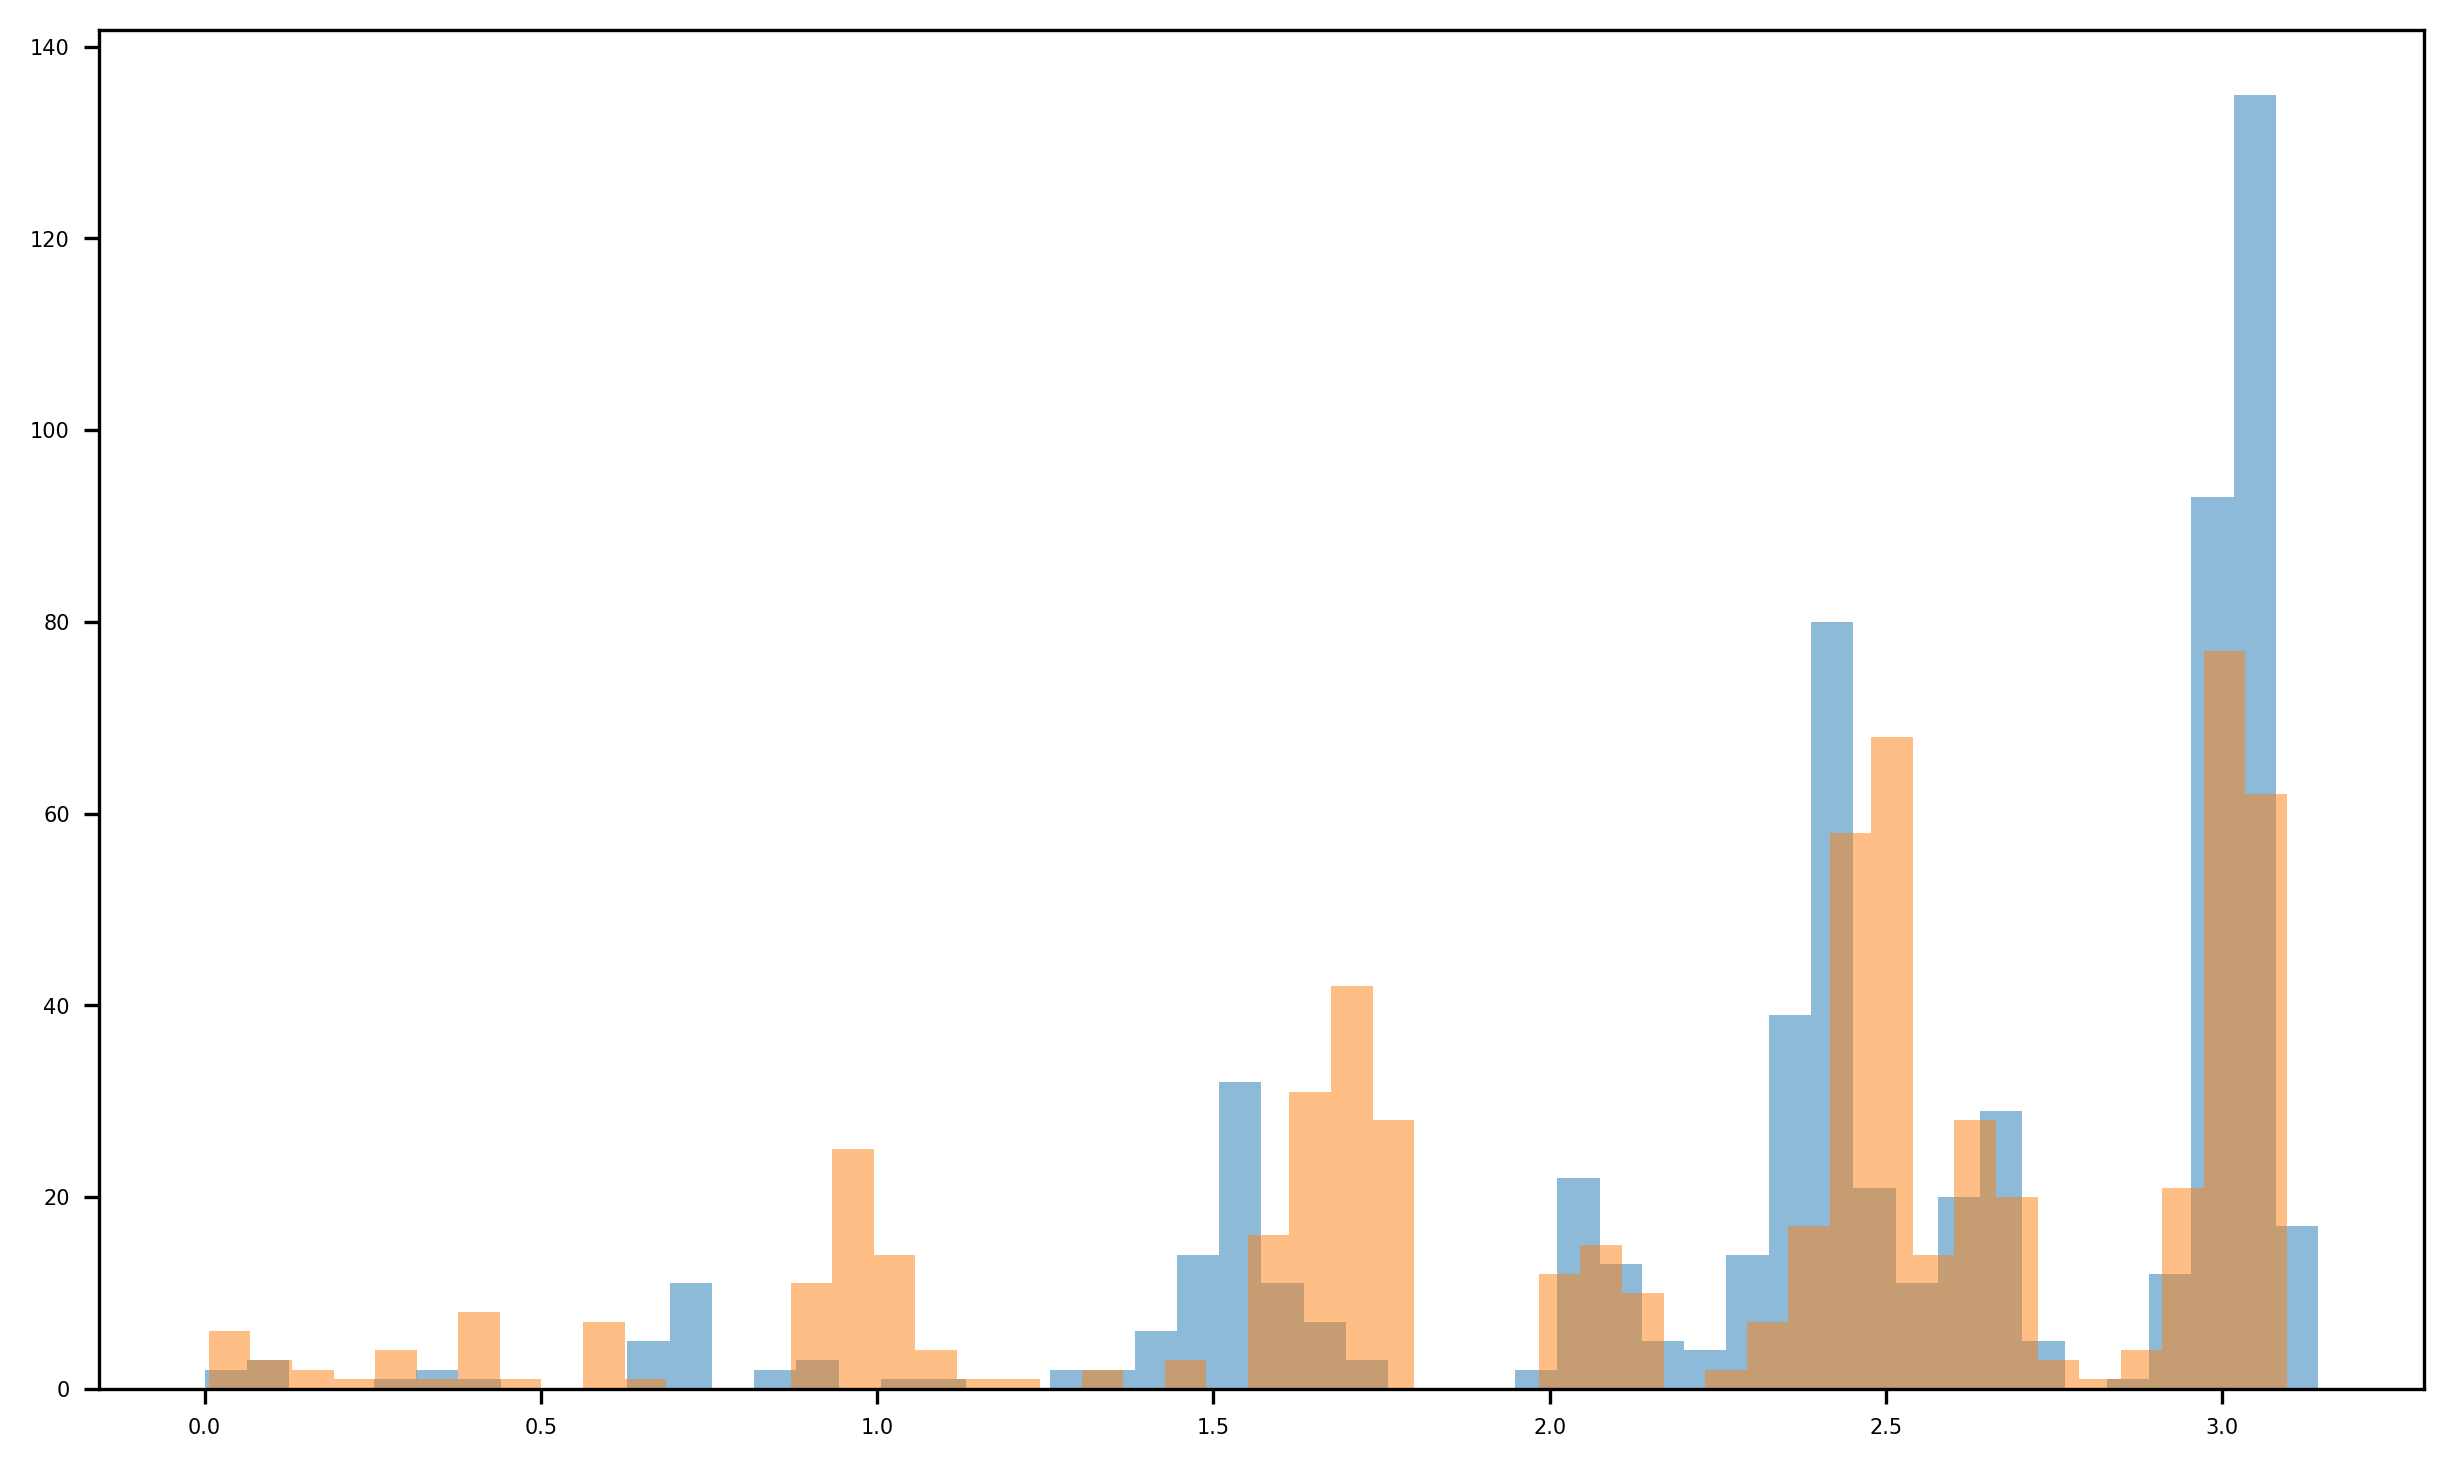

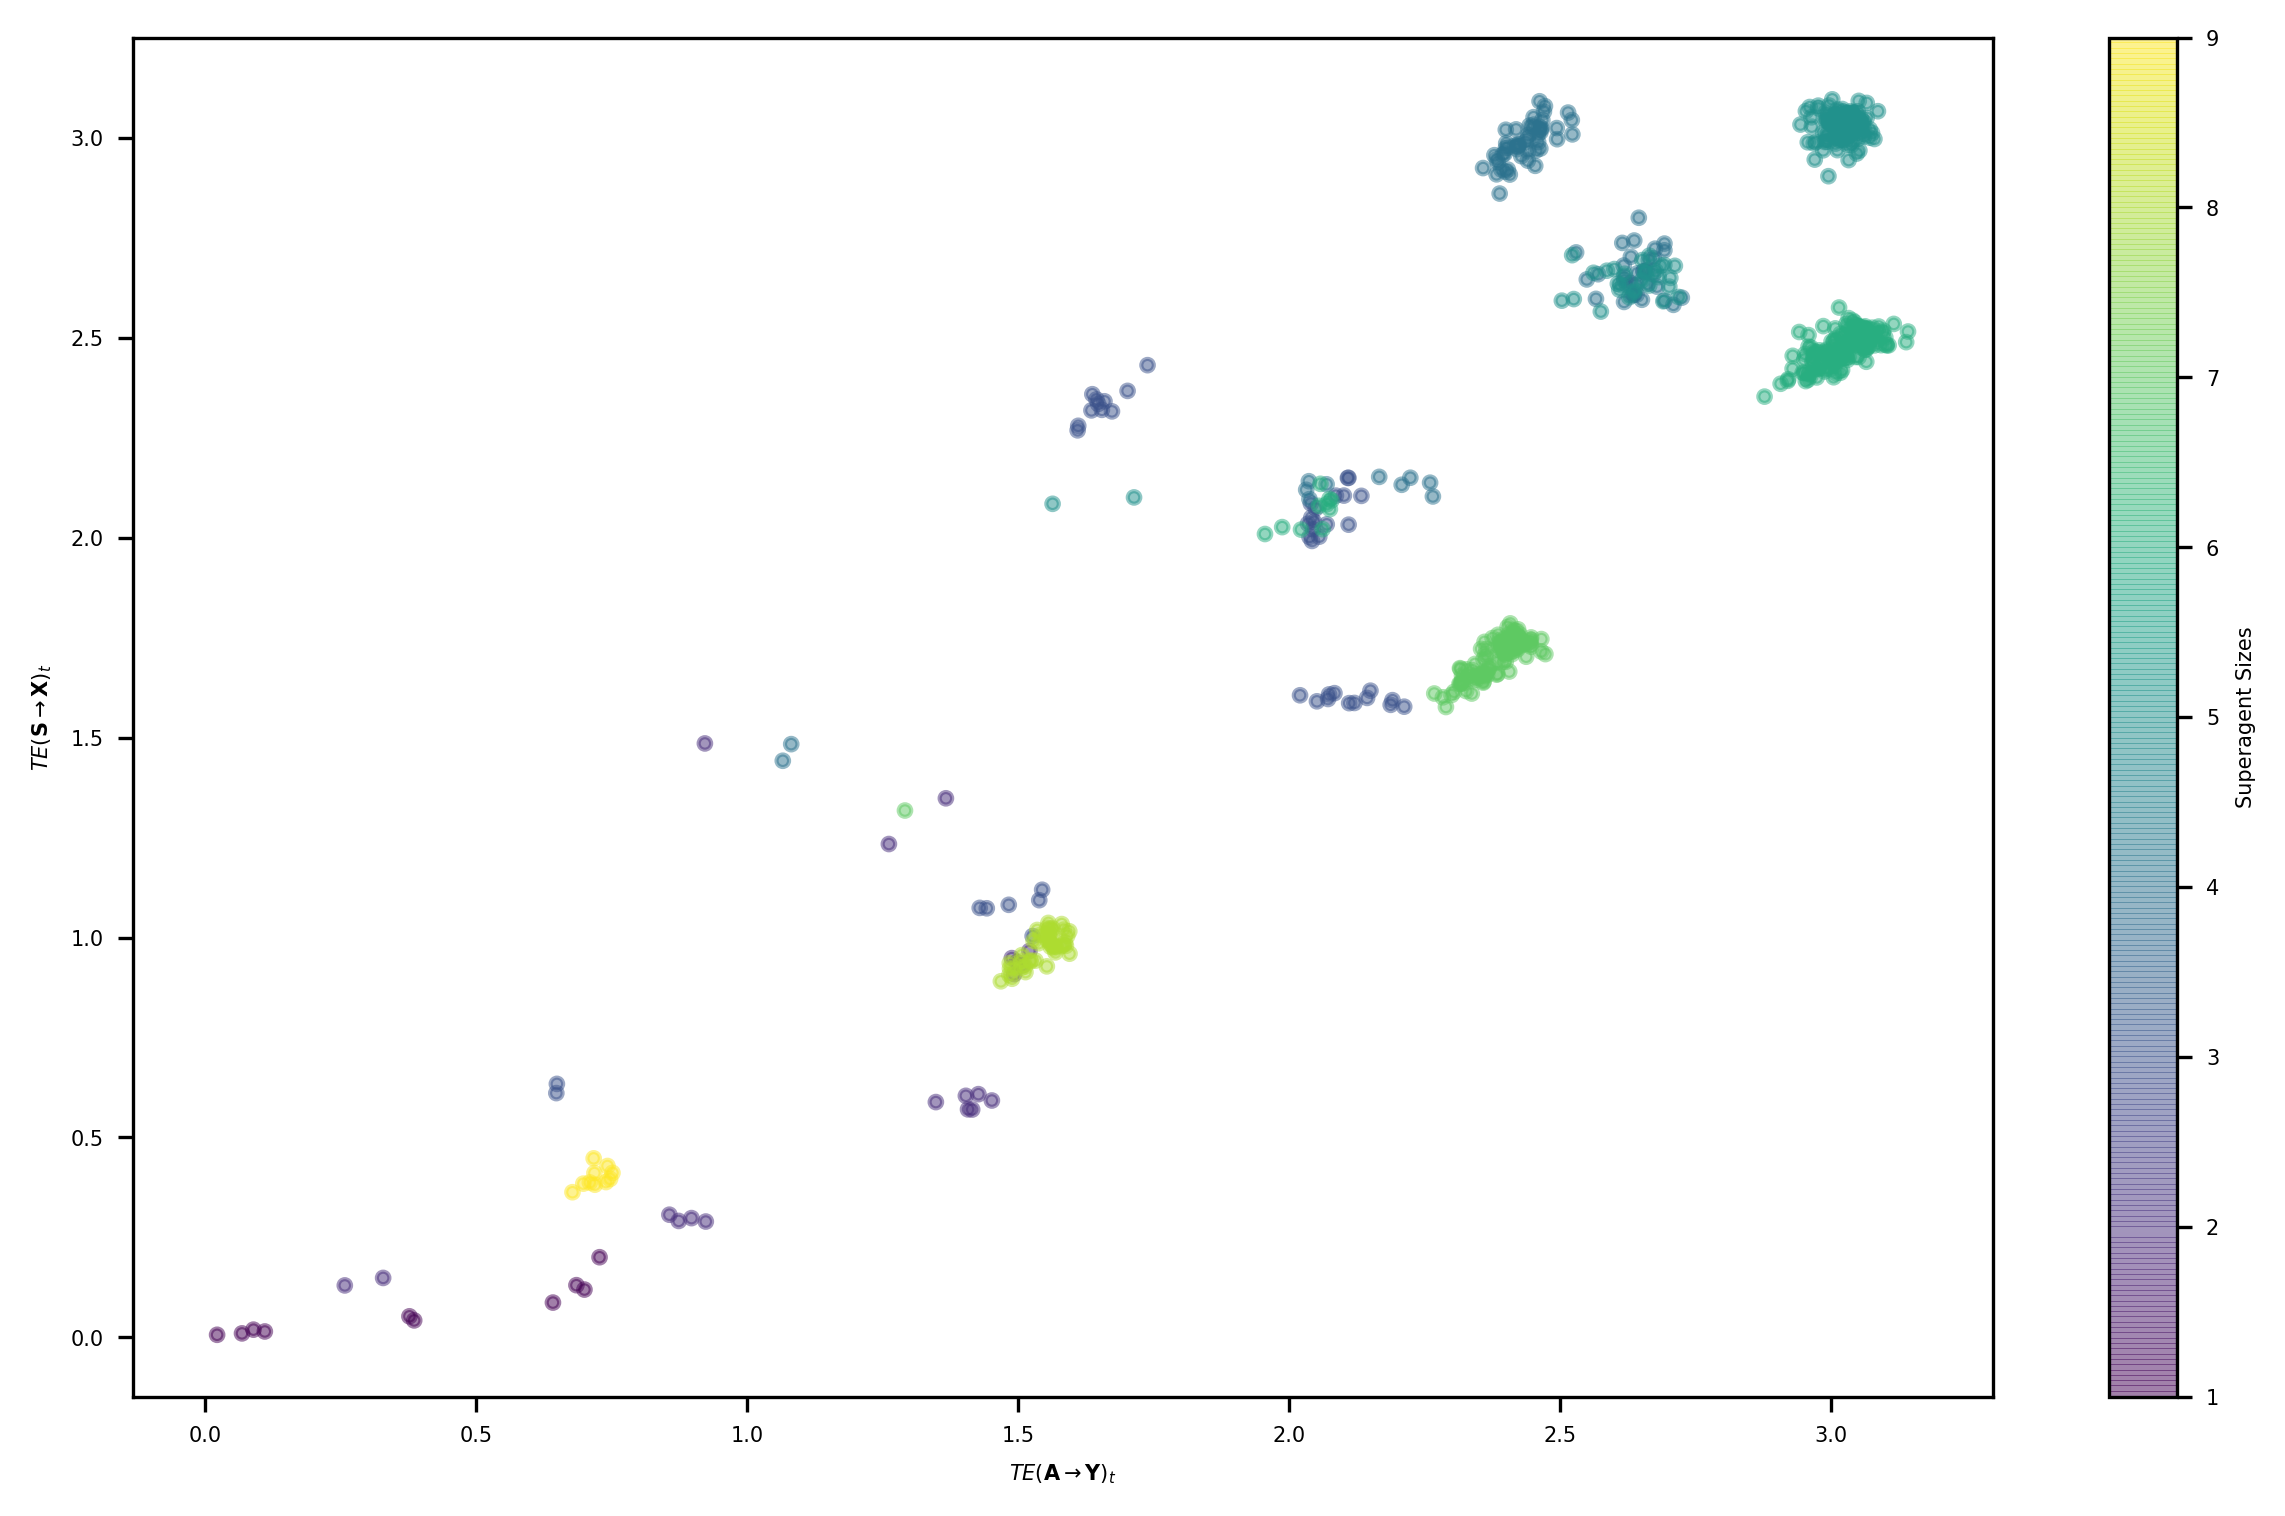

In [95]:
plt.figure(figsize=(10, 6), dpi=150)
plt.hist(all_TE_A_Y, alpha=0.5, bins=50)
plt.hist(all_TE_S_X, alpha=0.5, bins=50)
plt.show()


plt.figure(figsize=(10, 6), dpi=150)
plt.scatter(
    all_TE_A_Y[:len(all_TE_S_X)], 
    all_TE_S_X,
    alpha=0.5,
    c=superagent_sizes[:len(all_TE_S_X)],
    marker='.',
)
plt.colorbar(label='Superagent Sizes')
plt.xlabel(r"$TE(\mathbf{A} \rightarrow \mathbf{Y})_t$")
plt.ylabel(r"$TE(\mathbf{S} \rightarrow \mathbf{X})_t$")
plt.show()

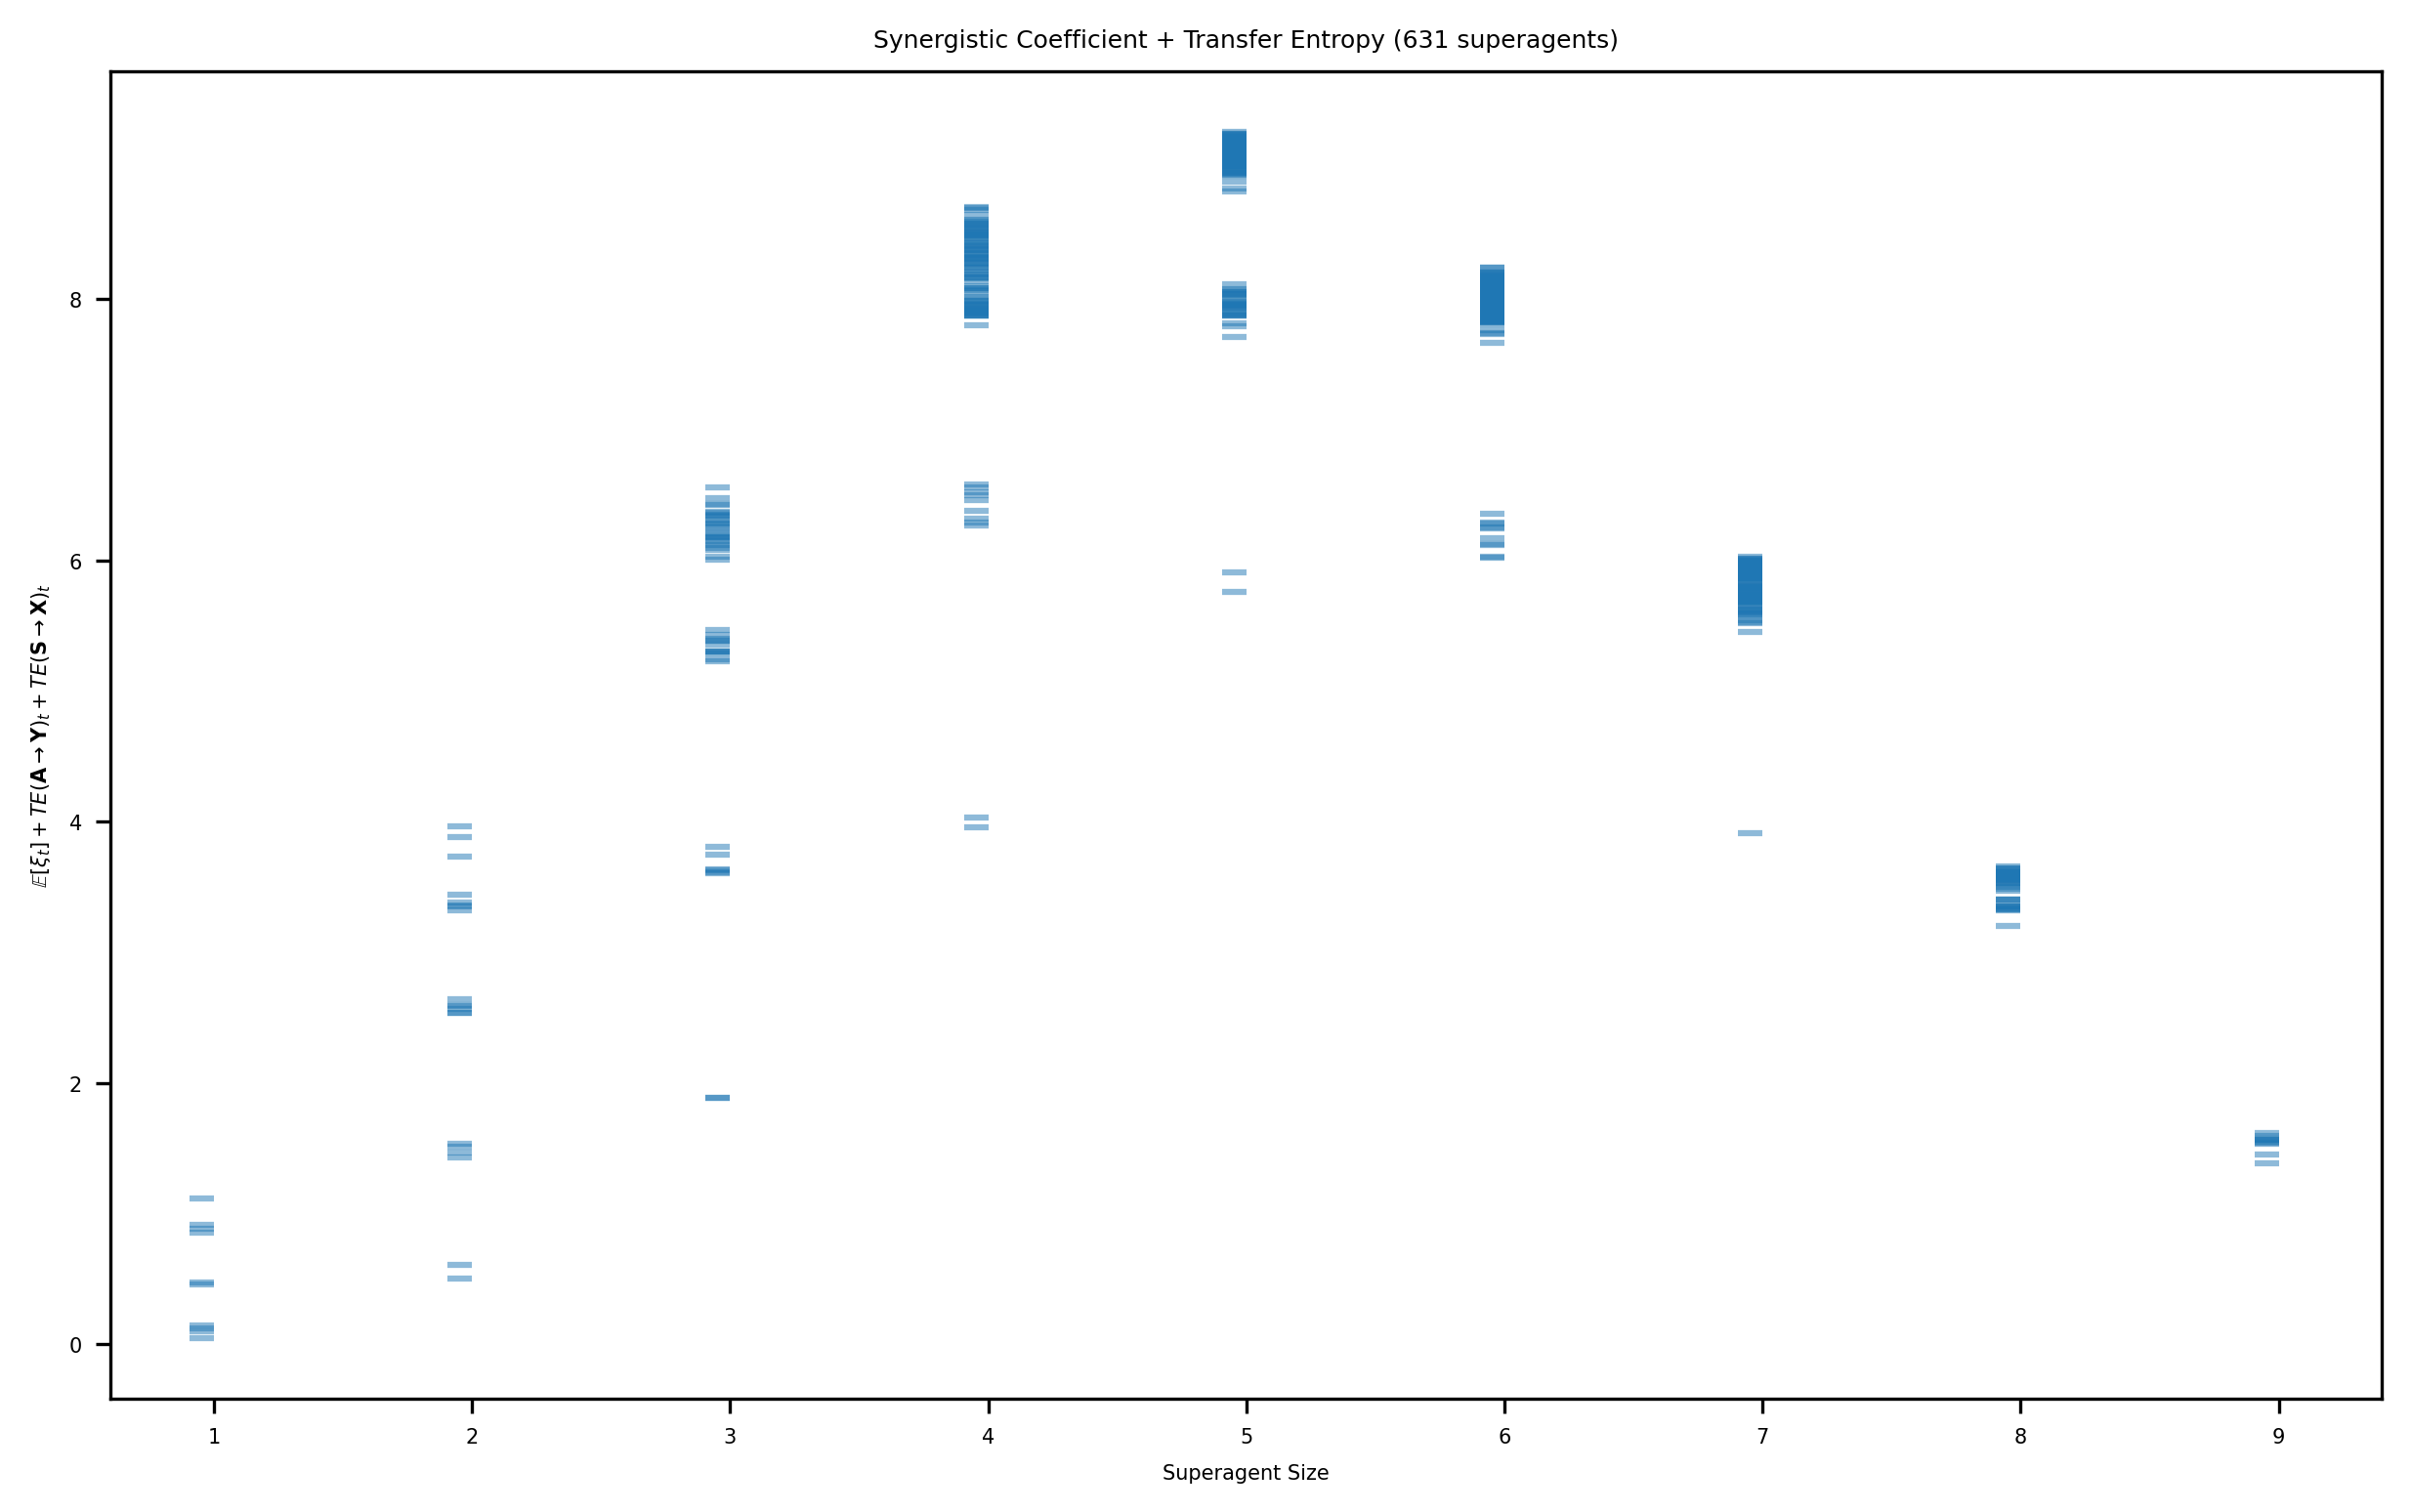

In [117]:
plt.figure(figsize=(10, 6), dpi=150)
all_TE_A_Y = np.array(all_TE_A_Y)
all_TE_S_X = np.array(all_TE_S_X)
plt.scatter(
    superagent_sizes[:len(all_TE_S_X)],
    # all_synergistic_coefficients[:len(all_TE_S_X)] + all_TE_A_Y[:len(all_TE_S_X)] + all_TE_S_X,
    all_Exi[:len(all_TE_S_X)] + all_TE_A_Y[:len(all_TE_S_X)] + all_TE_S_X,
    alpha=0.5,
    marker=0
)
plt.xlabel("Superagent Size")
plt.ylabel(r"$\mathbb{E}[\xi_t] + TE(\mathbf{A} \rightarrow \mathbf{Y})_t + TE(\mathbf{S} \rightarrow \mathbf{X})_t$")
plt.title(f"Synergistic Coefficient + Transfer Entropy ({len(all_TE_S_X)} superagents)")
plt.show()

631


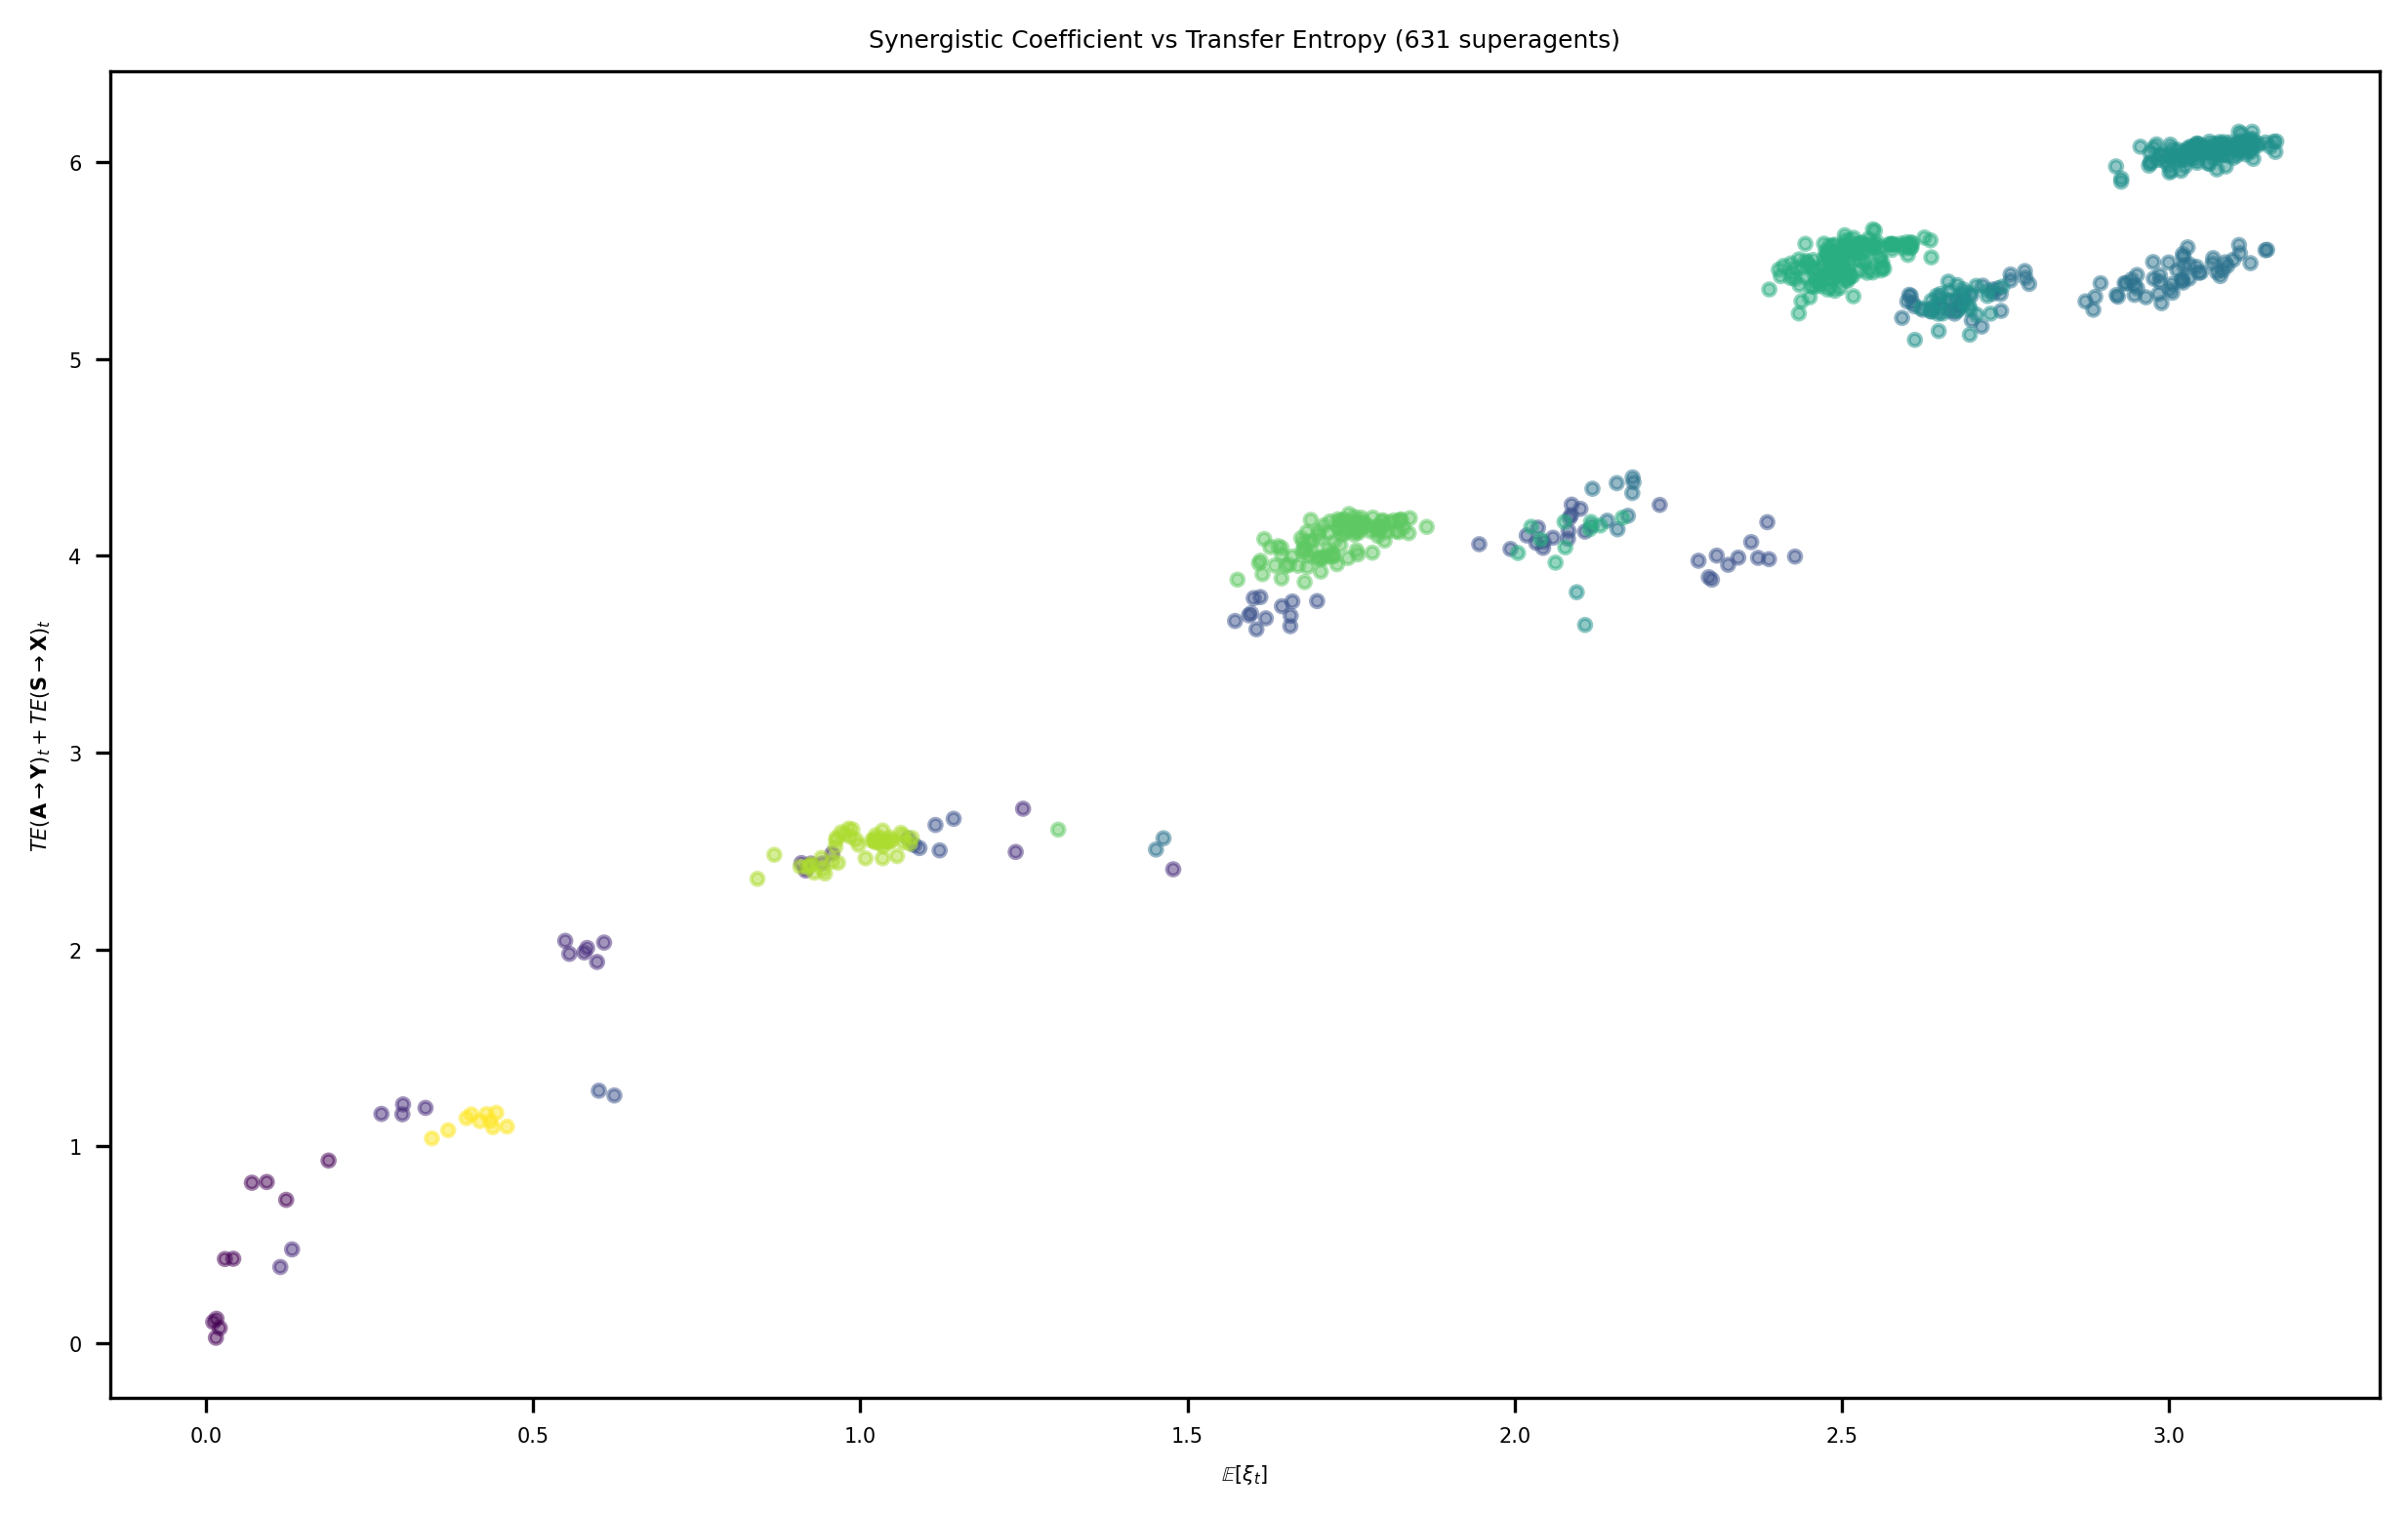

In [119]:
plt.figure(figsize=(10, 6), dpi=150)
print(len(all_TE_A_Y[:len(all_TE_S_X)] + all_TE_S_X))
plt.scatter(
    # all_synergistic_coefficients[:len(all_TE_S_X)],
    all_Exi[:len(all_TE_S_X)],
    all_TE_A_Y[:len(all_TE_S_X)] + all_TE_S_X,
    alpha=0.5,
    c=superagent_sizes[:len(all_TE_S_X)],
    marker='.'
)
plt.xlabel(r"$\mathbb{E}[\xi_t]$")
plt.ylabel(r"$TE(\mathbf{A} \rightarrow \mathbf{Y})_t + TE(\mathbf{S} \rightarrow \mathbf{X})_t$")
plt.title(f"Synergistic Coefficient vs Transfer Entropy ({len(all_TE_S_X)} superagents)")
plt.show()

## IIT

The following measure is a sufficient condition for "causal emergence":

$$
\Psi = I(V_t; V_{t+1}) - \sum_i I(X^i_t; V_{t+1})
$$

* This is Eq. 10a in [@Rosas2020ReconcilingEmergences](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1008289#sec003)
* See also Eq. 1 in [@McSharry2024LearningDiverse](https://proceedings.neurips.cc/paper_files/paper/2024/hash/d8398f4da88975e2a9c62ecaa5ba267b-Abstract-Conference.html)

⚠️ The question remains: how to select the right coarse-graining $V = f(X)$? [@McSharry2024LearningDiverse](https://proceedings.neurips.cc/paper_files/paper/2024/hash/d8398f4da88975e2a9c62ecaa5ba267b-Abstract-Conference.html) addresses this with deep learning.

In [36]:
mappings = {
    'mean': lambda x: x.mean(axis=1),
    'max': lambda x: x.max(axis=1),
    'min': lambda x: x.min(axis=1),
    'std': lambda x: x.std(axis=1),
}

results_psi = {k: [] for k in mappings.keys()}

for key, mapping in mappings.items():
    for S_history, E_history in all_partition_timeseries:
        psi = 0
        
        # First (global) term
        num_bins = 10
        mi_estimator = JidtDiscreteMI(
            settings=dict(
                discretise_method='max_ent',
                n_discrete_bins=num_bins,
                )
        )
        V = mappings[key](S_history)
        # Discretize V
        source = V[:-1]
        target = V[1:]
        mi_result = mi_estimator.estimate(source, target)

        psi += mi_result
        
        # Second (local) term
        for i in range(S_history.shape[1]):
            source = S_history[:-1, i]
            target = V[1:]
            mi_result = mi_estimator.estimate(source, target)
            psi -= mi_result

        results_psi[key].append(psi)

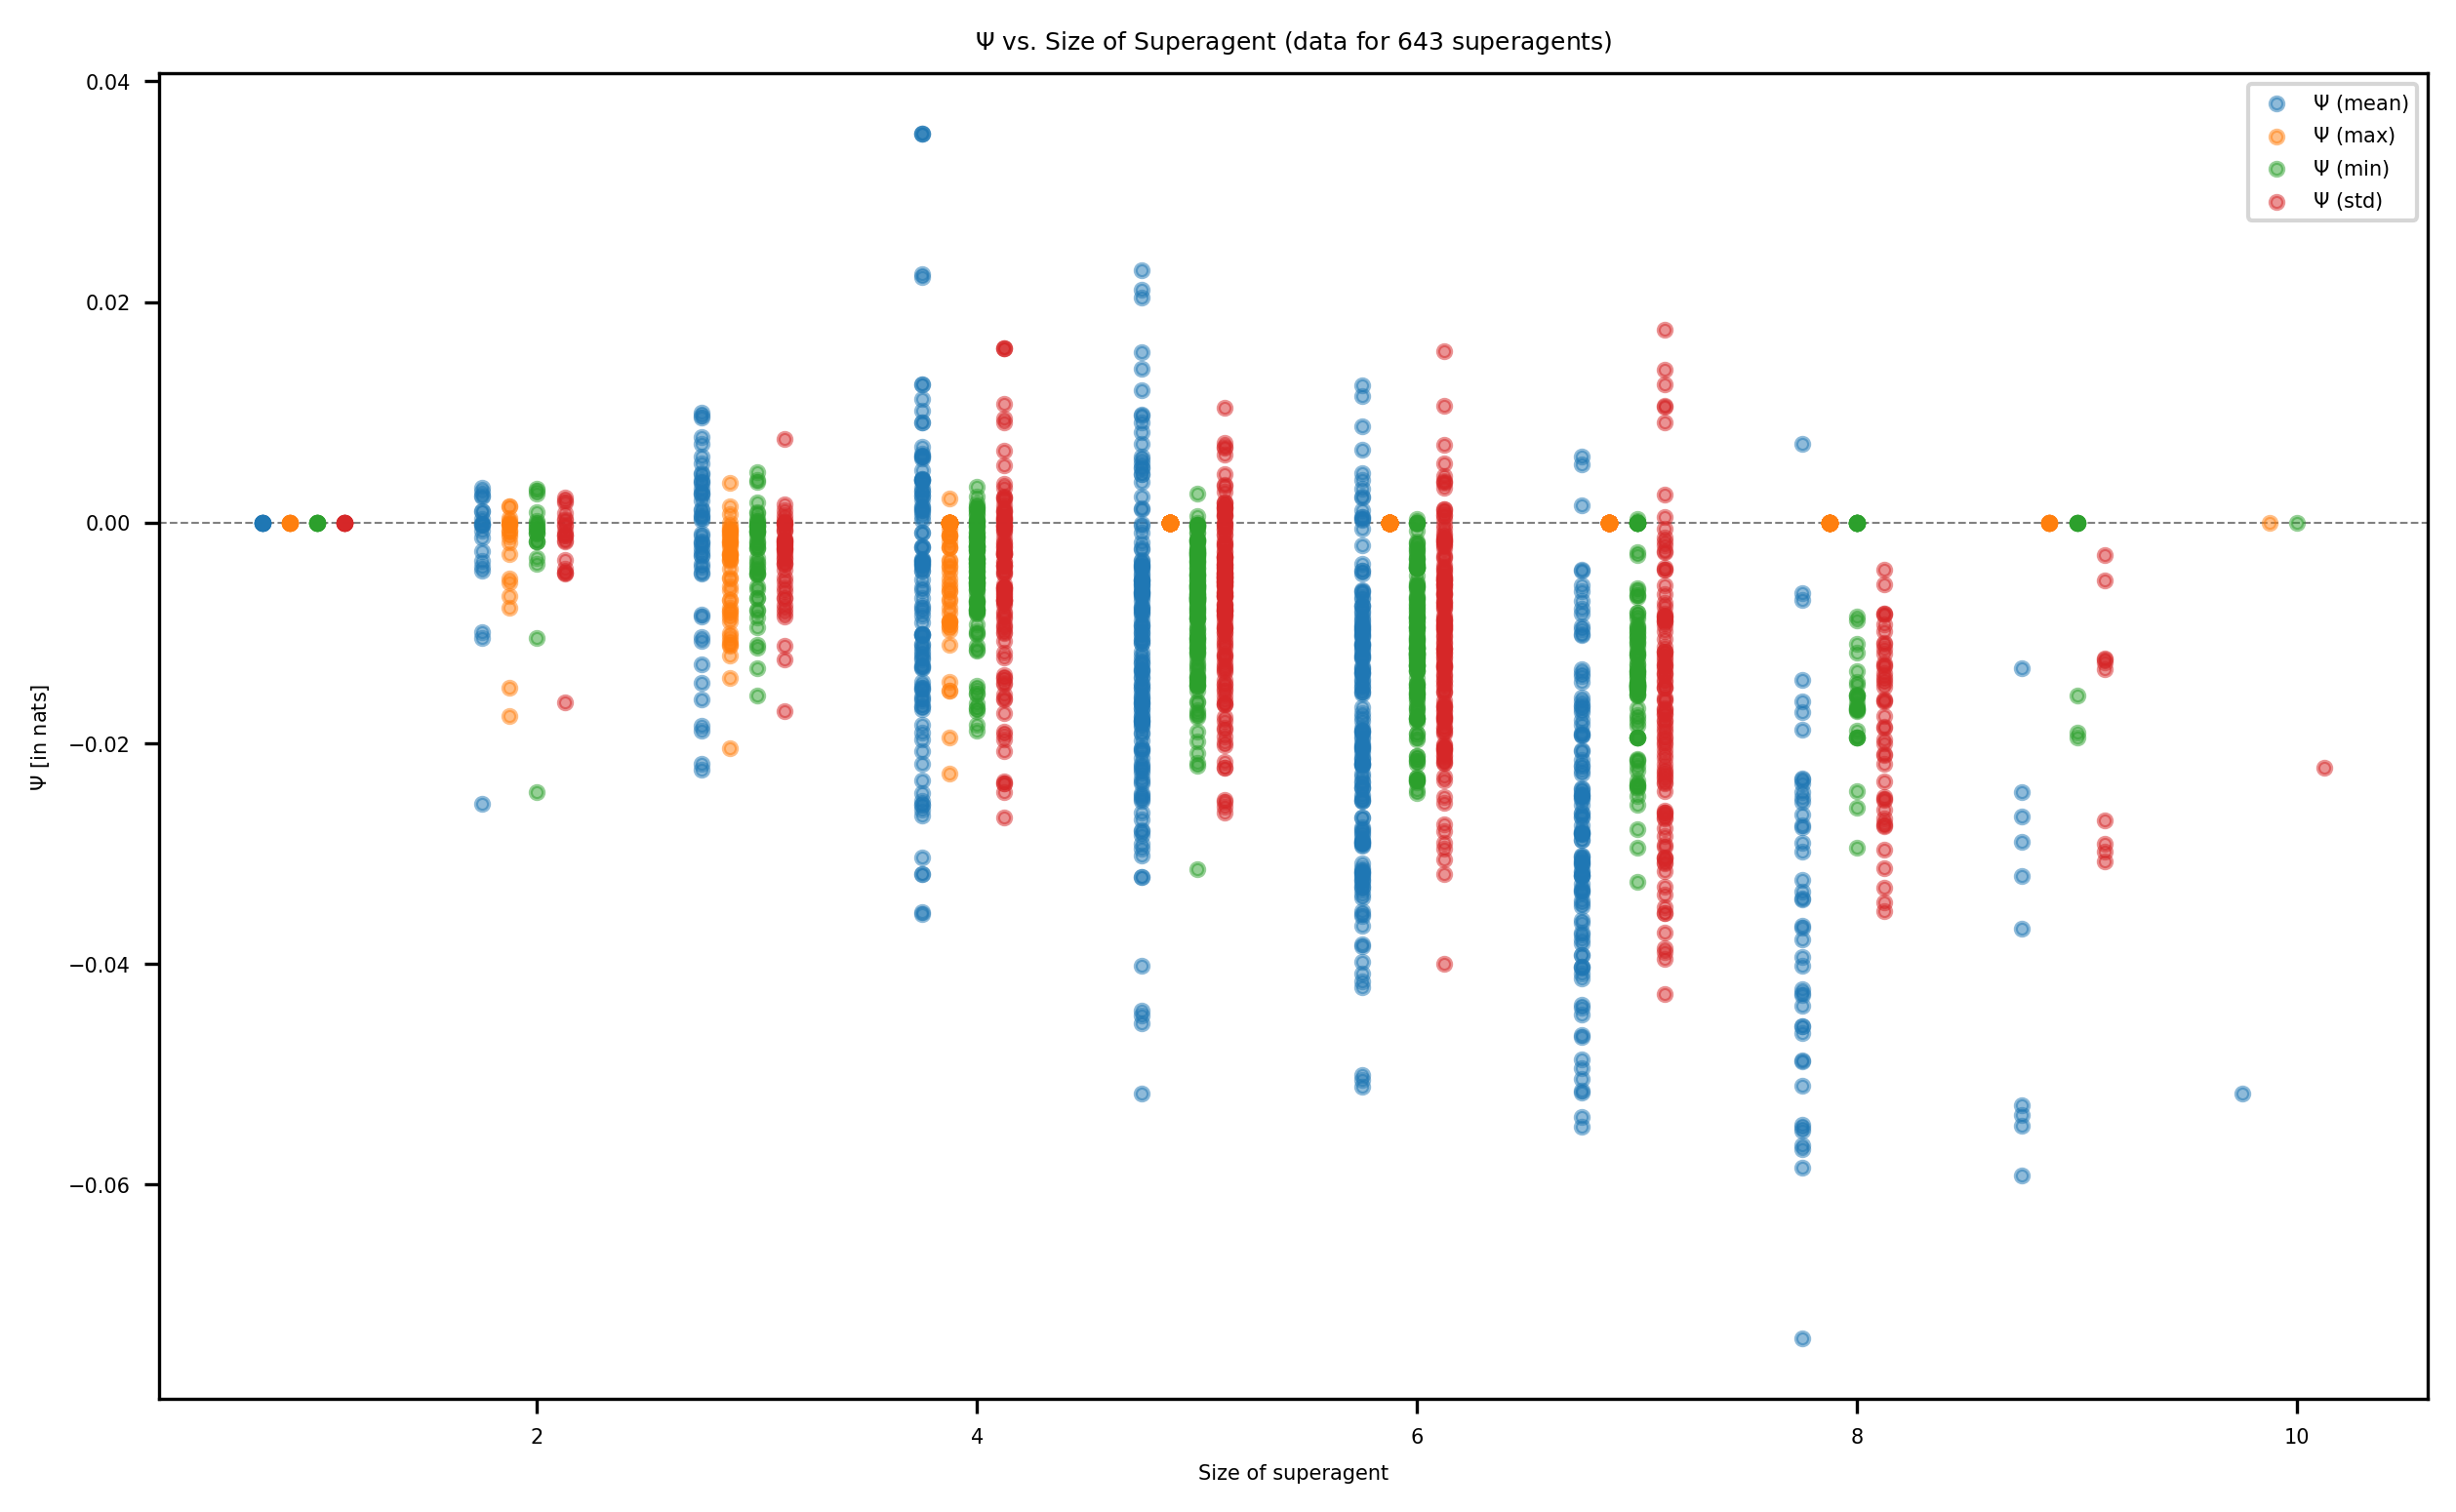

In [38]:
results_psi = {
    k: np.array(v) for k, v in results_psi.items()
}

plt.figure(figsize=(10, 6), dpi=150)

jitters = np.arange(-0.25, 0.25, 0.125)
for i, (key, result) in enumerate(results_psi.items()):
    plt.scatter(
        superagent_sizes[:len(result)] + jitters[i], 
        result, 
        alpha=0.5, 
        s=10,
        label=f"$\Psi$ ({key})"
    )

plt.axhline(0, color='gray', linestyle='--', linewidth=0.5, zorder=-10)

plt.xlabel('Size of superagent')
plt.ylabel(r'$\Psi$ [in nats]')
plt.title(f'$\Psi$ vs. Size of Superagent (data for {len(results_psi[list(results_psi.keys())[0]])} superagents)')
plt.legend()
plt.show()

### Minimum Mutual Information-adjusted measure

$$
\Psi = I(V_t; V_{t+1}) - \sum_i I(X^i_t; V_{t+1}) + (n-1)\min_i I(X^i_t; V_{t+1})
$$

* Eq. 2 in [@McSharry2024LearningDiverse](https://proceedings.neurips.cc/paper_files/paper/2024/hash/d8398f4da88975e2a9c62ecaa5ba267b-Abstract-Conference.html)

In [12]:
mappings = {
    'mean': lambda x: x.mean(axis=1),
    'max': lambda x: x.max(axis=1),
    'min': lambda x: x.min(axis=1),
    'std': lambda x: x.std(axis=1),
}

results_psi = {k: [] for k in mappings.keys()}

for key, mapping in mappings.items():
    for S_history, E_history in all_partition_timeseries:
        psi = 0
        
        # First (global) term
        num_bins = 10
        mi_estimator = JidtDiscreteMI(
            settings=dict(n_discrete_bins=num_bins)
        )
        V = mappings[key](S_history)
        # Discretize V
        V = np.digitize(V, bins=np.linspace(V.min(), V.max(), num_bins)).astype(np.int32) - 1
        source = V[:-1]
        target = V[1:]
        mi_result = mi_estimator.estimate(source, target)

        psi += mi_result
        
        # Second (local) term
        local_mi_results = []
        for i in range(S_history.shape[1]):
            mi_estimator = JidtDiscreteMI(
                settings=dict(n_discrete_bins=num_bins)
            )
            source = S_history[:-1, i]
            target = V[1:]
            mi_result = mi_estimator.estimate(source, target)
            local_mi_results.append(mi_result)
            psi -= mi_result

        # Third term: MMI adjustment
        local_mi_results = np.array(local_mi_results)
        psi += len(local_mi_results) * local_mi_results.min()

        results_psi[key].append(psi)

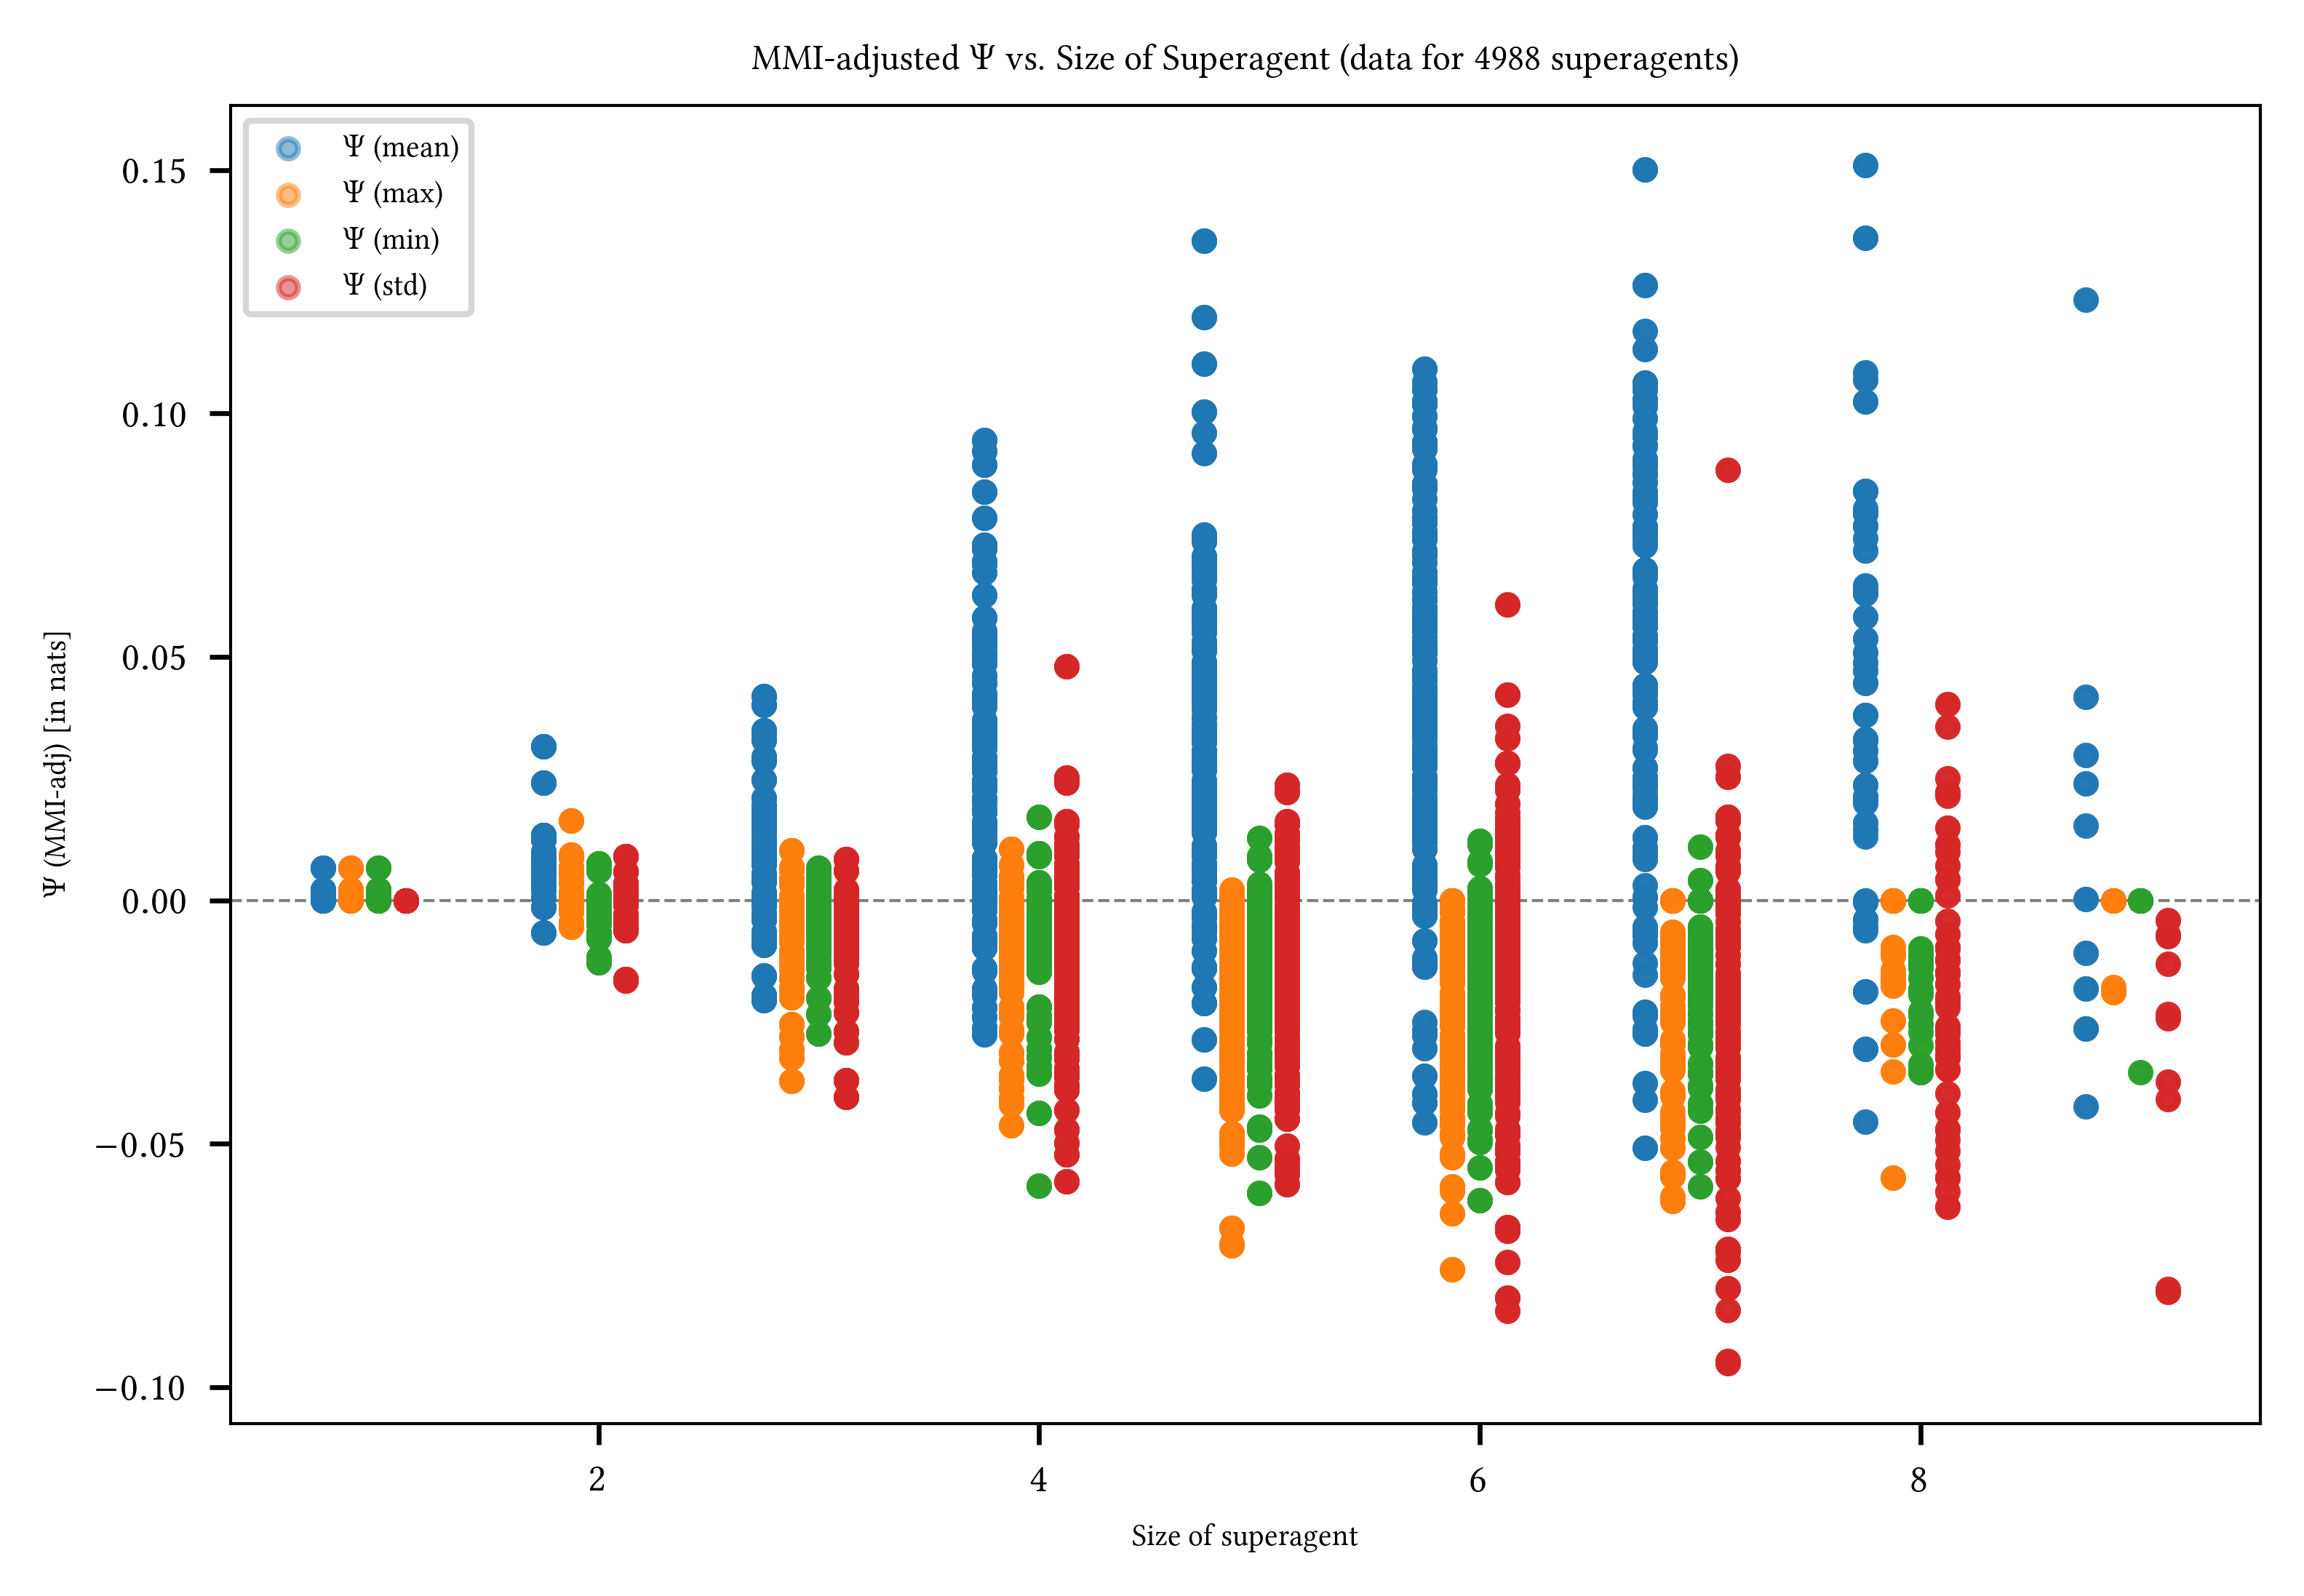

In [11]:
results_psi = {
    k: np.array(v) for k, v in results_psi.items()
}

jitters = np.arange(-0.25, 0.25, 0.125)
for i, (key, result) in enumerate(results_psi.items()):
    plt.scatter(
        superagent_sizes[:len(result)] + jitters[i], 
        result, 
        alpha=0.5, 
        s=10,
        label=f"$\Psi$ ({key})"
    )

plt.axhline(0, color='gray', linestyle='--', linewidth=0.5, zorder=-10)

plt.xlabel('Size of superagent')
plt.ylabel(r'$\Psi$ (MMI-adj) [in nats]')
plt.title(f'MMI-adjusted $\Psi$ vs. Size of Superagent (data for {len(results_psi[list(results_psi.keys())[0]])} superagents)')
plt.legend()
plt.show()

## IDEA: how much does each agent contribute to the superagent? 

I.e. what is the relative $I(X_i; V)$ for each agent $i$?

In [39]:
num_bins = 10
mi_estimator = JidtDiscreteMI(settings=dict(
    n_discrete_bins=num_bins,
    discretise_method='max_ent',
))

all_contributions = []
for data in all_partition_timeseries:
    X = data[0]
    Y = data[1]

    V = X.mean(axis=1)

    local_mi_results = []
    for i in range(X.shape[1]):
        source = X[:-1, i]
        target = V[1:]
        local_mi_results.append(mi_estimator.estimate(source, target))

    contributions = np.array(local_mi_results) / np.sum(local_mi_results)
    all_contributions.append(contributions)

In [58]:
len(superagent_sizes), len(all_contributions), len(all_partition_timeseries)

(643, 643, 643)

/Users/jaime/miniconda3/envs/ma-aif-dit/lib/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: invalid value encountered in true_divide
  import sys


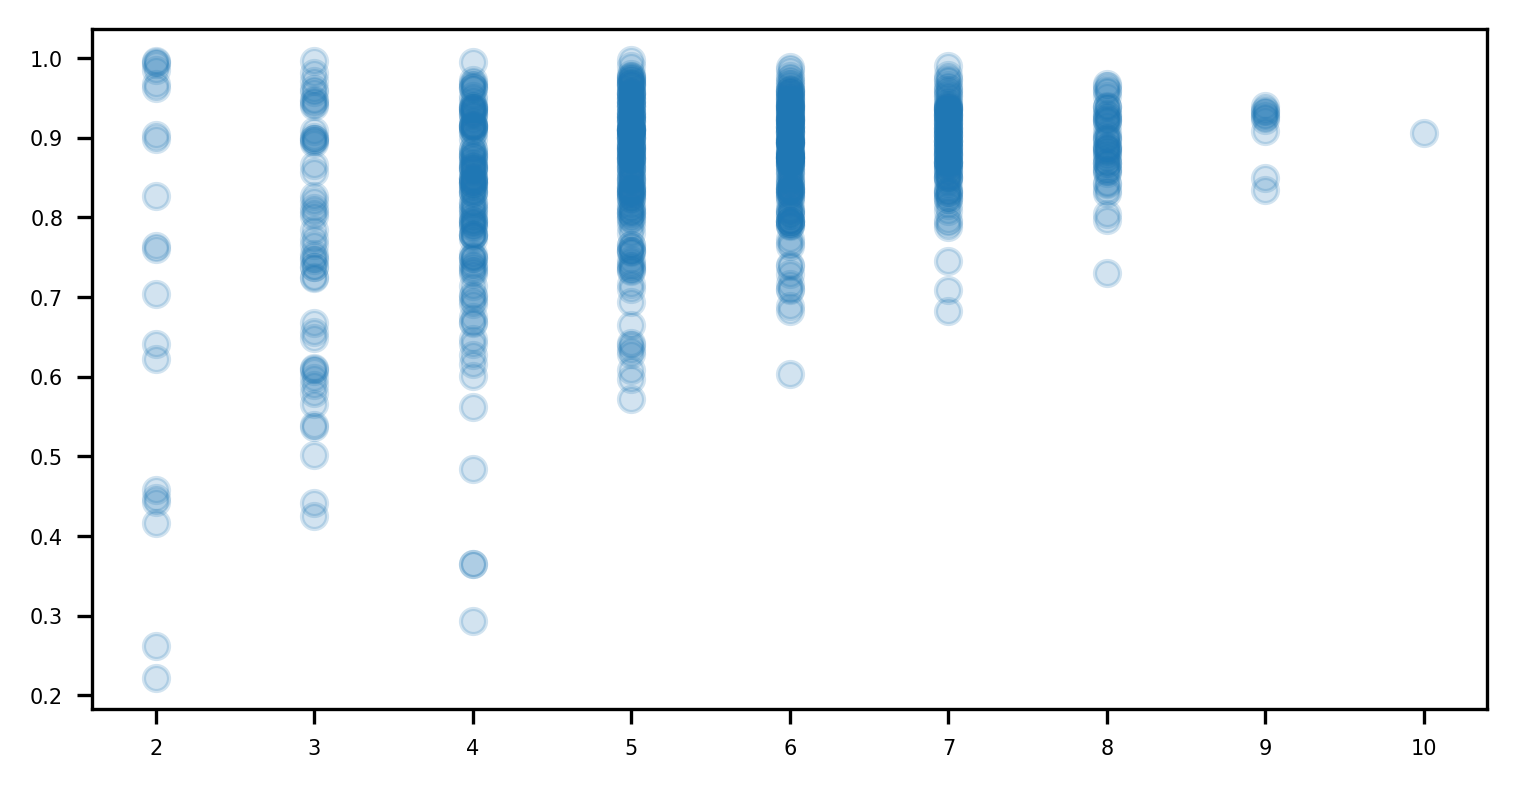

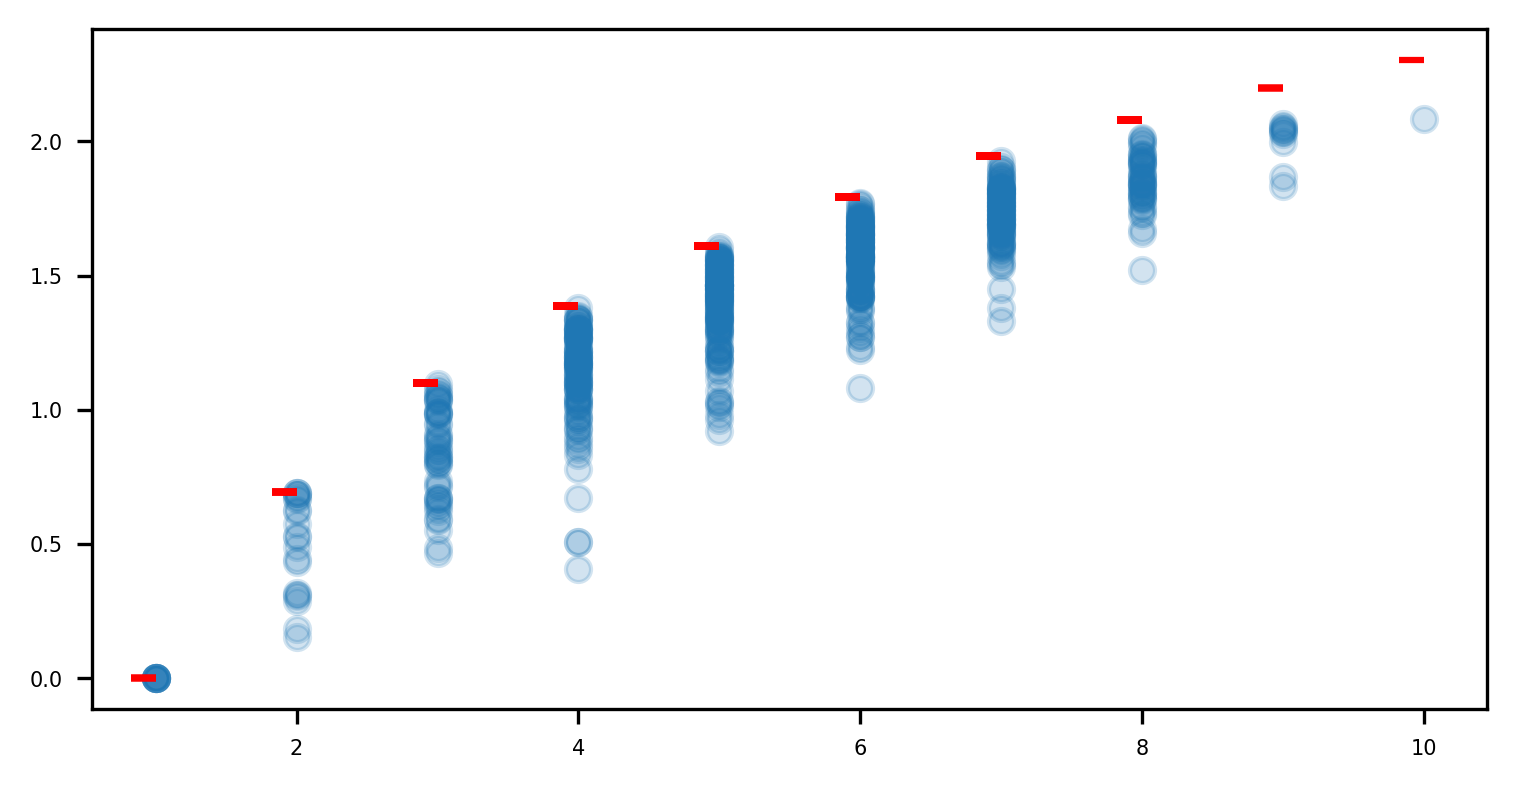

In [59]:
from scipy.stats import entropy
superagent_contribution_entropies = [entropy(contributions) for contributions in all_contributions]

plt.figure(figsize=(6, 3), dpi=150)
plt.scatter(
    superagent_sizes, 
    superagent_contribution_entropies/np.log(superagent_sizes), 
    alpha=0.2, 
    # c=superagent_env_det_info,
    cmap='viridis', 
    label="Environmental Determined Individuality"
)

plt.figure(figsize=(6, 3), dpi=150)
plt.scatter(
    superagent_sizes, 
    superagent_contribution_entropies, 
    alpha=0.2, 
    # c=superagent_env_det_info,
    cmap='viridis', 
    label="Environmental Determined Individuality"
)
plt.scatter(
    superagent_sizes, 
    np.log(superagent_sizes), 
    c='red', 
    marker=0,
    zorder=10
)

## IDEA: optimise linear coarse-graining function $V$ w.r.t. $\Psi$

Let:
$$
V = \sum_i w_i X^i
$$

Optimise $w_i$ w.r.t. $\Psi$.

$$
\Psi = I(V_t; V_{t+1}) - \sum_i I(X^i_t; V_{t+1})
$$

In [ ]:
# from scipy.optimize import minimize

# # Define the objective function for optimization
# def psi_objective(w, X, num_bins=10):
#     """
#     Objective function to minimize Psi = I(V_t; V_{t+1}) - sum_i I(X^i_t; V_{t+1})
#     """
#     # Compute V = sum_i w_i * X^i
#     V = X @ w

#     # Compute the first term: I(V_t; V_{t+1})
#     mi_estimator = JidtDiscreteMI(settings=dict(
#         n_discrete_bins=num_bins,
#         discretise_method='max_ent',
#     ))
#     source = V[:-1]
#     target = V[1:]
#     I_Vt_Vt1 = mi_estimator.estimate(source, target)

#     # Compute the second term: sum_i I(X^i_t; V_{t+1})
#     I_Xi_Vt1_sum = 0
#     for i in range(X.shape[1]):
#         source = X[:-1, i]
#         target = V[1:]
#         I_Xi_Vt1_sum += mi_estimator.estimate(source, target)

#     # Compute Psi
#     psi = I_Vt_Vt1 - I_Xi_Vt1_sum

#     return -psi  # Minimize negative Psi to maximize Psi

In [ ]:
# for superagent_idx in range(len(all_partition_timeseries)):

#     data = all_partition_timeseries[superagent_idx]
#     X = data[0]
#     Y = data[1]

#     # Initialize weights
#     num_features = X.shape[1]
#     initial_weights = np.ones(num_features) / num_features

#     # Optimize weights
#     result = minimize(
#         psi_objective, 
#         initial_weights, 
#         args=(X), 
#         method='L-BFGS-B', 
#         bounds=[(0, 1)] * num_features,
#         tol=1e-6,
#         options={'disp': True}
#     )

#     # Extract optimized weights
#     optimized_weights = result.x
#     print("Optimized weights:", optimized_weights)

#     # Compute the final V using the optimized weights
#     V_optimized = X @ optimized_weights

Optimized weights: [1.]
Optimized weights: [1.]
Optimized weights: [1.]
Optimized weights: [1.]
Optimized weights: [1.]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.5 0.5]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333762 0.33333119 0.33333762]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.33333333 0.33333333 0.33333333]
Optimized weights: [0.25 0.25 0.25 0.25]
Optimized weights: [0.2500021 0.2500021 0.2500021 0.2499993]
Optimi

KeyboardInterrupt: 

## epsilon Machines, D-BaSS

In [49]:
from collections import Counter
import numpy as np

From [@Rosas2020CausalBlankets](http://arxiv.org/abs/2008.12568)

**Proposition 1**: Given stochastic processes $\boldsymbol{X}$, $\boldsymbol{Y}$, their Causal Blanket (CB) always exists and is unique (up to an isomorphism). Moreover, their CB is isomorphic to a pair $\{\boldsymbol{S}, \boldsymbol{A}\}$, where 
* $\boldsymbol{A}$ is a minimal D-BaSS of $\boldsymbol{X}$ w.r.t. $\boldsymbol{Y}$, and 
* $\boldsymbol{S}$ is a minimal D-BaSS of $\boldsymbol{Y}$ w.r.t. $\boldsymbol{X}$.

**Minimal D-BaSS**: the minimal D-BaSS of $\boldsymbol{X}$ w.r.t. $\boldsymbol{Y}$ corresponds to the partition of past-trajectories $\boldsymbol{x}_t$ induced by the following equivalence relationship:
$$
\boldsymbol{x}_t \equiv_p \boldsymbol{x}'_t \;\;\;
\text{ iff }  \;\;\;
\forall \boldsymbol{y}_t, y_{t+1}, \;\;\;
p(y_{t+1} | \boldsymbol{x}_t, \boldsymbol{y}_t) = p(y_{t+1} | \boldsymbol{x}'_t, \boldsymbol{y}_t)
$$

In [50]:
from collections import Counter
import numpy as np
from scipy.stats import entropy

def estimate_conditional_probabilities(X, Y, L=1):
    '''
    Estimate p(y_{t+1} | x_{t-L:t}, y_{t-L:t})
    '''

    T = X.shape[0]
    n = X.shape[1]
    m = Y.shape[1]
        
    # Generate subsequences
    X_subsequences = np.array([X[t-L:t] for t in range(L, len(X))])  # shape: (T-L+1, L, n)
    Y_subsequences = np.array([Y[t-L:t] for t in range(L, len(Y))])  # shape: (T-L+1, L, m)

    # Flatten subsequences for input to the model
    X_sub_flat = X_subsequences.reshape(X_subsequences.shape[0], -1)  # shape: (T-L+1, L*n)
    Y_sub_flat = Y_subsequences.reshape(Y_subsequences.shape[0], -1)  # shape: (T-L+1, L*m)

    # Combine X_sub and Y_sub as features
    features = np.hstack((X_sub_flat, Y_sub_flat))  # { X_{t-L:t}, Y_{t-L:t} }  shape: (T-L+1, L*n + L*m)

    # Target is the current state Y
    targets = Y[L:]  # { Y_{t} }  shape: (T-L+1, m)

    # Convert features and targets to tuples for counting
    features_tuples = [tuple(f) for f in features]
    target_tuples = [tuple(t) for t in targets]

    # Count occurrences of each feature-target pair, and of each feature
    joint_counts = Counter(zip(features_tuples, target_tuples))
    feature_counts = Counter(features_tuples)

    # Generate the support for the probability distribution
    dist_support = (
        np.array([list(map(int, f"{i:0{m}b}")) for i in range(2**m)])
    )  # shape: (2^m, m) e.g. [[0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 1, 1], [1, 0, 0], ...] for m=3

    # Estimate conditional probabilities
    conditional_probs = {
        tuple(X_L): {}  # X_L is a single length-L subsequence of X
        for X_L in np.unique(X_sub_flat, axis=0)
    }
    for (feature, target), joint_count in joint_counts.items():
        X_L = tuple(feature[:L*n])
        Y_L = tuple(feature[L*n:])
        
        # Create a new entry in the dictionary if it doesn't exist
        if conditional_probs[X_L].get(Y_L) is None:
            conditional_probs[X_L][Y_L] = np.zeros(dist_support.shape[0])
        
        # Update the conditional probability for the target
        target_index = np.where((dist_support == target).all(axis=1))[0][0]
        conditional_probs[X_L][Y_L][target_index] = joint_count / feature_counts[feature]

    return dist_support, X_sub_flat, Y_sub_flat, conditional_probs

In [51]:
def get_minimal_DBaSS(X_sub_flat, conditional_probs, epsilon=1e-3):
    """
    Get the minimal D-BaSS causal states for a given set of conditional probabilities.

    Args:
        X_sub_flat (np.ndarray): The flattened subsequences of X (shape: (T-L+1, L*n)).
        conditional_probs (dict): The conditional probabilities p(y | X_L, Y_L) for each subsequence X_L.
        epsilon (float): The threshold for KL divergence to determine if two distributions are similar.
    """
    causal_states = []  # The list of causal states grows as new states are "discovered"
    for X_L in X_sub_flat:
        # Check what causal state each X_L belongs to
        X_L = tuple(X_L)
        for causal_state in causal_states:
            match = True
            # Check if the current X_L matches any existing causal state (for all Y_L and y)
            for Y_L in conditional_probs[X_L].keys():
                support_length = conditional_probs[X_L][Y_L].shape[0]
                target_distribution = (  # p(y | X_L, Y_L)
                    causal_state['distributions']
                    .get(
                        Y_L, # Retrieve the "canonical" distribution for Y_L under this causal state
                        np.ones(support_length) / support_length  # If Y_L is not found, use MaxEnt distribution (FIXME?)
                    )
                )  
                KL_divergence = entropy(
                    conditional_probs[X_L][Y_L], 
                    target_distribution
                )
                if KL_divergence > epsilon:
                    match = False
                    break  # No match, move on to the next causal state
            if match:  # Distributions for all Y_L matched
                # Add the current X_L to the members of the matching causal state
                causal_state['members'].add(X_L)
                # Update the canonical distribution for the matching causal state
                # TODO: is this necessary?
                causal_state['distributions'].update(conditional_probs[X_L])
                break
        # Having exhausted all causal states, if no match was found, create a new one
        if len(causal_states) == 0 or not match:
            causal_states.append({
                'members': {X_L},
                'distributions': conditional_probs[X_L],
                'label': len(causal_states),  # Label the new causal state
            })

    return causal_states

In [52]:
from tqdm import tqdm

num_bins = 10
mi_estimator = JidtDiscreteMI(settings=dict(
    n_discrete_bins=num_bins,
    discretise_method='max_ent',
))

all_empowerments = []
# superagent_idx = 30
for i in tqdm(range(len(all_partition_timeseries))):
    superagent_idx = i
    data = all_partition_timeseries[superagent_idx]

    X = data[0]
    Y = data[1]

    # Compute the Causal Blanket states ----------------------------------------
    _, X_sub_flat, Y_sub_flat, conditional_probs = estimate_conditional_probabilities(X, Y, L=1)
    A_causal_states = get_minimal_DBaSS(X_sub_flat, conditional_probs)

    # _, Y_sub_flat, X_sub_flat, conditional_probs = estimate_conditional_probabilities(Y, X, L=1)
    # S_causal_states = get_minimal_DBaSS(Y_sub_flat, conditional_probs)
    
    # print(f'Superagent {superagent_idx} (n={X.shape[1]}, m={Y.shape[1]}). |A|={len(A_causal_states)}, |S|={len(S_causal_states)}') 
    # print([len(cs['members']) for cs in S_causal_states], [len(cs['members']) for cs in A_causal_states])

    # Get timeseries of causal state labels ------------------------------------
    A_cs = np.empty(X_sub_flat.shape[0], dtype=int)
    for t, X_L in enumerate(X_sub_flat):
        X_L = tuple(X_L)
        for causal_state in A_causal_states:
            if X_L in causal_state['members']:
                A_cs[t] = causal_state['label']
                break
    
    # S_cs = np.empty(Y_sub_flat.shape[0], dtype=int)
    # for t, Y_L in enumerate(Y_sub_flat):
    #     Y_L = tuple(Y_L)
    #     for causal_state in S_causal_states:
    #         if Y_L in causal_state['members']:
    #             S_cs[t] = causal_state['label']
    #             break

    # Compute empowerment --------------------------------------------------------
    # NOTE: empowerment is actually the channel capacity max_p(a) I(A_t; Y_{t+1}),
    #       but here we only compute I(A_t; Y_{t+1})
    source = A_cs[:-1]
    target = Y_sub_flat[1:]
    empowerment = mi_estimator.estimate(source, target)  # I(A_t; Y_{t+1})
    all_empowerments.append(empowerment)


100%|██████████| 643/643 [02:46<00:00,  3.86it/s]


In [53]:
Y.shape, A_cs.shape

((500, 6), (499,))

Text(0.5, 1.0, 'Empowerment vs. Size of Superagent (data for 643 superagents)')

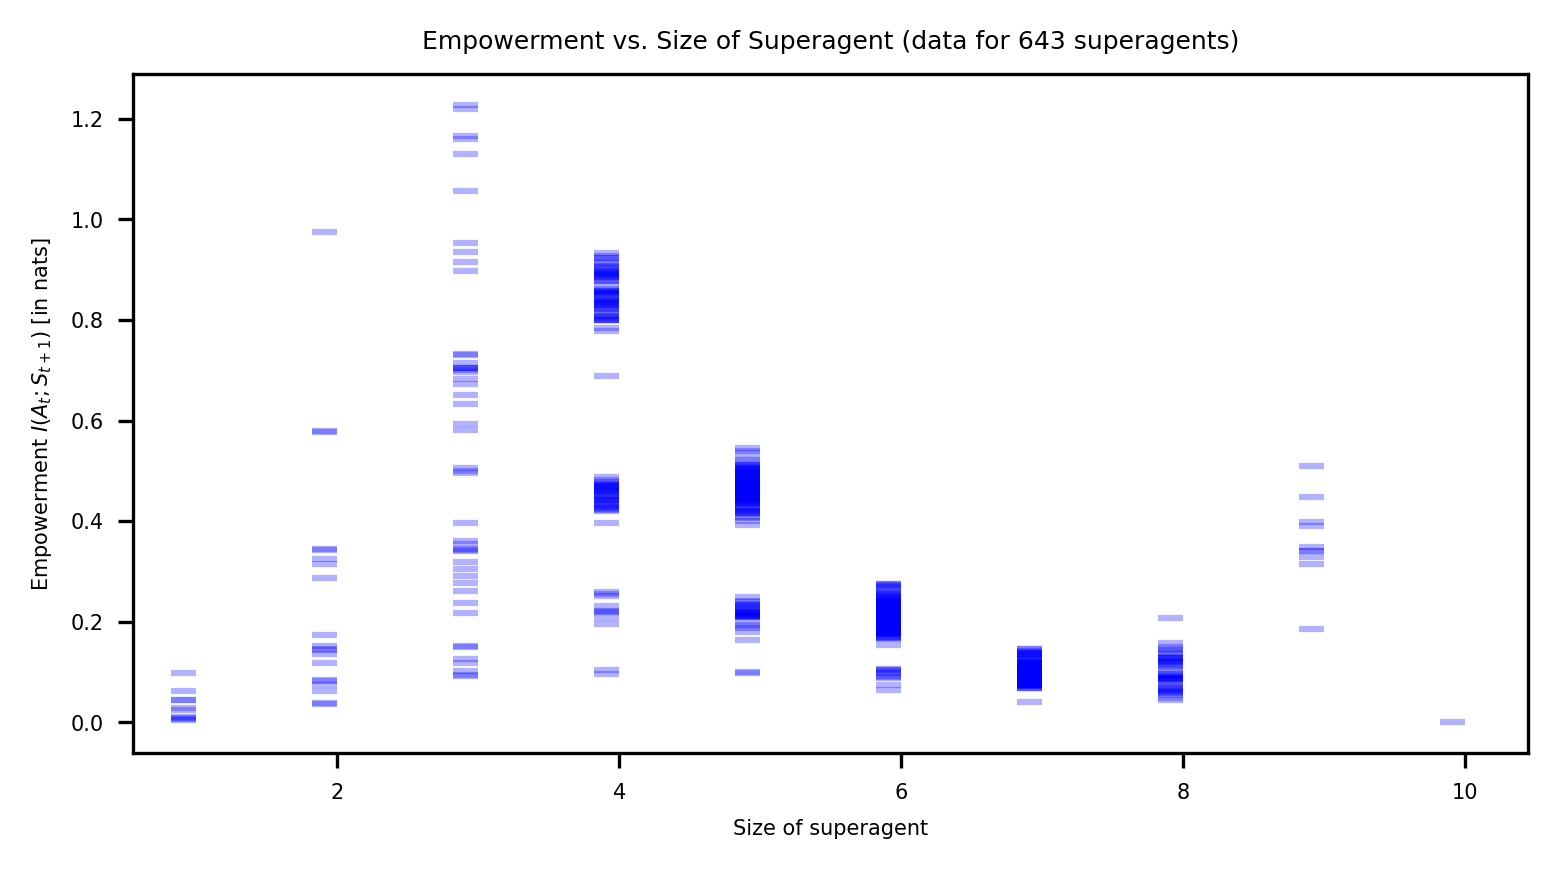

In [61]:
all_empowerments = np.array(all_empowerments)
plt.figure(figsize=(6, 3), dpi=150)
plt.scatter(
    superagent_sizes, 
    all_empowerments, 
    alpha=0.3, 
    c='blue', 
    marker=0,
    label="Empowerment"
)
plt.xlabel('Size of superagent')
plt.ylabel(r'Empowerment $I(A_t; S_{t+1})$ [in nats]')
plt.title(f'Empowerment vs. Size of Superagent (data for {len(all_empowerments)} superagents)')

In [62]:
%store all_empowerments

Stored 'all_empowerments' (ndarray)


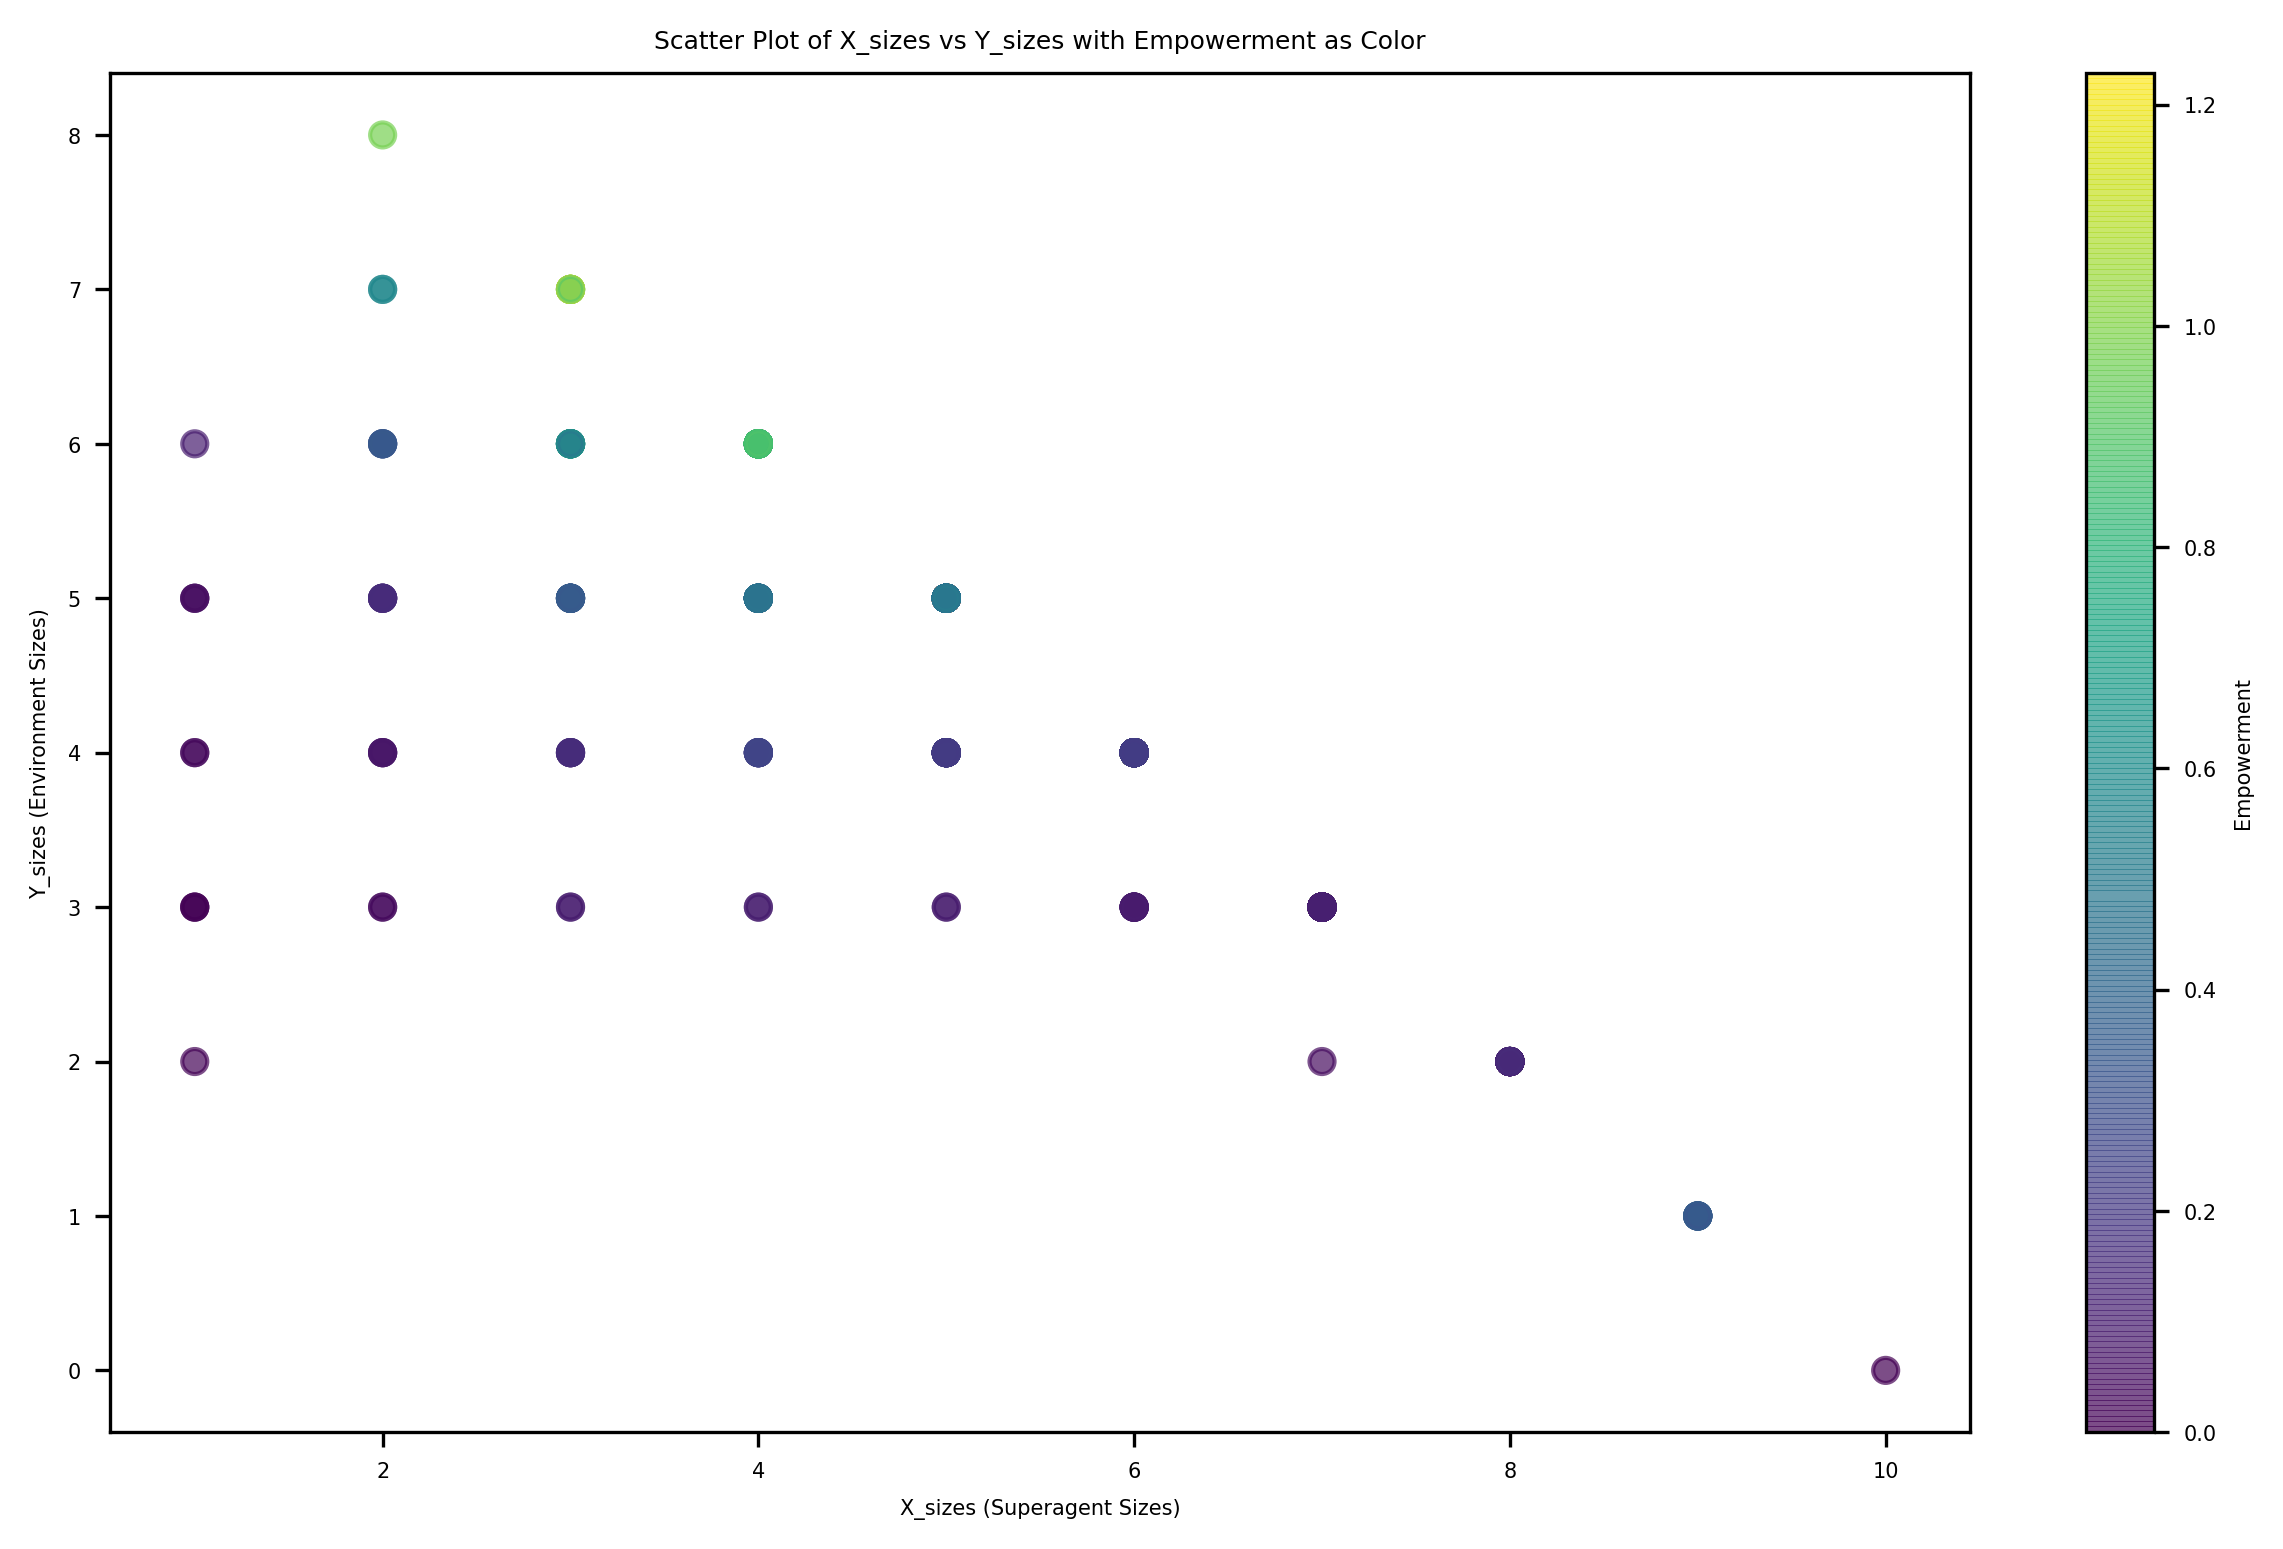

In [63]:
Y_sizes = np.array([p[1].shape[1] for p in all_partition_timeseries])
X_sizes = np.array([p[0].shape[1] for p in all_partition_timeseries])

plt.figure(figsize=(10, 6), dpi=150)
plt.scatter(
    X_sizes, 
    Y_sizes, 
    c=all_empowerments, 
    cmap='viridis', 
    alpha=0.7
)
plt.colorbar(label='Empowerment')
plt.xlabel('X_sizes (Superagent Sizes)')
plt.ylabel('Y_sizes (Environment Sizes)')
plt.title('Scatter Plot of X_sizes vs Y_sizes with Empowerment as Color')
plt.show()

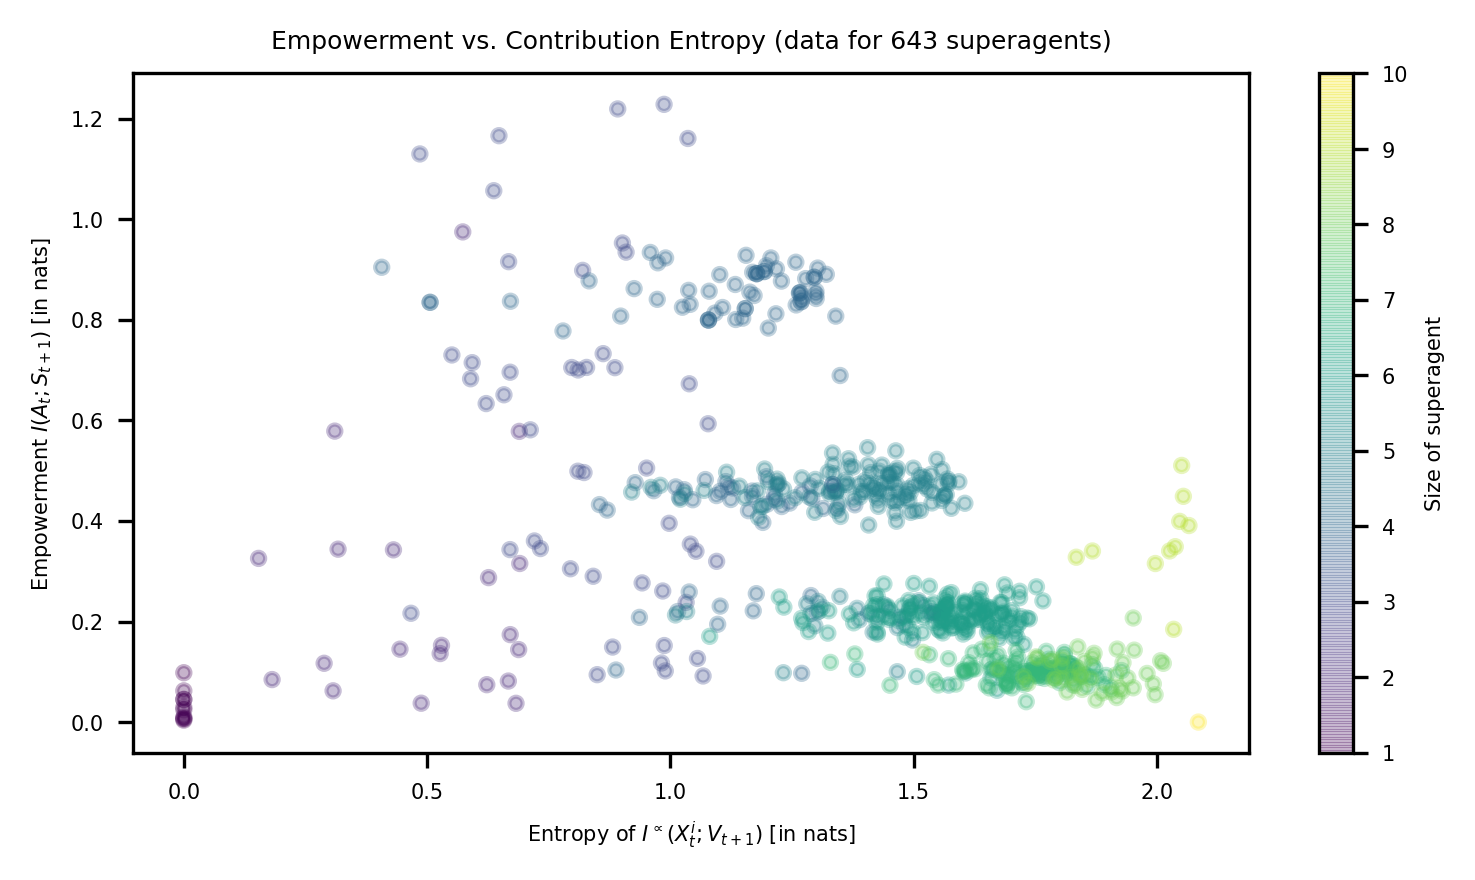

In [64]:
plt.figure(figsize=(6, 3), dpi=150)
plt.scatter(
    superagent_contribution_entropies,#/np.log(superagent_sizes), 
    all_empowerments, 
    alpha=0.3, 
    c=superagent_sizes,
    s=10,
    cmap='viridis', 
    label="Environmental Determined Individuality"
)
plt.xlabel(r'Entropy of $I^{\propto}(X^i_t; V_{t+1})$ [in nats]')
plt.ylabel(r'Empowerment $I(A_t; S_{t+1})$ [in nats]')
plt.title(f'Empowerment vs. Contribution Entropy (data for {len(all_empowerments)} superagents)')
plt.colorbar(label='Size of superagent')
plt.show()

In [57]:
from scipy.optimize import curve_fit


# Define a linear function for fitting
def linear_func(x, a, b):
    return a * x + b

# Prepare to store the fit results
fit_results = {}

# Get unique superagent sizes
unique_sizes = np.unique(superagent_sizes)

# Iterate over each unique superagent size
for size in unique_sizes:
    # Filter data for the current superagent size
    indices = [i for i, s in enumerate(superagent_sizes) if s == size]
    x_data = np.array(superagent_contribution_entropies)[indices]
    y_data = np.array(all_empowerments)[indices]
    
    # Fit a line to the data
    try:
        popt, _ = curve_fit(linear_func, x_data, y_data)
        fit_results[size] = popt  # Store the slope and intercept
    except RuntimeError:
        print(f"Could not fit line for superagent size {size}")

# Display the fit results
for size, (slope, intercept) in fit_results.items():
    print(f"Superagent size {size}: slope = {slope:.4f}, intercept = {intercept:.4f}")

# Plot the data and the fitted lines
plt.figure(figsize=(6, 3), dpi=150)
for size, (slope, intercept) in fit_results.items():
    # Filter data for the current superagent size
    indices = [i for i, s in enumerate(superagent_sizes) if s == size]
    x_data = np.array(superagent_contribution_entropies)[indices]
    y_data = np.array(all_empowerments)[indices]
    
    # Plot the data points
    plt.scatter(x_data, y_data, label=f'Size {size}', alpha=0.5, s=10)
    
    # Generate x values for the fitted line
    x_fit = np.linspace(min(x_data), max(x_data), 100)
    y_fit = linear_func(x_fit, slope, intercept)
    
    # Plot the fitted line
    # plt.plot(x_fit, y_fit, linestyle='--', color='red')
    
    plt.xlabel(r'Entropy of $I^{\propto}(X^i_t; V_{t+1})$ [in nats]')
    plt.ylabel(r'Empowerment $I(A_t; S_{t+1})$ [in nats]')
    plt.title(f'Empowerment vs. Contribution Entropy (data for {len(all_empowerments)} superagents)')
    plt.legend()
plt.show()

/Users/jaime/miniconda3/envs/ma-aif-dit/lib/python3.6/site-packages/scipy/optimize/minpack.py:829: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


TypeError: Improper input: N=2 must not exceed M=1

## Empowerment

$$
\mathfrak{E} \triangleq C(A_t \to S_{t+1}) \equiv \max_{p(a_t)} I(S_{t+1}; A_t)
$$